# Sentiment-Based Product Recommendation System
___

## Introduction

Ebuss is a growing e-commerce company offering products across household essentials, books, personal care, healthcare, cosmetics, electronics, and kitchen categories. As its customer base and product catalogue expand, providing relevant and personalized recommendations has become increasingly important.

The company currently collects customer ratings and written reviews but does not fully utilize this information to understand customer preferences. This can result in less-relevant recommendations and missed sales opportunities.

As a Machine Learning Engineer at Ebuss, the objective of this project is to develop an end-to-end sentiment-based product recommendation system. The solution will analyze historical ratings and review sentiment to generate more meaningful product recommendations, helping improve product discovery, customer satisfaction, engagement, and conversion.

___

## Objectives

Build a model that will improve the recommendations given to the users given their past reviews and ratings

### The primary goals of this project are:
- Analyze product review data to understand user sentiments and preferences.
- Build sentiment classification models using machine learning techniques.
- Develop a product recommendation system using collaborative filtering.
- Integrate sentiment analysis into the recommendation system to fine-tune product suggestions.
- Deploy the system with a user interface for real-time user interaction.

___

## Project Workflow

The project is divided into the following key stages:

### Data Sourcing and Sentiment Analysis
- **Objective:** Preprocess user reviews and train machine learning models to classify sentiment.
- **Dataset:** 30,000 reviews across 200+ products from 20,000+ users.

- **Steps:**
    - Exploratory Data Analysis (EDA)
    - Data Cleaning and Null Handling
    - Text Preprocessing (Tokenization, Stopword Removal, etc.)
    - Feature Extraction using:
        - Bag of Words (BoW)
        - TF-IDF Vectorization
        - Word Embeddings
    - Train and evaluate at least 3 out of 4 models:
        - Logistic Regression
        - Random Forest
        - XGBoost
        - Naive Bayes
    - Handle **class imbalance**, if required.
    - Perform **hyperparameter tuning** and select the **best-performing model**.
___

### Building the Recommendation System
- **Objective:** Recommend relevant products to users based on their past preferences.
- **Approaches to Consider:**
    - User-Based Collaborative Filtering
    - Item-Based Collaborative Filtering

- **Steps:**
    - Analyze both approaches and select the best-fit technique.
    - Build the recommendation system using user-product rating data.
    - For a given user (reviews_username), recommend top 20 products likely to be purchased.
 ___

### Sentiment-Enhanced Recommendations
- **Objective:** Refine recommendations based on user sentiments.

- **Steps:**
    - Use the selected sentiment classification model from Task 1.
    - Analyze sentiment of reviews for the 20 recommended products.
    - Filter and finalize top 5 products with the most positive sentiment scores.
___

### Deployment (Optional)
- **Objective:** Deploy the system in a production environment.
- **Suggestions:**
    - Use Flask or Streamlit for building the UI.
    - Host on Heroku, Render, or AWS EC2 for public access.
    - Allow user input (username or text review) and display personalized recommendations.
___

### Deliverables
- Cleaned dataset and EDA report
- Sentiment classification model with performance metrics
- Collaborative filtering-based recommender system
- Integrated sentiment-aware recommendation pipeline
- (Optional) Web UI for demonstration
- Let’s begin by loading and exploring the dataset!
___

## Deployment & Demo Resources

**Full Project Repository**

You can explore the UI code and follow the deployment procedure to a production region in the official GitHub repo here:

👉 [Sentiment-Based Product Recommendation System (GitHub)](https://github.com/ujwalabhishek/sentiment-based-recommendation-system)

## Live Huggingface Deployment

The project is also deployed on HuggingFace and can be accessed here:
👉 Live App – [Sentiment Based Product Recommendation](https://huggingface.co/spaces/ujwalabhishek/ebuss-sentiment-recommender)



<img src="static/image/deploymane.png">
___

**User Interface (UI)**

The front-end UI provides two major features:

- **Recommendation Engine** – Personalized product recommendations.
- **Sentiment Prediction** – Predicts whether a review is positive or negative.




[**Recommendation Engine UI**](https://huggingface.co/spaces/ujwalabhishek/ebuss-sentiment-recommender)

<img src="static/image/prediction-ui.png">

___

[**Sentiment Predection Engine UI**](https://huggingface.co/spaces/ujwalabhishek/ebuss-sentiment-recommender)

<img src="static/image/sentiment predection.png" />

___

In [1]:
# Optional setup commands. Run these only if the virtual environment or packages are not already installed.
# !python -m venv .venv && source .venv/bin/activate && python -m pip install --upgrade pip && python -m pip install pandas jupyter
# !.venv/bin/python -m pip freeze > requirements.txt && ls -l requirements.txt
# !%pip install jinja2
# !pip install seaborn
# !pip install wordcloud
# !pip install matplotlib
# !pip install nltk
# !pip install spacy
# !python -m spacy download en_core_web
# !pip install scikit-learn
# !pip install imblearn
# !pip install xgboost

## 1. Importing Libraries & Dependencies

In [2]:
import re
import html
import unicodedata
import pickle
import os
import warnings 
warnings.filterwarnings("ignore", category=UserWarning)

# Import core libraries used for EDA and visualization.
import numpy as np
import pandas as pd
import jinja2
from scipy.stats import loguniform
# Setting pandas display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_colwidth', 300)
pd.set_option('display.precision', 2)


# Utilities


# Visualization Tools
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

#nlp
import nltk
nltk.download('stopwords','punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import spacy
nlp = spacy.load("en_core_web_sm")

# Text Feature Extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.model_selection import (
    learning_curve,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.experimental import enable_halving_search_cv  # Needed for HalvingGridSearchCV
from sklearn.model_selection import HalvingGridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics.pairwise import pairwise_distances


[nltk_data] Downloading package stopwords to punkt...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/ujwalabhishek/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
from pathlib import Path
import pickle


def save_model(model,
    model_name,
    directory="models",
    protocol=pickle.HIGHEST_PROTOCOL
):
    """Save a model and record the Pickle protocol used."""

    model_directory = Path(directory)
    model_directory.mkdir(parents=True, exist_ok=True)

    model_path = model_directory / f"{model_name}.pkl"

    payload = {
        "model": model,
        "pickle_protocol": protocol
    }

    with model_path.open("wb") as file:
        pickle.dump(
            payload,
            file,
            protocol=protocol
        )

    print(f"Model saved: {model_path.resolve()}")
    print(f"Pickle protocol: {protocol}")

    return model_path


def load_model(model_name, directory="models"):
    """Load the model and its recorded Pickle protocol."""

    model_path = Path(directory) / f"{model_name}.pkl"

    if not model_path.exists():
        raise FileNotFoundError(
            f"Model file not found: {model_path}"
        )

    with model_path.open("rb") as file:
        payload = pickle.load(file)

    model = payload["model"]
    protocol = payload["pickle_protocol"]

    print(f"Model loaded: {model_path.resolve()}")
    print(f"Pickle protocol: {protocol}")

    return model, protocol

# Usage Example 

# save_model(sentiment_model,"sentiment_model",protocol=pickle.HIGHEST_PROTOCOL)
# sentiment_model, saved_protocol = load_model("sentiment_model")

# Load the sentiment model
# sentiment_model, model_protocol = load_model(
#     "sentiment_model"
# )

# print("Loaded model:", type(sentiment_model))
# print("Pickle protocol:", model_protocol)

# If you saved a vectorizer: print predictions
# tfidf_vectorizer, vectorizer_protocol = load_model(
#     "tfidf_vectorizer"
# )

# sample_reviews = [
#     "This product is excellent and works perfectly.",
#     "The product was damaged and completely useless."
# ]

# sample_features = tfidf_vectorizer.transform(sample_reviews)
# predictions = sentiment_model.predict(sample_features)

# print(predictions)

## 2.Exploratory Data Analysis & Data Preprocessing

### 2.1. Load and Inspect the Dataset

- Read `data/sample30.csv`.
- Display the first few rows.
- Check the dataset shape.
- Inspect column names, data types, and basic dataset information.
- Load `data/Data Attribute Description.csv` and use it as the column reference.

In [4]:
# Load the product reviews dataset.
# latin-1 with replacement keeps the import robust when the CSV contains non-UTF characters.
reviews = pd.read_csv(
    "./data/sample30.csv",
    encoding="latin-1",
    encoding_errors="replace",
    engine="python",
    on_bad_lines="skip",
)

# For EDA Work on a copy so the original loaded dataframe remains available for reference.
reviews_df = reviews.copy()

# Preview the first few rows to understand the raw structure and sample values.
reviews_df.head()

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Movie Bundles & Collections,CDs & Vinyl,Rap & Hip-Hop,Bass,Music on CD or Vinyl,Rap,Hip-Hop,Mainstream Rap,Pop Rap",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,Just Awesome,Los Angeles,NaN,joshua,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part of a promotion.,Good,NaN,NaN,dorothy w,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,Positive
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,"I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation. What we did ...",Disappointed,NaN,NaN,rebecca,Negative
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel caused irritation and it felt like it was burning my skin. I wouldn't recommend this gel.,Irritation,NaN,NaN,walker557,Negative


In [5]:
# Helper function to print sectioned messages consistently during notebook inspection.
def display_info(data, description=None):
    separator = "-" * 50
    print(separator)
    if description:
        print(f"{description}: {data}")
    else:
        print(data)
    print(separator)

# Inspect the number of rows and columns in the reviews dataframe.
display_info(reviews_df.shape, "Shape of reviews dataframe")

# Inspect column names, non-null counts, and inferred data types.
# info() prints directly and returns None, so call it separately from display_info.
display_info("Dataframe structure and data types", "Reviews dataframe info")
reviews_df.info()

--------------------------------------------------
Shape of reviews dataframe: (30000, 15)
--------------------------------------------------
--------------------------------------------------
Reviews dataframe info: Dataframe structure and data types
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    30000 non-null  str   
 1   brand                 30000 non-null  str   
 2   categories            30000 non-null  str   
 3   manufacturer          29859 non-null  str   
 4   name                  30000 non-null  str   
 5   reviews_date          29954 non-null  str   
 6   reviews_didPurchase   15932 non-null  object
 7   reviews_doRecommend   27430 non-null  object
 8   reviews_rating        30000 non-null  int64 
 9   reviews_text          30000 non-null  str   

#### ! Observations & Conclusions:
 - The dataset contains 30,000 rows and 15 columns.
 - Several columns have missing (NULL) values, which will need to be handled during preprocessing
 - Some columns may not be relevant for building Sentiment Analysis or Recommendation models.
 - These irrelevant columns will be identified and removed during further analysis.

### 2.2. Understand Target and Key Columns

- Review the sentiment target column: `user_sentiment`.
- Review the rating column: `reviews_rating`.
- Review the text column: `reviews_text`.
- Review the user identifier: `reviews_username`.
- Review product-related columns such as `name`, `brand`, and `categories`.
- Data Cleaning

In [6]:
# Load the attribute description file to understand the business meaning of each column.
attributes_df = pd.read_csv(
    "./data/Data Attribute Description.csv",
    encoding="latin-1",
    encoding_errors="replace",
    engine="python",
    on_bad_lines="skip",
)

# Display all attribute descriptions without truncating long text.
with pd.option_context("display.max_colwidth", None, "display.max_columns", None, "display.width", None):
    display(attributes_df)

,Attribute,Attribute Description
0,id,Uniques identity number to identify each unique review given by the user to a particular product in the dataset
1,brand,Name of the brand of the product to which user has given review and rating
2,categories,"Category of the product like household essentials, books, personal care products, medicines, cosmetic items, beauty products, electrical appliances, kitchen and dining products, health care products and many more."
3,manufacturer,Name of the manufacturer of the product
4,name,Name of the product to which user has added review or rating
5,reviews_date,Date on which the review has been added by the user
6,reviews_didPurchase,Whether a particular user has purchased the product or not
7,reviews_doRecommend,Whether a particular user has recommended the product or not
8,reviews_rating,Rating given by the user to a particular product
9,reviews_text,Review given by the user to a particular product


In [7]:
# Key columns required for sentiment modeling and recommendation modeling.
# Sentiment: reviews_text and user_sentiment.
# Recommendation: reviews_username, id/name, and reviews_rating.
key_columns = [
    "user_sentiment",
    "reviews_rating",
    "reviews_text",
    "reviews_username",
    "name",
    "brand",
    "categories",
]

# Preview only the columns that matter most for the project objective.
display_info("Data Preview", "Reviews dataframe key columns")
reviews_df[key_columns].head(15)

--------------------------------------------------
Reviews dataframe key columns: Data Preview
--------------------------------------------------


,user_sentiment,reviews_rating,reviews_text,reviews_username,name,brand,categories
0,Positive,5,i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,joshua,Pink Friday: Roman Reloaded Re-Up (w/dvd),Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Movie Bundles & Collections,CDs & Vinyl,Rap & Hip-Hop,Bass,Music on CD or Vinyl,Rap,Hip-Hop,Mainstream Rap,Pop Rap"
1,Positive,5,Good flavor. This review was collected as part of a promotion.,dorothy w,Lundberg Organic Cinnamon Toast Rice Cakes,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes"
2,Positive,5,Good flavor.,dorothy w,Lundberg Organic Cinnamon Toast Rice Cakes,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes"
3,Negative,1,"I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation. What we did ...",rebecca,K-Y Love Sensuality Pleasure Gel,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants"
4,Negative,1,My husband bought this gel for us. The gel caused irritation and it felt like it was burning my skin. I wouldn't recommend this gel.,walker557,K-Y Love Sensuality Pleasure Gel,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants"
5,Negative,1,My boyfriend and I bought this to spice things up in the bedroom and we were both highly disappointed in this product. We bought this one because we absolutely love the ky yours and mine and we thought this would have a similar affect but it did absolutely nothing. Do not buy.,samantha,K-Y Love Sensuality Pleasure Gel,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants"
6,Negative,1,Bought this earlier today and was excited to check it out. Based on the product description I was expecting something but it was just like the regular KY. We are fans of the his and hers so we just expected more and were left a little disappointed.,raeanne,K-Y Love Sensuality Pleasure Gel,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants"
7,Negative,1,I bought this product for my husband and I to try and we were not impressed at all. There was no tingling or warming. It left us both very sticky. I have used KY products in the past (loved KY his and hers) but this one was disappointing.,kimmie,K-Y Love Sensuality Pleasure Gel,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants"
8,Negative,1,My husband and I bought this for some extra fun. We werevboth extremely disappointed. Especially for the price! Do not waste your money on this product. We felt nothing but a sticky mess from it.,cassie,K-Y Love Sensuality Pleasure Gel,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants"
9,Positive,1,Got as a surprise for my husband there is nothing special about it just a lube save the money and get plain KY if you just need a lube wish I could return it for a refund,moore222,K-Y Love Sensuality Pleasure Gel,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants"


#### ! Observations & Conclusions:
 - **Key columns** required for sentiment modeling and recommendation modeling.
    - **Sentiment:** reviews_text and user_sentiment.
    - **Recommendation:** reviews_username, id/name, and reviews_rating.

In [8]:
# Check completeness and data types for the selected key columns.
display_info("Data Types Preview", "Reviews dataframe key columns")
reviews_df[key_columns].info()

--------------------------------------------------
Reviews dataframe key columns: Data Types Preview
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   user_sentiment    29999 non-null  str  
 1   reviews_rating    30000 non-null  int64
 2   reviews_text      30000 non-null  str  
 3   reviews_username  29937 non-null  str  
 4   name              30000 non-null  str  
 5   brand             30000 non-null  str  
 6   categories        30000 non-null  str  
dtypes: int64(1), str(6)
memory usage: 1.6 MB



### 2.3. Missing Value Analysis

- Count missing values for each column.
- Calculate missing value percentages.
- Identify columns with high missingness.
- Decide which columns should be dropped, retained, or cleaned later.

In [9]:
# Generate summary statistics for numeric and categorical columns.
# This gives a quick view of counts, unique values, frequent values, and rating distribution.
display_info("Summary Statistics", "Reviews dataframe")
reviews_df.describe(include="all")

--------------------------------------------------
Reviews dataframe: Summary Statistics
--------------------------------------------------


,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
count,30000,30000,30000,29859,30000,29954,15932,27430,30000.00,30000,29810,1929,170,29937,29999
unique,271,214,270,227,271,6857,2,2,NaN,27282,18535,977,42,24914,2
top,AVpf3VOfilAPnD_xjpun,Clorox,"Household Essentials,Cleaning Supplies,Kitchen Cleaners,Cleaning Wipes,All-Purpose Cleaners,Health & Household,Household Supplies,Household Cleaning,Ways To Shop,Classroom Essentials,Featured Brands,Home And Storage & Org,Clorox,Glass Cleaners,Surface Care & Protection,Business & Industrial,Clea...",Clorox,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,2012-01-26T00:00:00.000Z,False,True,NaN,Good,Great Product,Chicago,CA,mike,Positive
freq,8545,10585,8545,8546,8545,1041,14498,25880,NaN,16,384,34,19,41,26632
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.48,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.99,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
def get_missing_summary(df):
    missing_summary = pd.DataFrame({
        "Missing Count": df.isna().sum(),
        "Missing Percentage": df.isna().mean().mul(100).round(2),
    })

    def missing_level(percentage):
        if percentage == 0:
            return "No"
        elif percentage < 5:
            return "Low"
        elif percentage < 20:
            return "Moderate"
        else:
            return "High"

    missing_summary["Missing Level"] = missing_summary["Missing Percentage"].apply(missing_level)
    return missing_summary.sort_values("Missing Percentage", ascending=False)

missing_summary = get_missing_summary(reviews_df)

display_info("Missing Values Summary", "Reviews dataframe")
display(
    missing_summary.style.format({
        "Missing Percentage": "{:.2f}%"
    })
)

--------------------------------------------------
Reviews dataframe: Missing Values Summary
--------------------------------------------------


,Missing Count,Missing Percentage,Missing Level
reviews_userProvince,29830,99.43%,High
reviews_userCity,28071,93.57%,High
reviews_didPurchase,14068,46.89%,High
reviews_doRecommend,2570,8.57%,Moderate
reviews_title,190,0.63%,Low
manufacturer,141,0.47%,Low
reviews_username,63,0.21%,Low
reviews_date,46,0.15%,Low
id,0,0.00%,No
brand,0,0.00%,No


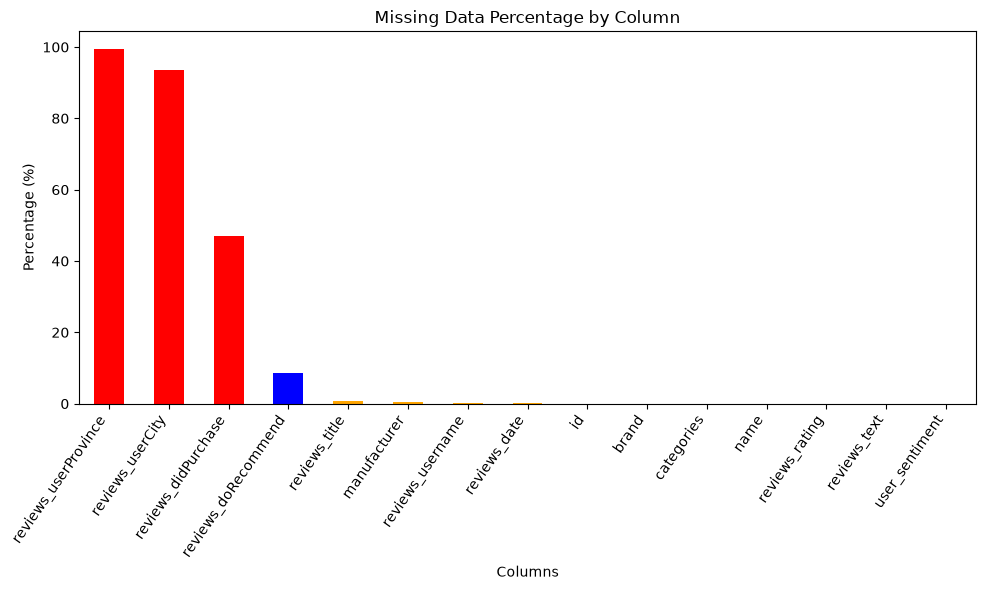

In [11]:
# Visualize missing-value percentages to quickly identify problematic columns.
colors = [
    "skyblue" if level == "No" else
    "orange" if level == "Low" else
    "red" if level == "High" else
    "blue"
    for level in missing_summary["Missing Level"]
]

missing_summary["Missing Percentage"].plot(
    kind="bar",
    figsize=(10, 6),
    color=colors,
)

plt.title("Missing Data Percentage by Column")
plt.ylabel("Percentage (%)")
plt.xlabel("Columns")
plt.xticks(rotation=55, ha="right")
plt.tight_layout()
plt.show()

#### Data Cleaning 

- Remove the columns 'reviews_userProvince', 'reviews_userCity', 'reviews_didPurchase' with high missing counts in the data cleaning stage

In [12]:
# Remove the columns 'reviews_userProvince', 'reviews_userCity', 'reviews_didPurchase'

#For cleaning and preprocessing, work on a separate copy to avoid accidental modifications to the original dataframe.
reviews_df_cleaned = reviews.copy()

reviews_df_cleaned.drop(
    columns=[
        'reviews_userProvince',
        'reviews_userCity',
        'reviews_didPurchase'
    ],
    inplace=True
)

reviews_df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   30000 non-null  str   
 1   brand                30000 non-null  str   
 2   categories           30000 non-null  str   
 3   manufacturer         29859 non-null  str   
 4   name                 30000 non-null  str   
 5   reviews_date         29954 non-null  str   
 6   reviews_doRecommend  27430 non-null  object
 7   reviews_rating       30000 non-null  int64 
 8   reviews_text         30000 non-null  str   
 9   reviews_title        29810 non-null  str   
 10  reviews_username     29937 non-null  str   
 11  user_sentiment       29999 non-null  str   
dtypes: int64(1), object(1), str(10)
memory usage: 2.7+ MB


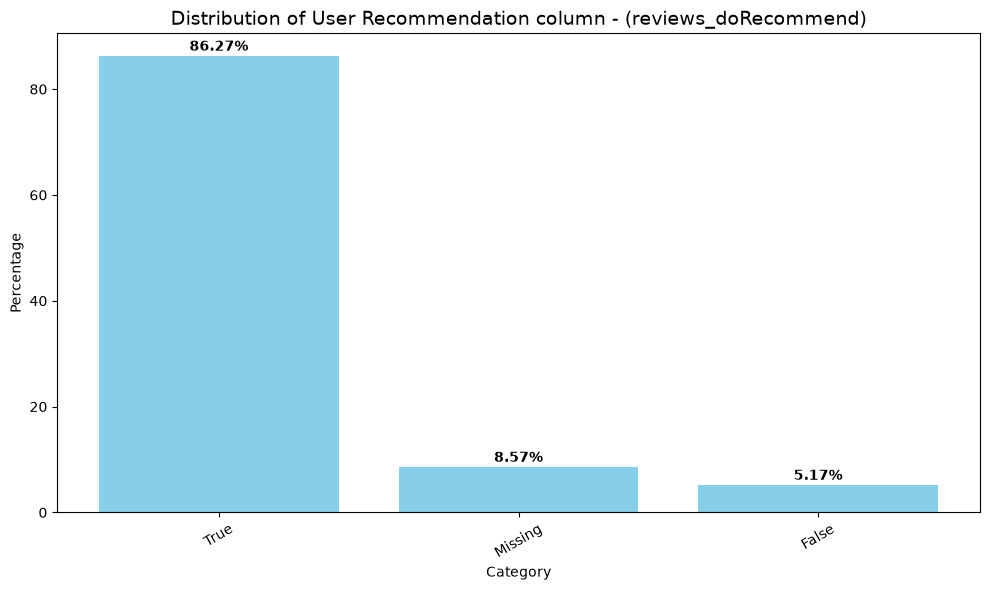

In [13]:
def plot_cat_distribution(df, column, title=None):
    # Create a clean plotting series without modifying the original dataframe
    series = df[column].fillna("Missing").astype(str)

    percentage_data = (
        series
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        percentage_data.index.astype(str),
        percentage_data.values,
        color="skyblue"
    )

    # Annotate percentage on top of each bar
    for bar, val in zip(bars, percentage_data.values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{val:.2f}%",
            ha="center",
            fontweight="bold"
        )

    plt.title(title or f"Distribution of {column}", fontsize=14)
    plt.ylabel("Percentage")
    plt.xlabel("Category")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


plot_cat_distribution(reviews_df, "reviews_doRecommend", "Distribution of User Recommendation column - (reviews_doRecommend)")    

#### Data Cleaning

- Upon examining the distribution of the reviews_doRecommend column, we observe that over 86% of the entries are marked as True and 8% marked as Missing. This indicates a strong imbalance, providing little discriminatory power for the model. Therefore, this column will be dropped from the dataset.

In [14]:
# Remove the columns 'reviews_doRecommend'
reviews_df_cleaned.drop(columns=['reviews_doRecommend'], inplace=True)
reviews_df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                30000 non-null  str  
 1   brand             30000 non-null  str  
 2   categories        30000 non-null  str  
 3   manufacturer      29859 non-null  str  
 4   name              30000 non-null  str  
 5   reviews_date      29954 non-null  str  
 6   reviews_rating    30000 non-null  int64
 7   reviews_text      30000 non-null  str  
 8   reviews_title     29810 non-null  str  
 9   reviews_username  29937 non-null  str  
 10  user_sentiment    29999 non-null  str  
dtypes: int64(1), str(10)
memory usage: 2.5 MB


In [15]:
missing_summary = get_missing_summary(reviews_df_cleaned)

display_info("Missing Values Summary", "Reviews dataframe")
display(missing_summary.style.format({
    "Missing Percentage": "{:.2f}%"
}))

--------------------------------------------------
Reviews dataframe: Missing Values Summary
--------------------------------------------------


,Missing Count,Missing Percentage,Missing Level
reviews_title,190,0.63%,Low
manufacturer,141,0.47%,Low
reviews_username,63,0.21%,Low
reviews_date,46,0.15%,Low
id,0,0.00%,No
brand,0,0.00%,No
categories,0,0.00%,No
name,0,0.00%,No
reviews_rating,0,0.00%,No
reviews_text,0,0.00%,No


 #### Data Cleaning
 - Since the missing values for the columns reviews_title, manufacturer	, reviews_username is less than 1% we will drop the rows with missing values

In [16]:
#drop rows with missing values in reviews_username & user_sentiment columns

columns_to_check = ['reviews_username', 'manufacturer','reviews_title']

def drop_rows_with_missing_values(df, columns):
    """
    Drops rows from the dataframe where any of the specified columns have missing values.

    Returns the count of missing rows per column before dropping, plus the total rows removed.
    """
    missing_counts = df[columns].isna().sum()
    rows_before = len(df)
    df.dropna(subset=columns, inplace=True)
    rows_after = len(df)
    return missing_counts, rows_before - rows_after

missing_counts, total_dropped = drop_rows_with_missing_values(reviews_df_cleaned, columns_to_check)

display_info("Missing values per column before dropping rows")
print(missing_counts)
display_info(total_dropped, "Total rows dropped after dropna")


--------------------------------------------------
Missing values per column before dropping rows
--------------------------------------------------
reviews_username     63
manufacturer        141
reviews_title       190
dtype: int64
--------------------------------------------------
Total rows dropped after dropna: 393
--------------------------------------------------


#### ! Observations & Conclusions:

Columns dropped in data cleaning stage 
 - reviews_userProvince
 - reviews_userCity
 - reviews_didPurchase
 - reviews_doRecommend

Rows Cleaned 
 - reviews_username :   63
 - manufacturer     :   141
 - reviews_title    :   190



Because reviews_username is the user identifier, it should not be imputed. Filling missing values with "Unknown" would incorrectly treat all 63 reviews as belonging to one user and distort collaborative filtering.
The 63 values are NaN and represent only 0.21% of the 30,000 rows.
We  drop those rows. Dropping the 63 rows entirely is also reasonable because the loss is only 0.21%.

Since the missing values for the columns reviews_title, manufacturer, reviews_username is less than 1% we  droped the rows with missing values

### 2.4. Sentiment Distribution

- Count positive and negative sentiment records.
- Plot the sentiment class distribution.
- Check whether the sentiment target is imbalanced.
- Compare sentiment distribution against review ratings.

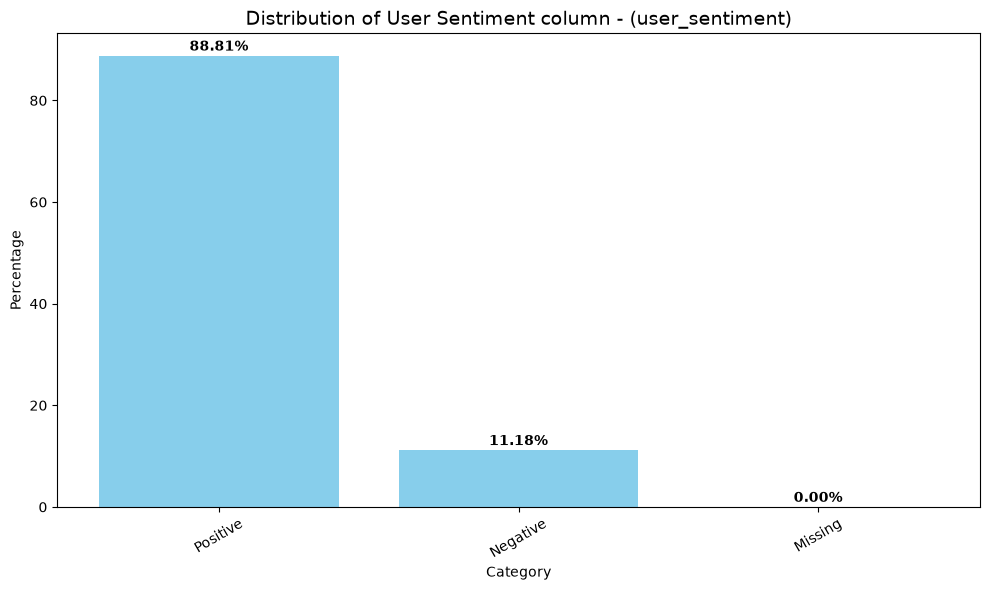

In [17]:
plot_cat_distribution(reviews_df_cleaned, "user_sentiment", "Distribution of User Sentiment column - (user_sentiment)")    

### 2.5. Ratings Analysis

- Analyze the distribution of `reviews_rating`.
- Calculate average, minimum, and maximum ratings.
- Count reviews by each rating value.
- Compare ratings with `user_sentiment`.
- Identify mismatch cases, such as high rating with negative sentiment or low rating with positive sentiment.

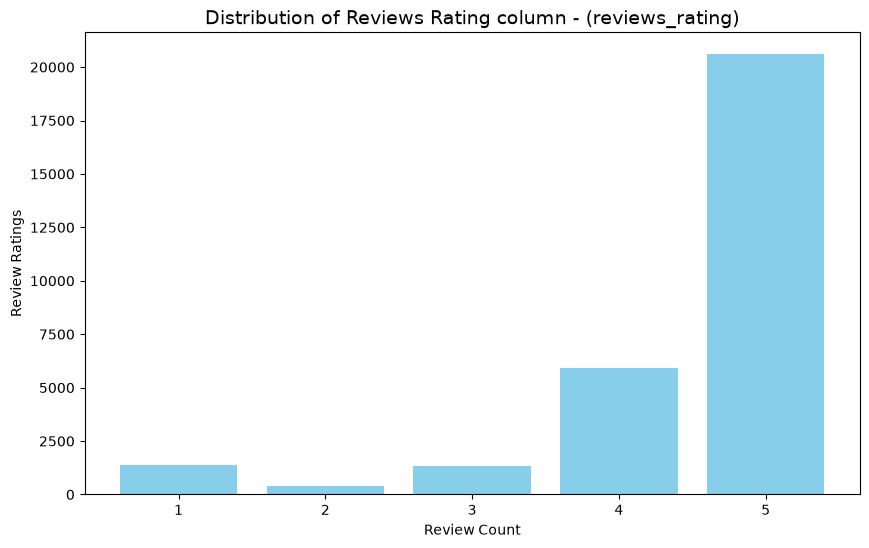

--------------------------------------------------
Average Rating:: 4.485797277670821
--------------------------------------------------
--------------------------------------------------
Minimum Rating:: 1
--------------------------------------------------
--------------------------------------------------
Maximum Rating:: 5
--------------------------------------------------
--------------------------------------------------
Review Counts by Rating Value: 
--------------------------------------------------
Reviews with 1 stars: 1359
Reviews with 2 stars: 407
Reviews with 3 stars: 1315
Reviews with 4 stars: 5937
Reviews with 5 stars: 20589
--------------------------------------------------
Compare ratings with sentiments: 
--------------------------------------------------


user_sentiment,Negative,Positive
reviews_rating,,
1,42.97%,57.03%
2,33.66%,66.34%
3,16.20%,83.80%
4,9.04%,90.96%
5,8.94%,91.06%


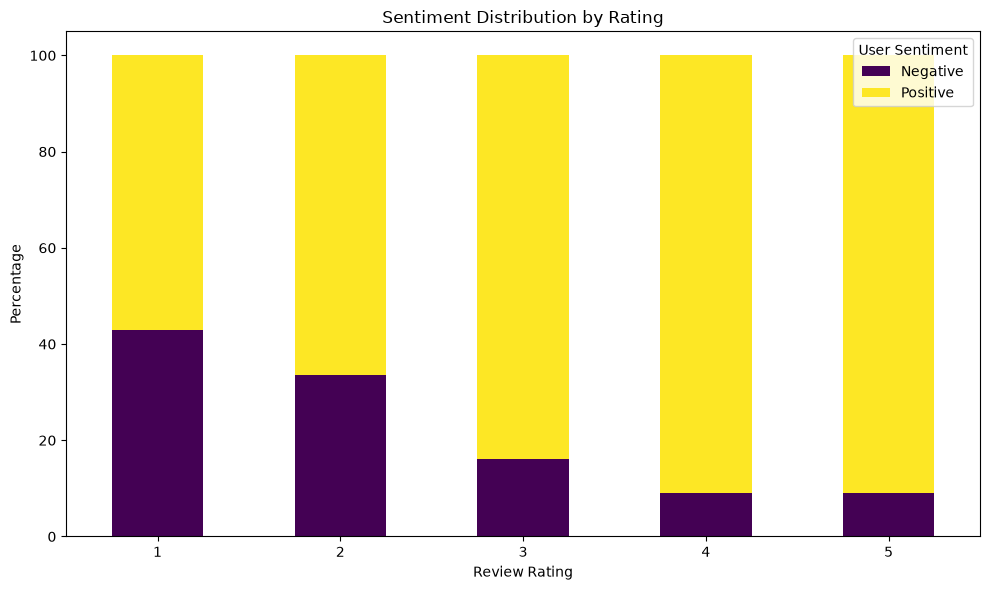

In [18]:
# analyze the distribution of reviews_rating to understand the rating scale and its impact on sentiment and recommendation modeling.

def plot_cat_distribution(df, column, title=None):
    # Create a clean plotting series without modifying the original dataframe
    series = df[column].fillna("Missing").astype(str)
    plt.figure(figsize=(10, 6))     
    plt.bar(series.value_counts().sort_index().index.astype(str), series.value_counts().sort_index().values, color="skyblue")   
    plt.title(title or f"Distribution of {column}", fontsize=14)
    plt.ylabel("Review Ratings")
    plt.xlabel("Review Count")
    plt.show()

plot_cat_distribution(reviews_df_cleaned, "reviews_rating", "Distribution of Reviews Rating column - (reviews_rating)")

# Calculate average, minimum, and maximum ratings
avg_rating = reviews_df_cleaned["reviews_rating"].mean()
min_rating = reviews_df_cleaned["reviews_rating"].min()
max_rating = reviews_df_cleaned["reviews_rating"].max()

display_info(avg_rating, "Average Rating:")
display_info(min_rating, "Minimum Rating:")
display_info(max_rating, "Maximum Rating:")

#Count reviews by each rating value.
rating_counts = reviews_df_cleaned["reviews_rating"].value_counts().sort_index()
display_info("", "Review Counts by Rating Value")
for rating, count in rating_counts.items():
    print(f"Reviews with {rating} stars: {count}")


#Compare ratings with sentiments 
display_info("", "Compare ratings with sentiments")

rating_sentiment_counts = pd.crosstab(
    reviews_df_cleaned["reviews_rating"],
    reviews_df_cleaned["user_sentiment"],
    margins=True
)
rating_sentiment_counts

#Compare ratings with sentiments (percentage)
rating_sentiment_counts_per = pd.crosstab(
    reviews_df_cleaned["reviews_rating"],
    reviews_df_cleaned["user_sentiment"],
    normalize="index",
).mul(100).round(2)

# Show formatted percentages without requiring jinja2
display(rating_sentiment_counts_per.style.format("{:.2f}%"))

# plot the distribution of user sentiment across different review ratings to visualize how sentiment varies with rating values.

rating_sentiment_counts_per.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="viridis"
)

plt.title("Sentiment Distribution by Rating")
plt.xlabel("Review Rating")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="User Sentiment")
plt.tight_layout()
plt.show()

In [19]:
# Identify mismatch cases, such as high rating with negative sentiment or low rating with positive sentiment.
high_rating_negative = reviews_df_cleaned[
    (reviews_df_cleaned["reviews_rating"] >= 4) &
    (reviews_df_cleaned["user_sentiment"] == "Negative")
]

low_rating_positive = reviews_df_cleaned[
    (reviews_df_cleaned["reviews_rating"] <= 2) &
    (reviews_df_cleaned["user_sentiment"] == "Positive")
]
#display_info("","Identify mismatch cases, such as high rating with negative sentiment or low rating with positive sentiment.")
display_info(high_rating_negative.shape[0], "High rating but negative sentiment:")
display(high_rating_negative.groupby(["reviews_rating"]).count().user_sentiment)

display_info(low_rating_positive.shape[0], "Low rating but positive sentiment:")
display(low_rating_positive.groupby(["reviews_rating"]).count().user_sentiment)


--------------------------------------------------
High rating but negative sentiment:: 2377
--------------------------------------------------


reviews_rating
4     537
5    1840
Name: user_sentiment, dtype: int64

--------------------------------------------------
Low rating but positive sentiment:: 1045
--------------------------------------------------


reviews_rating
1    775
2    270
Name: user_sentiment, dtype: int64

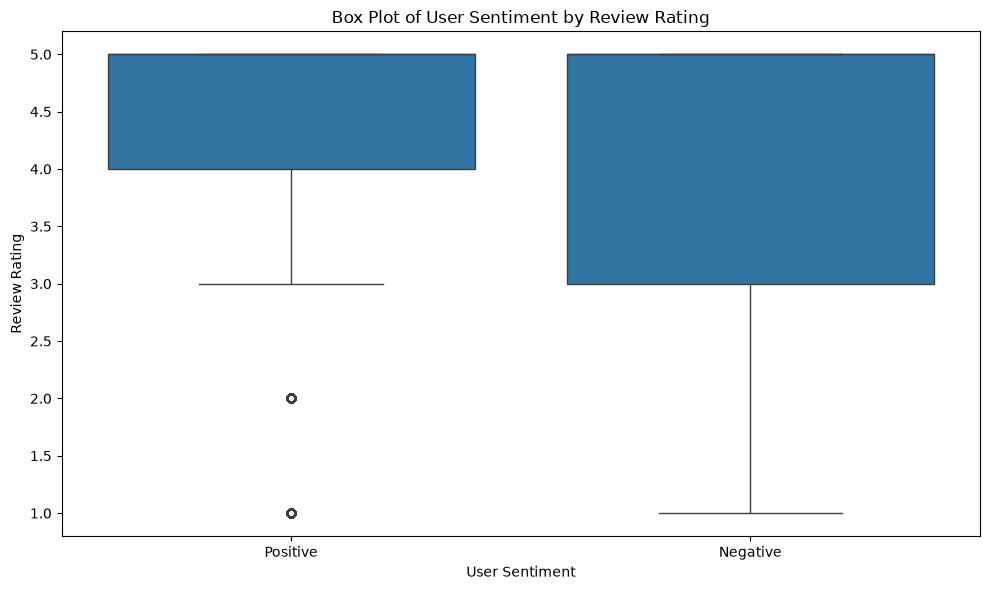

In [20]:
def box_plot_sentiment_by_rating(df):
    plt.figure(figsize=(10, 6))
    sns.boxplot( x="user_sentiment",y="reviews_rating", data=df)
    plt.title("Box Plot of User Sentiment by Review Rating")
    plt.ylabel("Review Rating")
    plt.xlabel("User Sentiment")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

box_plot_sentiment_by_rating(reviews_df_cleaned)    

#### Data Cleaning
 - Fix  High rating classified as negative sentiment and Low rating classified as positive sentiment

In [21]:
# Fix  High rating classified as negative sentiment
# Change the  sentiment of reviews with high ratings (4 or 5) but negative sentiment to positive sentiment.
reviews_df_cleaned.loc[high_rating_negative.index, "user_sentiment"] = "Positive"

# Fix  Low rating classified as positive sentiment
# Change the  sentiment of reviews with low ratings (1 or 2) but positive sentiment to negative sentiment.
reviews_df_cleaned.loc[low_rating_positive.index, "user_sentiment"] = "Negative"

In [22]:
# Identify mismatch cases, such as high rating with negative sentiment or low rating with positive sentiment.
high_rating_negative = reviews_df_cleaned[
    (reviews_df_cleaned["reviews_rating"] >= 4) &
    (reviews_df_cleaned["user_sentiment"] == "Negative")
]

low_rating_positive = reviews_df_cleaned[
    (reviews_df_cleaned["reviews_rating"] <= 2) &
    (reviews_df_cleaned["user_sentiment"] == "Positive")
]
#display_info("","Identify mismatch cases, such as high rating with negative sentiment or low rating with positive sentiment.")
display_info(high_rating_negative.shape[0], "High rating but negative sentiment:")
display(high_rating_negative.groupby(["reviews_rating"]).count().user_sentiment)

display_info(low_rating_positive.shape[0], "Low rating but positive sentiment:")
display(low_rating_positive.groupby(["reviews_rating"]).count().user_sentiment)

--------------------------------------------------
High rating but negative sentiment:: 0
--------------------------------------------------


Series([], Name: user_sentiment, dtype: int64)

--------------------------------------------------
Low rating but positive sentiment:: 0
--------------------------------------------------


Series([], Name: user_sentiment, dtype: int64)

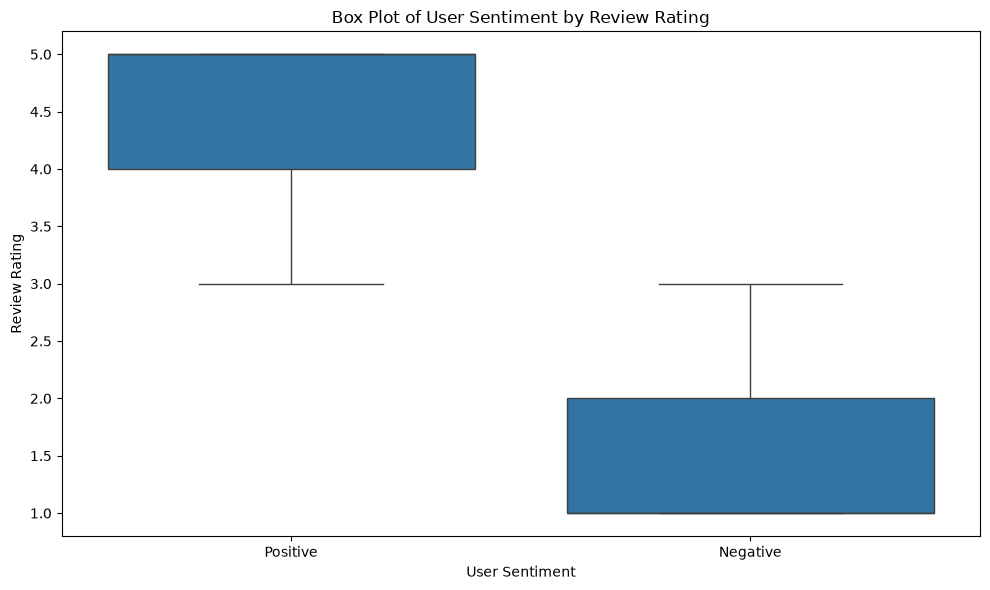

In [23]:
box_plot_sentiment_by_rating(reviews_df_cleaned)

#### ! Observations & Conclusions:

 - There were inconsistencies where low ratings were marked positive and high ratings were marked negative. Therefore, ratings if used for as an input feature for sentiment classification would lead to target leakage, so this misclassification has been handled.

 - The ratings are highly skewed toward positive reviews, with '5' ratings being the most common. The average rating is 4.48, indicating that most users rated products favorably. Sentiment generally follows the rating pattern, as '4' and '5' reviews are mostly positive. 
 
 - This indicates a potential class imbalance, which could affect model performance especially since user_sentiment is expected to align closely with these ratings. We will need to handle this class imbalance. 

### 2.6. Duplicate Analysis

- Check for fully duplicate rows.
- Check repeated user-product-review combinations.

In [24]:
# Count rows that are completely identical across all columns.
# These can usually be removed because they add no new information.
full_duplicate_count = reviews.duplicated().sum()

print("Fully duplicated rows:", full_duplicate_count)

Fully duplicated rows: 0


In [25]:
# Inspect full duplicates before dropping them to confirm they are truly repeated records.
full_duplicates = reviews[
    reviews.duplicated(keep=False)
].sort_values("id")

full_duplicates.head(10)

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment


In [26]:
# Check unique product ID coverage.
# In this dataset, id behaves as a product identifier, so repeated IDs are expected.
print("Total rows:", len(reviews))
print("Unique Product IDs:", reviews["id"].nunique())
print("Missing Product IDs:", reviews["id"].isna().sum())
print("Duplicated Product IDs:", reviews["id"].duplicated().sum())

Total rows: 30000
Unique Product IDs: 271
Missing Product IDs: 0
Duplicated Product IDs: 29729


In [27]:
# Validate whether each product ID maps consistently to a single product name.
# A non-zero result may indicate product naming inconsistencies that need cleanup.
product_names_per_id = reviews.groupby("id")["name"].nunique()

print(
    "Product IDs mapped to multiple product names:",
    (product_names_per_id > 1).sum()
)

Product IDs mapped to multiple product names: 0


In [28]:
# Check whether the same user reviewed the same product multiple times.
# These records should be inspected and later aggregated for collaborative filtering.
user_product_duplicates = reviews.duplicated(
    subset=["reviews_username", "id"],
    keep=False,
)

print(
    "Rows with repeated user-product combinations:",
    user_product_duplicates.sum()
)

Rows with repeated user-product combinations: 4569


In [29]:
# Review repeated user-product records to decide whether they are true duplicates
# or multiple valid reviews/ratings for the same product by the same user.
repeated_user_products = reviews[
    user_product_duplicates
].sort_values(["reviews_username", "id", "reviews_date"])

repeated_user_products[
    [
        "reviews_username",
        "id",
        "name",
        "reviews_date",
        "reviews_rating",
        "reviews_text",
        "user_sentiment",
    ]
].head(100)

,reviews_username,id,name,reviews_date,reviews_rating,reviews_text,user_sentiment
14290,1234567,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,2014-12-06T00:00:00.000Z,5,"This is a good product to use if you're in a hurry. No rinsing, just wipe and go, This review was collected as part of a promotion.",Positive
9170,1234567,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,2014-12-06T18:01:21.000Z,5,"This is a good product to use if you're in a hurry. No rinsing, just wipe and go, This review was collected as part of a promotion.",Positive
28843,1234asdf,AVpfW8y_LJeJML437ySW,L'or233al Paris Elvive Extraordinary Clay Rebalancing Conditioner - 12.6 Fl Oz,2017-01-11T00:00:00.000Z,2,I got this product free and was very excited to try it. I've used it a couple of times now and my hair the day that I wash it is amazing but the next morning is very greasy. I don't like to wash my hair every day. This product boasts that it will prevent oily roots up to 48 hours. This review wa...,Positive
28866,1234asdf,AVpfW8y_LJeJML437ySW,L'or233al Paris Elvive Extraordinary Clay Rebalancing Conditioner - 12.6 Fl Oz,2017-01-11T14:00:32.000Z,2,I got this product free and was very excited to try it. I've used it a couple of times now and my hair the day that I wash it is amazing but the next morning is very greasy. I don't like to wash my hair every day. This product boasts that it will prevent oily roots up to 48 hours. This review wa...,Positive
5852,143st,AVpf2tw1ilAPnD_xjflC,Red (special Edition) (dvdvideo),2013-09-07T00:00:00.000Z,5,I orderd on line and picked it up at the CS Desk at BB great system. they were friendly at the Morrow Ga BB store,Positive
...,...,...,...,...,...,...,...
6585,akesler19,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,2015-02-11T14:56:50.000Z,4,We use Clorox wipes at my work every day when people are sick. It always keeps things disinfected and keeps everyone else from getting sick too! This review was collected as part of a promotion.,Negative
4669,akhan,AVpf0eb2LJeJML43EVSt,The Resident Evil Collection 5 Discs (blu-Ray),2017-02-12T00:00:00.000Z,4,A great purchase. All the movies in one bundle. Not the greatest of the movies but still a good set for my collection.,Positive
5309,akhan,AVpf0eb2LJeJML43EVSt,The Resident Evil Collection 5 Discs (blu-Ray),2017-05-28T00:00:00.000Z,5,A great bundle with all the movies. This was a decent movie definitely worth checking out.,Positive
20455,akporter84,AVpfJP1C1cnluZ0-e3Xy,Clorox Disinfecting Bathroom Cleaner,2012-01-26T00:00:00.000Z,5,I like the smell of the product after I clean. It cleans good too,Positive


In [30]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# pd.set_option('display.max_colwidth', None)
# display(repeated_user_products[[
#         "reviews_username",
#         "id",
#         "name",
#         "reviews_date",
#         "reviews_rating",
#         "reviews_text",
#         "user_sentiment",
#     ]])

In [31]:
# Check exact review-level repetitions using the fields that define a repeated review event.
review_key = [
    "reviews_username",
    "id",
    "reviews_rating",
    "reviews_text",
]

exact_review_duplicates = reviews.duplicated(
    subset=review_key,
    keep=False,
)

print(
    "Repeated user-product-rating-text rows:",
    exact_review_duplicates.sum()
)

Repeated user-product-rating-text rows: 3584


### 2.7. Product-Level Analysis

- Count unique products.
- Identify the most reviewed products.
- Calculate average rating by product.
- Check sentiment distribution by product.
- Identify products with high review volume and low average rating.
- Identify products with many negative reviews.

In [32]:
#count unique products

# count unique products
unique_products = reviews_df_cleaned["name"].nunique()
display_info(unique_products, "Unique products:")

# Optionally show review counts per product
product_counts = reviews_df_cleaned["name"].value_counts()
display(product_counts)

--------------------------------------------------
Unique products:: 251
--------------------------------------------------


name
Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total                         8524
Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd                   3324
Clorox Disinfecting Bathroom Cleaner                                              2039
L'or233al Paris Elvive Extraordinary Clay Rebalancing Conditioner - 12.6 Fl Oz    1186
Planes: Fire Rescue (2 Discs) (includes Digital Copy) (blu-Ray/dvd)               1140
                                                                                  ... 
5302050 15/16 FCT/HOSE ADAPTOR                                                       1
High-Dome Floor Door Stop                                                            1
Tostitos Original Restaurant Style Tortilla Chips                                    1
Walkers Stem Ginger Shortbread                                                       1
Bodycology Nourishing Body Cream, Pretty In Paris                                    1
Name: count, Length: 251, dtype: int64

--------------------------------------------------
Top 30 Reviewed Products:: 
--------------------------------------------------


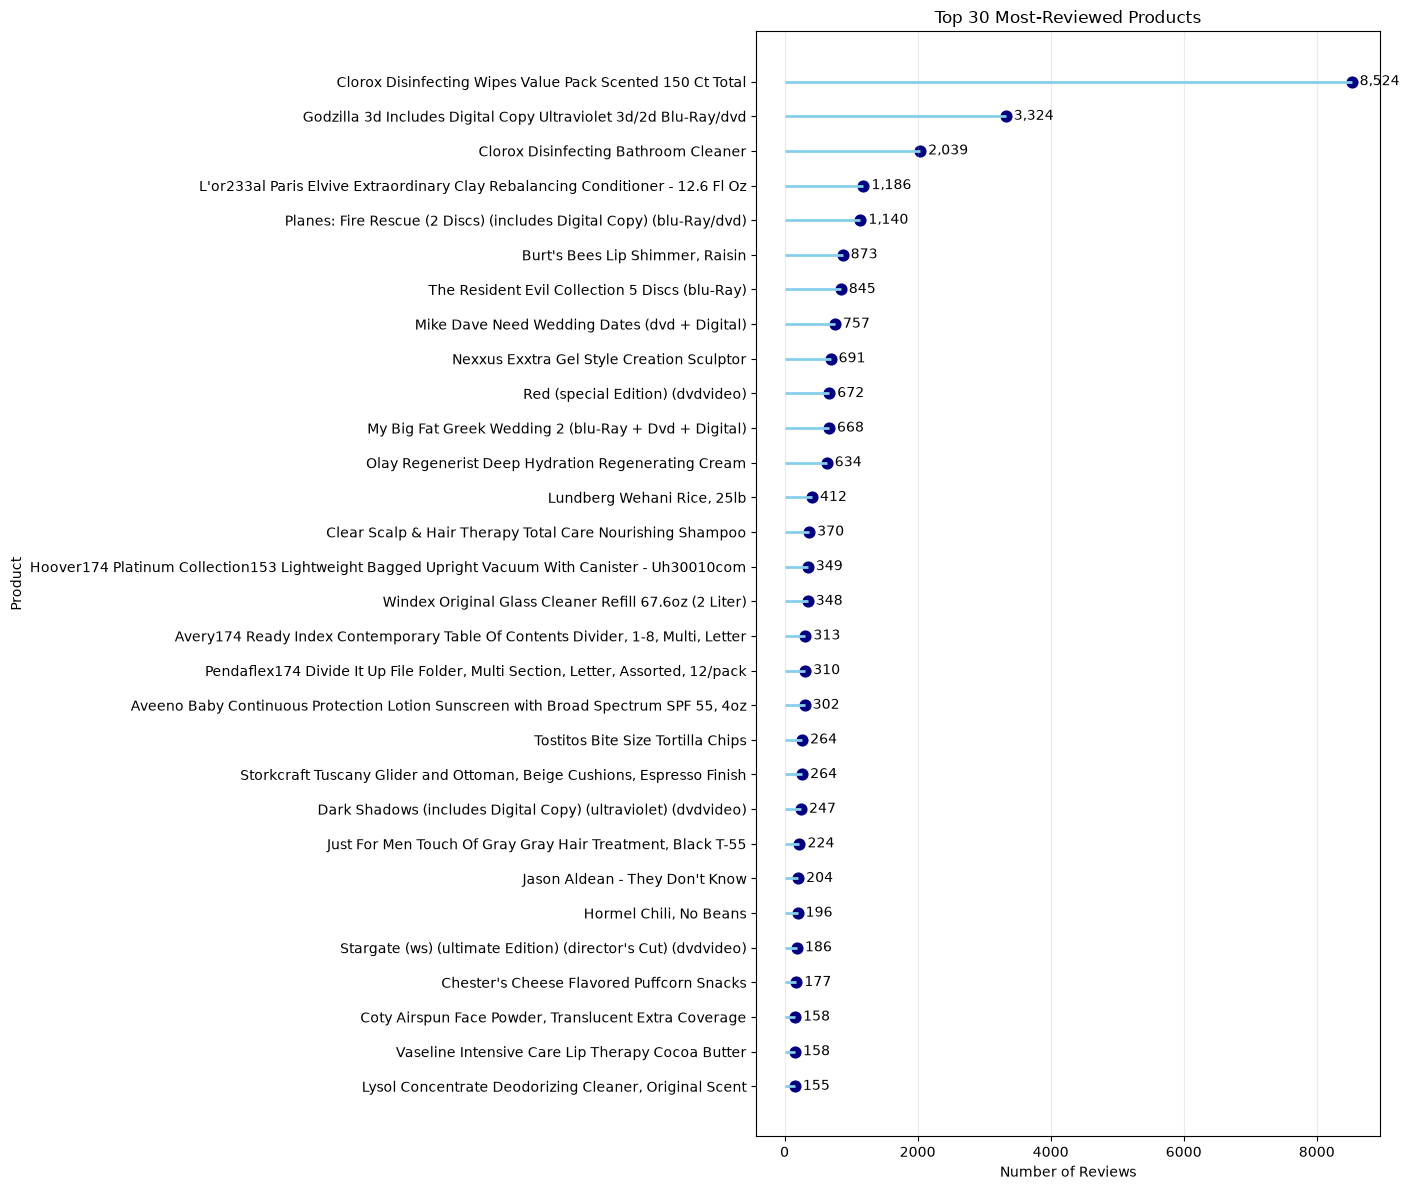

In [33]:
# top reviewed products
top_n = 30
top_reviewed_products = (
    reviews_df_cleaned
    .groupby(["id","name"], as_index=False)
    .agg(reviews_count=("reviews_text", "count"))
    .sort_values(by="reviews_count", ascending=False)
)
display_info("", f"Top {top_n} Reviewed Products:")
#display(top_reviewed_products.head(top_n))


plot_data = (
    top_reviewed_products
    .head(top_n)
    .sort_values("reviews_count")
)

plt.figure(figsize=(14, 12))

plt.hlines(
    y=plot_data["name"],
    xmin=0,
    xmax=plot_data["reviews_count"],
    color="skyblue",
    linewidth=2
)

plt.scatter(
    plot_data["reviews_count"],
    plot_data["name"],
    color="navy",
    s=60
)

for _, row in plot_data.iterrows():
    plt.text(
        row["reviews_count"],
        row["name"],
        f"  {row['reviews_count']:,}",
        va="center"
    )

plt.title(f"Top {top_n} Most-Reviewed Products")
plt.xlabel("Number of Reviews")
plt.ylabel("Product")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

--------------------------------------------------
Average Rating by Product: 
--------------------------------------------------


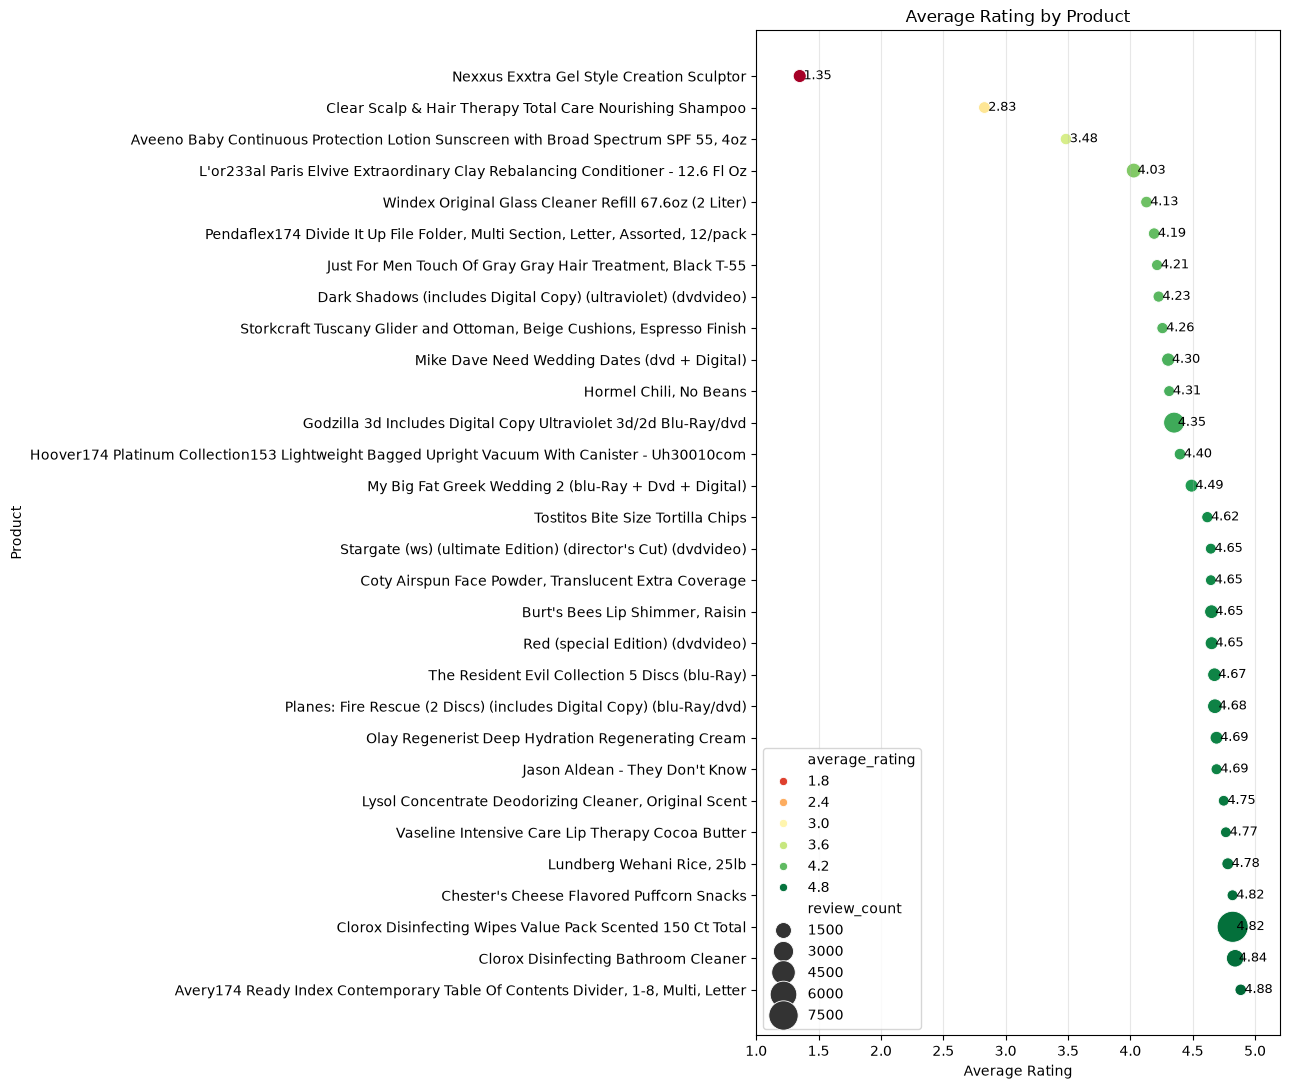

In [34]:
display_info("","Average Rating by Product")

product_rating_summary = (
    reviews_df_cleaned
    .groupby(["id", "name"], as_index=False)
    .agg(
        average_rating=("reviews_rating", "mean"),
        review_count=("reviews_rating", "count")
    )
)

# Keep products with enough reviews for a reliable average
plot_data = (
    product_rating_summary
    .query("review_count >= 20")
    .nlargest(30, "review_count")
    .sort_values("average_rating")
)

plt.figure(figsize=(13, 11))

ax = sns.scatterplot(
    data=plot_data,
    x="average_rating",
    y="name",
    size="review_count",
    hue="average_rating",
    palette="RdYlGn",
    sizes=(60, 500),
    legend="brief"
)

for _, row in plot_data.iterrows():
    ax.text(
        row["average_rating"] + 0.03,
        row["name"],
        f'{row["average_rating"]:.2f}',
        va="center",
        fontsize=9
    )

plt.xlim(1, 5.2)
plt.title("Average Rating by Product")
plt.xlabel("Average Rating")
plt.ylabel("Product")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

--------------------------------------------------
Sentiment Distribution of Top 30 Most-Reviewed Products: 
--------------------------------------------------


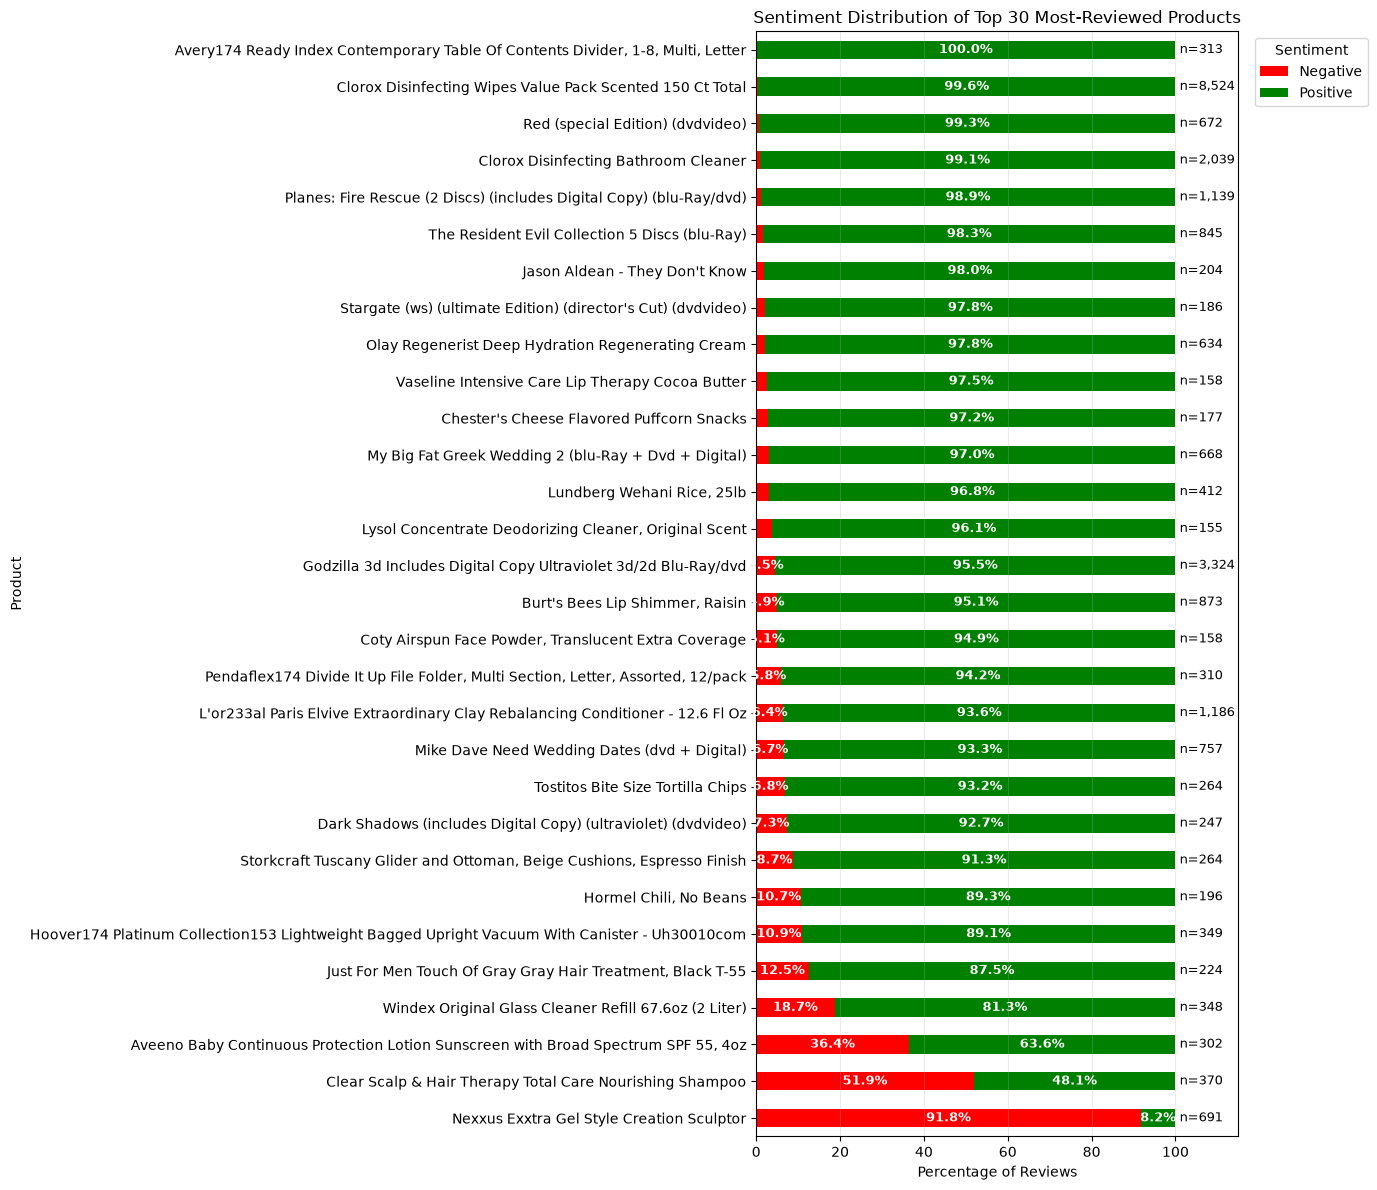

In [35]:
top_n = 30
display_info("",f"Sentiment Distribution of Top {top_n} Most-Reviewed Products")
# Count sentiments for each product
product_sentiment = (
    reviews_df_cleaned
    .groupby(["id", "name", "user_sentiment"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Ensure both sentiment columns exist
for sentiment in ["Positive", "Negative"]:
    if sentiment not in product_sentiment.columns:
        product_sentiment[sentiment] = 0

product_sentiment["reviews_count"] = (
    product_sentiment["Positive"]
    + product_sentiment["Negative"]
)

# Select the top-reviewed products
plot_data = (
    product_sentiment
    .nlargest(top_n, "reviews_count")
    .copy()
)

# Convert sentiment counts into percentages
sentiment_percentage = (
    plot_data
    .set_index("name")[["Negative", "Positive"]]
)

sentiment_percentage = sentiment_percentage.div(
    sentiment_percentage.sum(axis=1),
    axis=0
).mul(100)

# Sort by positive sentiment percentage
sentiment_percentage = sentiment_percentage.sort_values("Positive")

review_counts = (
    plot_data
    .set_index("name")["reviews_count"]
    .reindex(sentiment_percentage.index)
)

ax = sentiment_percentage.plot(
    kind="barh",
    stacked=True,
    figsize=(14, 12),
    color={
        "Negative": "Red",
        "Positive": "Green"
    }
)

# Display percentages inside the bars
for container in ax.containers:
    labels = [
        f"{value:.1f}%" if value >= 4 else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontsize=9,
        fontweight="bold"
    )

# Display total review count after each bar
for position, count in enumerate(review_counts):
    ax.text(
        101,
        position,
        f"n={count:,}",
        va="center",
        fontsize=9
    )

plt.title(f"Sentiment Distribution of Top {top_n} Most-Reviewed Products")
plt.xlabel("Percentage of Reviews")
plt.ylabel("Product")
plt.xlim(0, 115)
plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1))
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

--------------------------------------------------
Products with ≥20 Reviews and Lowest Average Rating: 
--------------------------------------------------


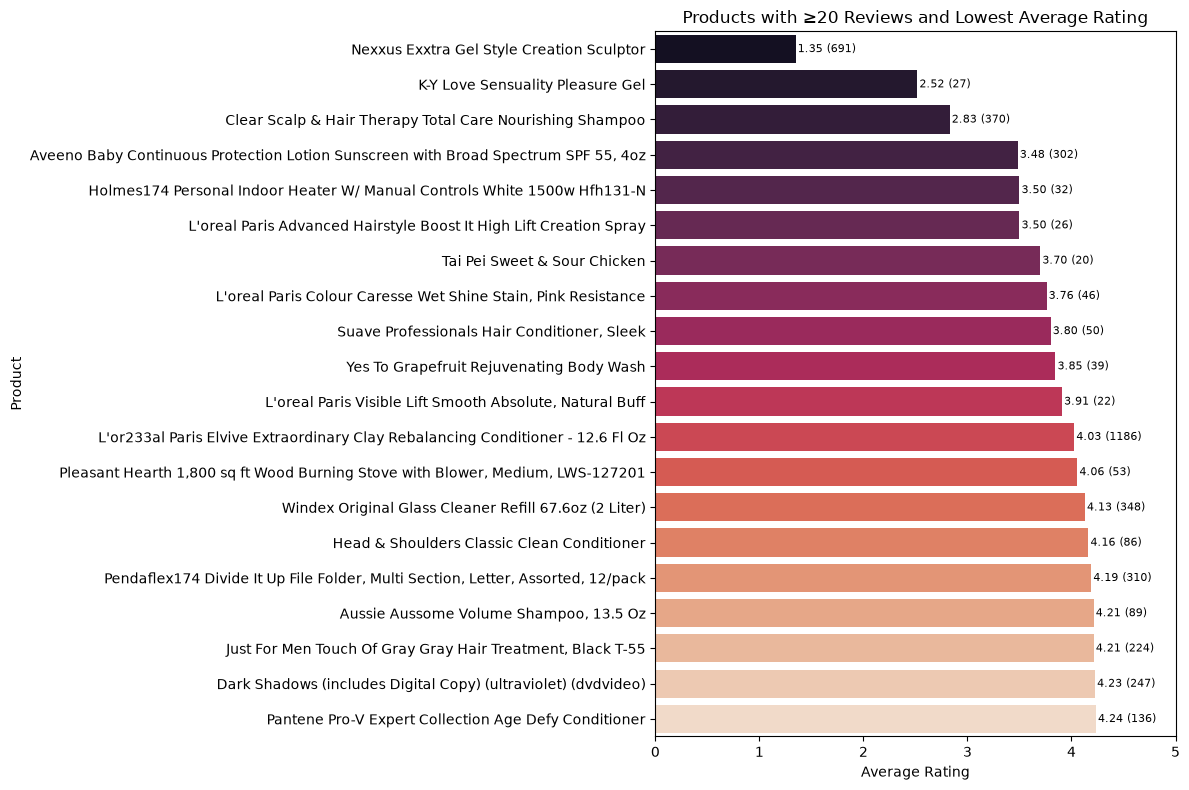

In [36]:
# Identify products with relatively high review volume and low average rating.

review_count_threshold = 20
display_info("",f"Products with ≥{review_count_threshold} Reviews and Lowest Average Rating")

low_rating_high_volume = (
    product_rating_summary
    .query("review_count >= @review_count_threshold")
    .sort_values(["average_rating", "review_count"], ascending=[True, False])
    .head(20)
)

#display(low_rating_high_volume)

plt.figure(figsize=(12, 8))
plot_data = low_rating_high_volume.sort_values("average_rating", ascending=True)

sns.barplot(
    data=plot_data,
    x="average_rating",
    y="name",
    hue="name",
    palette="rocket",
    legend = False
)

for idx, (rating, count) in enumerate(zip(plot_data["average_rating"], plot_data["review_count"])):
    plt.text(rating + 0.02, idx, f"{rating:.2f} ({count})", va="center", fontsize=8)

plt.title(f"Products with ≥{review_count_threshold} Reviews and Lowest Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Product")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

#plot the graph 



--------------------------------------------------
Top 20 Products by Negative Review Count: 
--------------------------------------------------


,id,name,negative_reviews,total_reviews,negative_pct
226,AVpfm8yiLJeJML43AYyu,Nexxus Exxtra Gel Style Creation Sculptor,634,691,91.75
168,AVpfOmKwLJeJML435GM7,Clear Scalp & Hair Therapy Total Care Nourishing Shampoo,192,370,51.89
173,AVpfPaoqLJeJML435Xk9,Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,150,3324,4.51
172,AVpfPPkEilAPnD_xX3cP,"Aveeno Baby Continuous Protection Lotion Sunscreen with Broad Spectrum SPF 55, 4oz",110,302,36.42
196,AVpfW8y_LJeJML437ySW,L'or233al Paris Elvive Extraordinary Clay Rebalancing Conditioner - 12.6 Fl Oz,76,1186,6.41
3,AV1YGDqsGV-KLJ3adc-O,Windex Original Glass Cleaner Refill 67.6oz (2 Liter),65,348,18.68
37,AVpe41TqilAPnD_xQH3d,Mike Dave Need Wedding Dates (dvd + Digital),51,757,6.74
95,AVpf63aJLJeJML43F__Q,"Burt's Bees Lip Shimmer, Raisin",43,873,4.93
68,AVpe9W4D1cnluZ0-avf0,Hoover174 Platinum Collection153 Lightweight Bagged Upright Vacuum With Canister - Uh30010com,38,349,10.89
86,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,38,8524,0.45


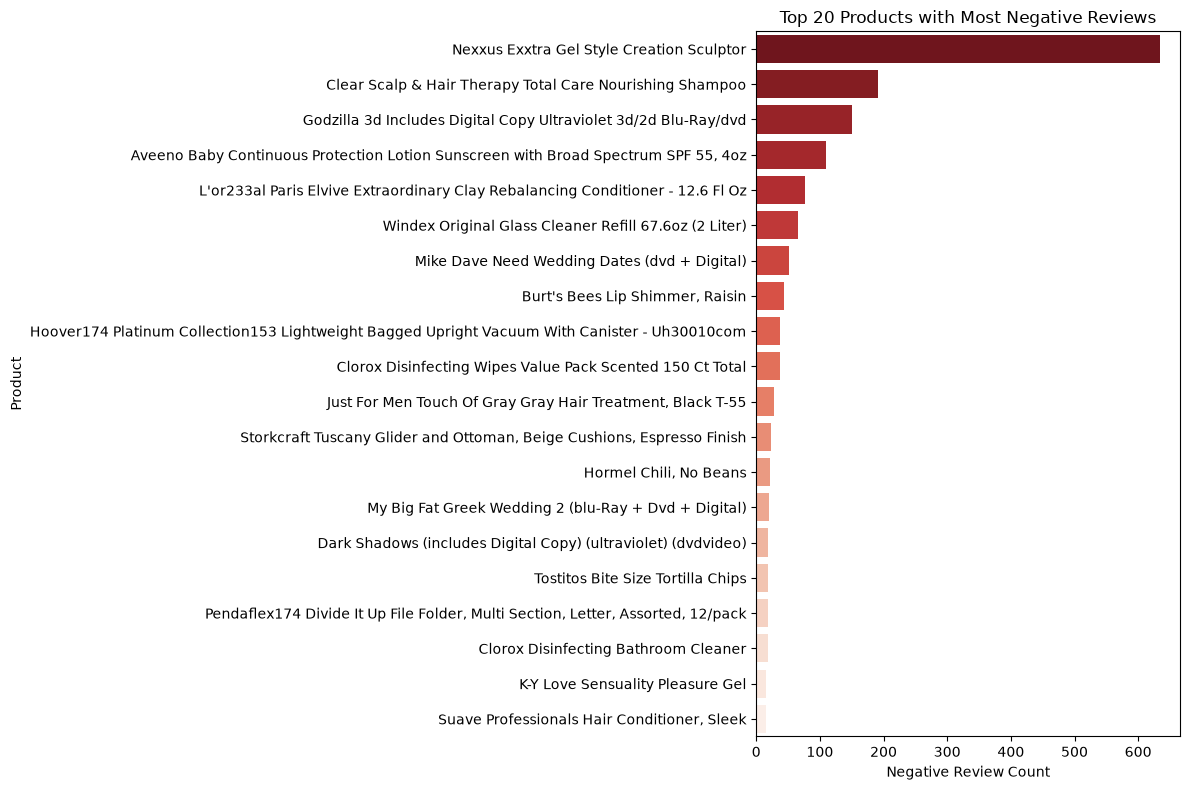

In [37]:
top_n = 20

product_negative_summary = (
    reviews_df_cleaned.assign(is_negative=lambda df: df["user_sentiment"] == "Negative")
    .groupby(["id", "name"], as_index=False)
    .agg(
        negative_reviews=("is_negative", "sum"),
        total_reviews=("user_sentiment", "count"),
    )
)

product_negative_summary["negative_pct"] = (
    product_negative_summary["negative_reviews"]
    / product_negative_summary["total_reviews"]
    * 100
)

top_negative_products = product_negative_summary.sort_values(
    by=["negative_reviews", "negative_pct"],
    ascending=[False, False],
).head(top_n)

display_info("", f"Top {top_n} Products by Negative Review Count")
display(top_negative_products)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_negative_products,
    x="negative_reviews",
    y="name",
    hue="name",
    palette="Reds_r",
    legend=False
)
plt.title(f"Top {top_n} Products with Most Negative Reviews")
plt.xlabel("Negative Review Count")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

 #### Observation

- *Avery174 Ready Index Contemporary Table Of Contents Divider, 1-8, Multi, Letter* - is the product with highest Average ratings 
- *Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total* is the product with most no of reviews
- *Nexxus Exxtra Gel Style Creation Sculptor* - Is the product with most -ve reviews, is also product with high review volume and low average rating.





### 2.8. Brand and Category Analysis

- Identify top brands by review count.
- Calculate average rating by brand.
- Check sentiment distribution by brand.
- Identify common product categories.
- Compare category-level sentiment and rating patterns.

--------------------------------------------------
Top 20 Brands by Review Count: 
--------------------------------------------------


,brand,count,percent
0,Clorox,10564,35.68
1,Warner Home Video,3324,11.23
2,Disney,1197,4.04
3,L'oreal Paris,1186,4.01
4,FOX,887,3.00
5,Burt's Bees,881,2.98
6,Sony Pictures,845,2.85
7,Nexxus,691,2.33
8,Summit Entertainment,672,2.27
9,Universal Home Video,668,2.26


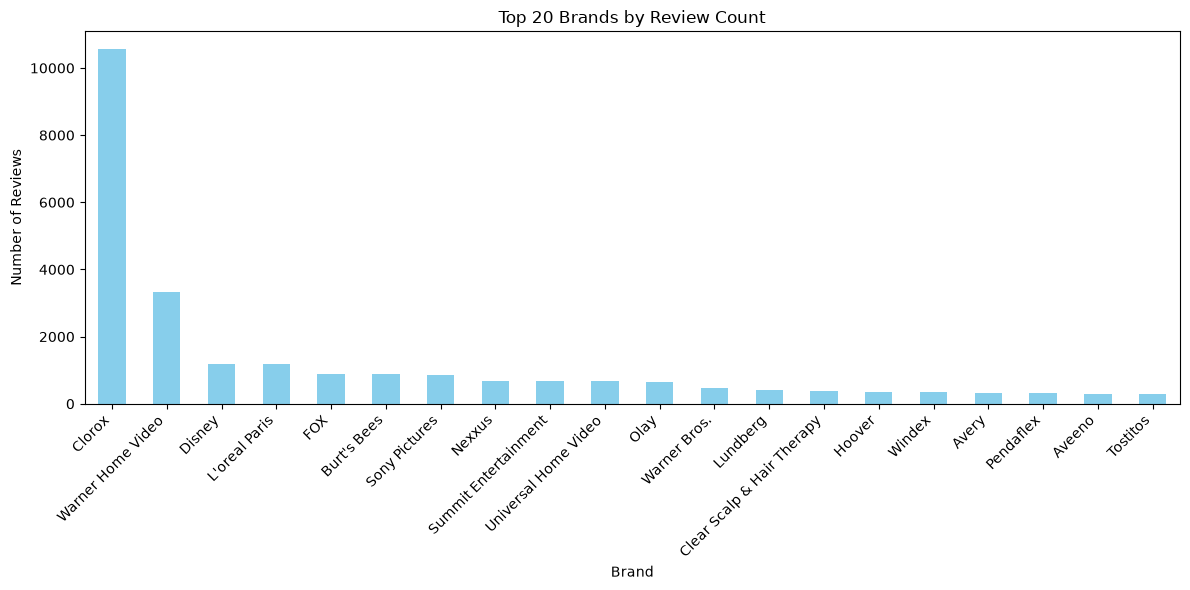

In [38]:
top_brands = (
    reviews_df_cleaned["brand"]
    .fillna("Unknown")
    .value_counts()
    .head(20)
    .rename_axis("brand")
    .reset_index(name="count")
)
total_brand_reviews = reviews_df_cleaned["brand"].fillna("Unknown").shape[0]
top_brands["percent"] = (top_brands["count"] / total_brand_reviews * 100).round(2)

display_info("", "Top 20 Brands by Review Count")
display(top_brands)

plt.figure(figsize=(12, 6))
top_brands.set_index("brand")["count"].plot(kind="bar", color="skyblue")
plt.title("Top 20 Brands by Review Count")
plt.ylabel("Number of Reviews")
plt.xlabel("Brand")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


--------------------------------------------------
Sentiment Percentage for Top 20 Brands
--------------------------------------------------


user_sentiment,Negative,Positive
brand,,
Clorox,0.53%,99.47%
Warner Home Video,4.51%,95.49%
Disney,1.00%,99.00%
L'oreal Paris,6.41%,93.59%
FOX,5.98%,94.02%
Burt's Bees,4.88%,95.12%
Sony Pictures,1.66%,98.34%
Nexxus,91.75%,8.25%
Summit Entertainment,0.74%,99.26%


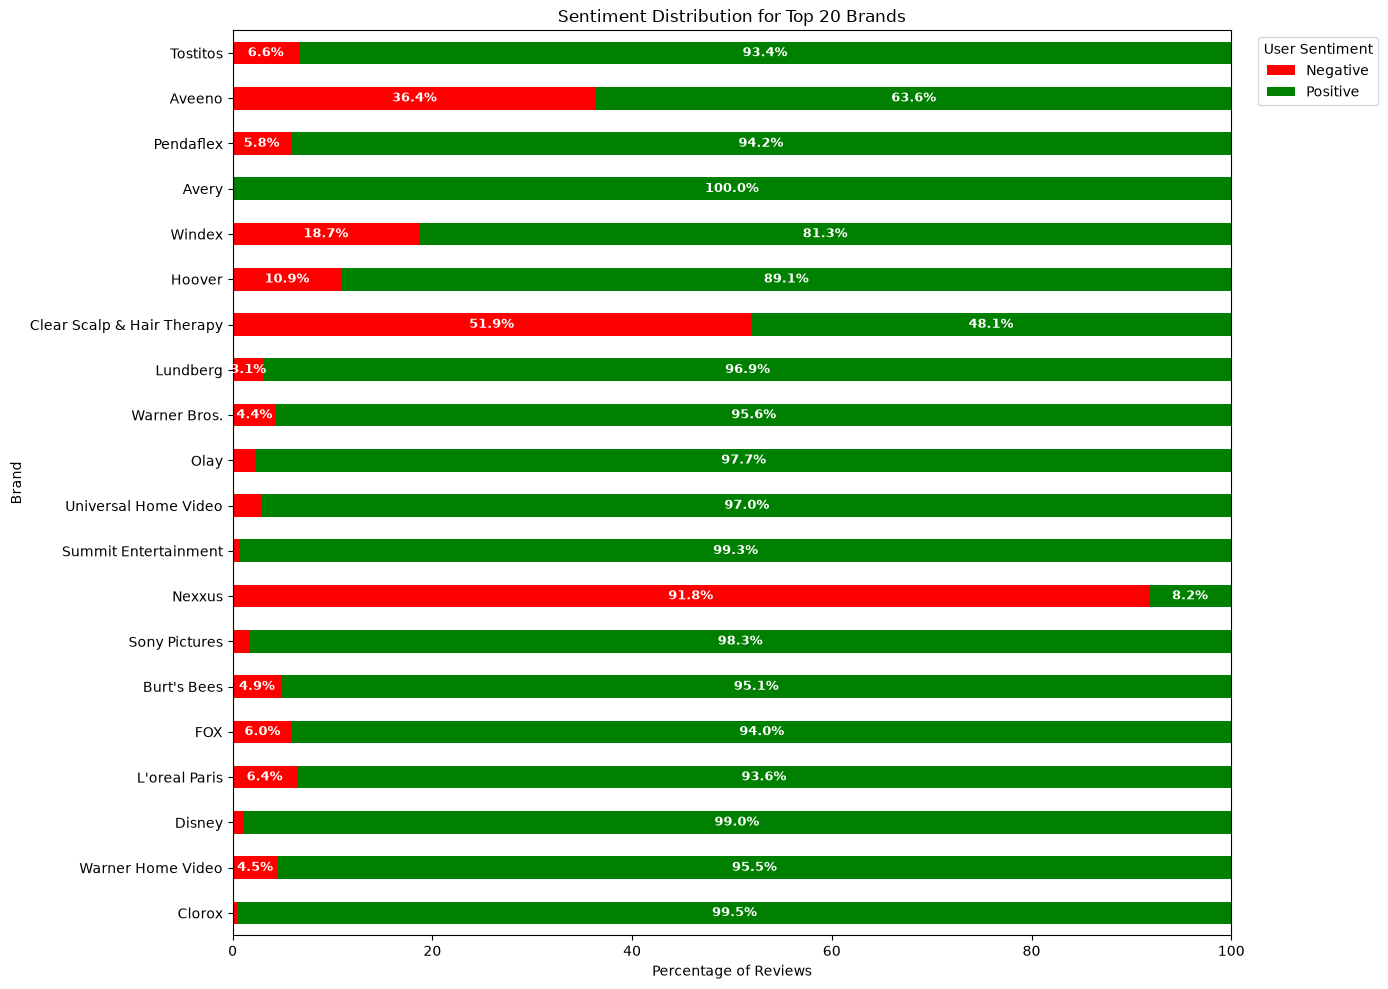

In [39]:
brand_sentiment = (
    reviews_df_cleaned
    .assign(brand=reviews_df_cleaned["brand"].fillna("Unknown"))
    .groupby(["brand", "user_sentiment"])
    .size()
    .unstack(fill_value=0)
)

brand_sentiment["total_reviews"] = brand_sentiment.sum(axis=1)
brand_sentiment = brand_sentiment.sort_values("total_reviews", ascending=False)

top_brand_sentiment = brand_sentiment.head(20)

brand_sentiment_pct = (
    top_brand_sentiment
    .drop(columns="total_reviews")
    .div(top_brand_sentiment["total_reviews"], axis=0)
    .mul(100)
    .round(2)
)

display_info("Sentiment Percentage for Top 20 Brands")
display(brand_sentiment_pct.style.format("{:.2f}%"))

ax = brand_sentiment_pct.plot(
    kind="barh",
    stacked=True,
    figsize=(14, 10),
    color={"Negative": "Red", "Positive": "Green"},
)

for container in ax.containers:
    for bar in container:
        width = bar.get_width()
        if width > 3:
            ax.text(
                bar.get_x() + width / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{width:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=9,
                fontweight="bold",
            )

plt.title("Sentiment Distribution for Top 20 Brands")
plt.xlabel("Percentage of Reviews")
plt.ylabel("Brand")
plt.xlim(0, 100)
plt.legend(title="User Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

--------------------------------------------------
Unique product categories: 1281
--------------------------------------------------
--------------------------------------------------
Top 20 common product categories: categories
Movies                       18303
Featured Brands              14653
Health & Household           11287
Household Supplies           11211
Household Essentials         11128
Household Cleaning           11080
Food & Grocery               11079
Home And Storage & Org       11044
Cleaning Supplies            11019
Target Restock               10934
Clorox                       10564
Ways To Shop                  9868
Glass Cleaners                8906
All-Purpose Cleaners          8700
Music & Books                 8575
Surface Care & Protection     8539
Business & Industrial         8538
All Purpose Cleaners          8528
Classroom Essentials          8526
Kitchen Cleaners              8524
Name: count, dtype: int64
--------------------------------------------

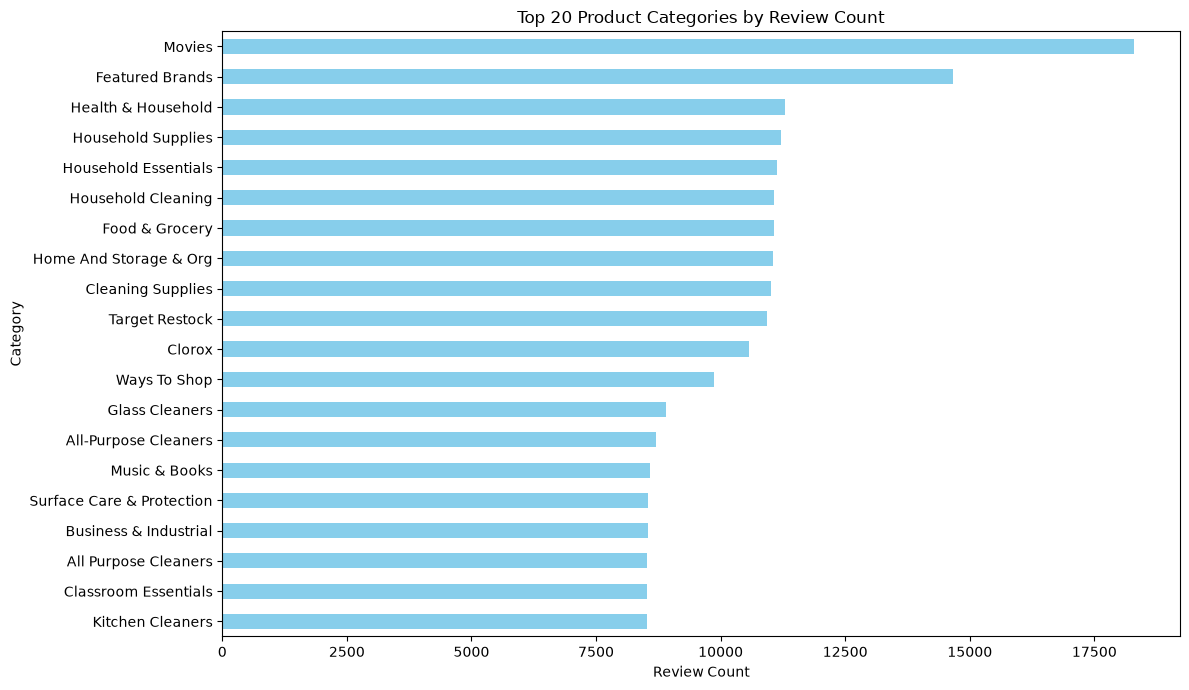

In [40]:
# Identify common product categories by splitting the comma-separated category strings
category_counts = (
    reviews_df_cleaned["categories"]
    .fillna("Missing")
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
    .replace("", "Missing")
    .value_counts()
)

display_info(category_counts.shape[0], "Unique product categories")
display_info(category_counts.head(20), "Top 20 common product categories")

plt.figure(figsize=(12, 7))
category_counts.head(20).sort_values(ascending=True).plot(
    kind="barh",
    color="skyblue"
)
plt.title("Top 20 Product Categories by Review Count")
plt.xlabel("Review Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

,Negative,Positive,total_reviews,positive_pct,negative_pct,avg_rating,review_count
category,,,,,,,
Movies,610,17690,18300,96.67%,3.33%,4.49,18303
Featured Brands,1214,13439,14653,91.72%,8.28%,4.48,14653
Health & Household,142,11145,11287,98.74%,1.26%,4.80,11287
Household Supplies,130,11081,11211,98.84%,1.16%,4.80,11211
Household Essentials,133,10995,11128,98.80%,1.20%,4.80,11128
Household Cleaning,127,10953,11080,98.85%,1.15%,4.80,11080
Food & Grocery,126,10953,11079,98.86%,1.14%,4.80,11079
Home And Storage & Org,127,10917,11044,98.85%,1.15%,4.80,11044
Cleaning Supplies,128,10891,11019,98.84%,1.16%,4.80,11019


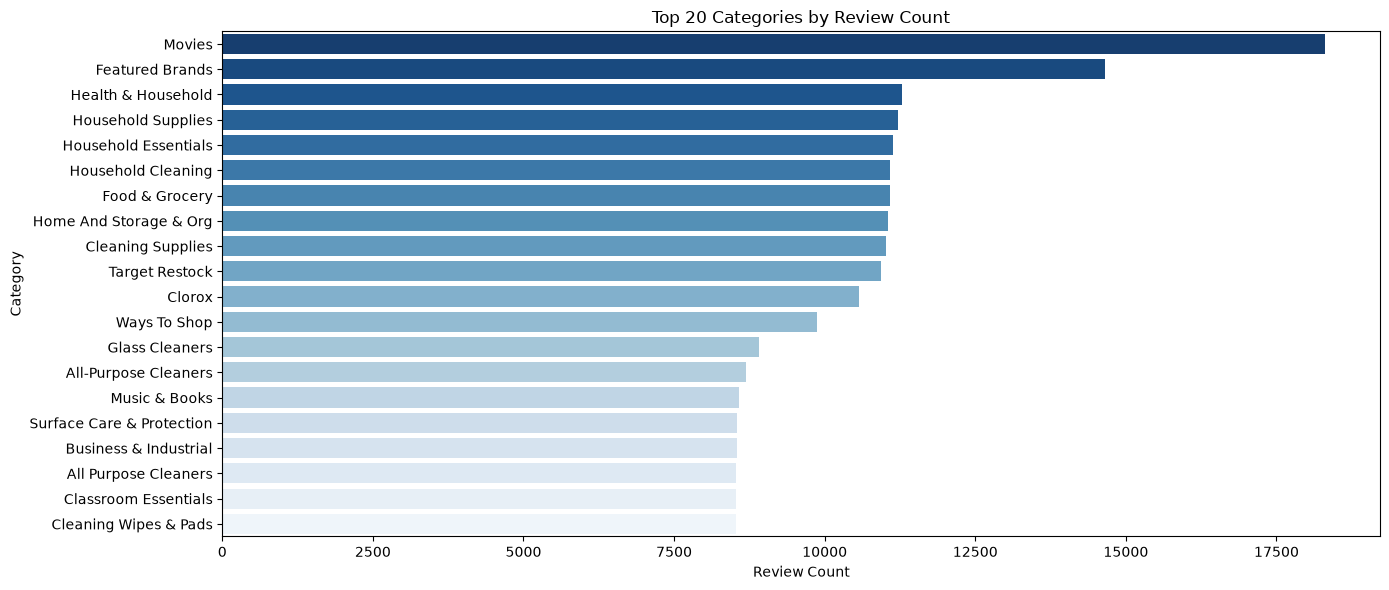

<Figure size 1400x600 with 0 Axes>

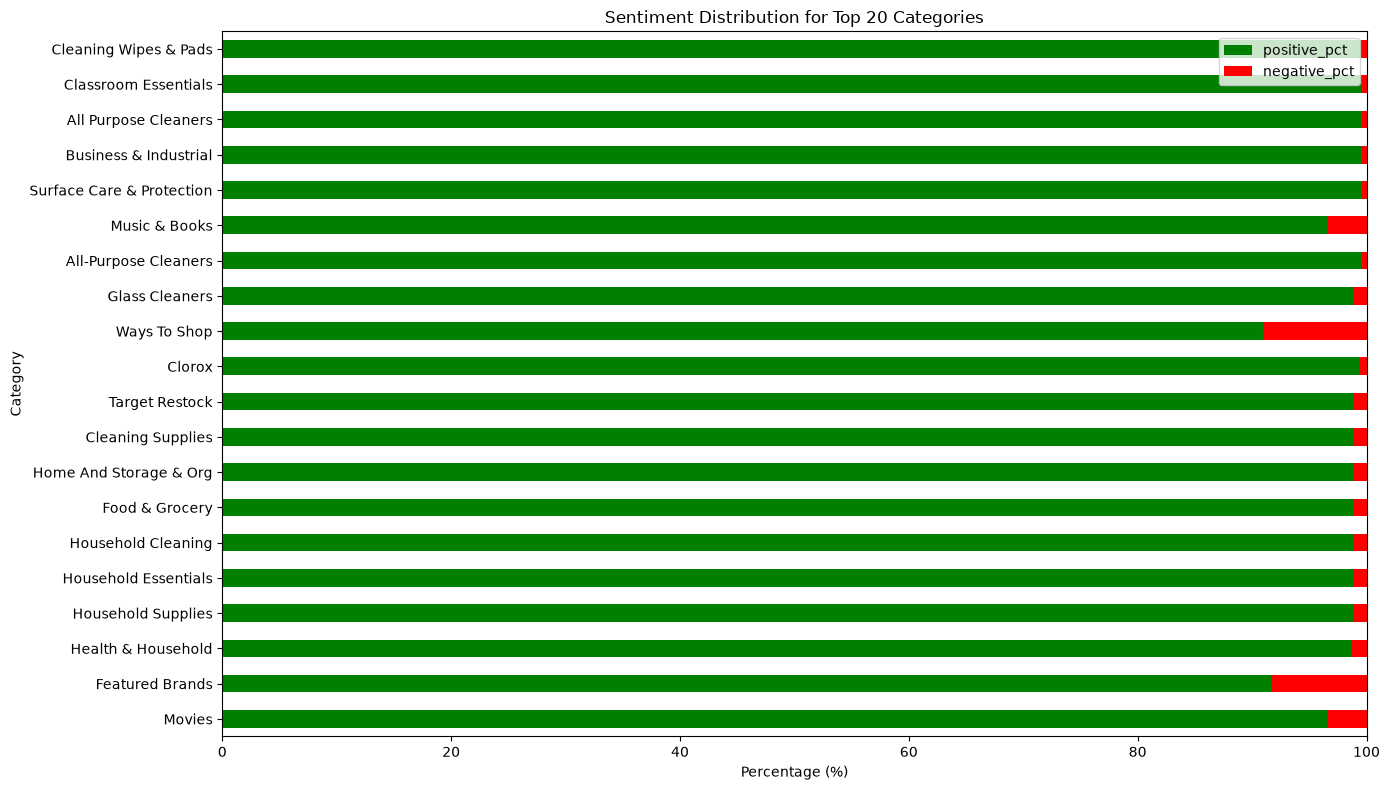

In [41]:
# compare category level sentiment distribution
category_df = (
    reviews_df_cleaned
    .assign(categories=reviews_df_cleaned["categories"].fillna("Missing").astype(str))
    .assign(category=lambda df: df["categories"].str.split(","))
    .explode("category")
    .assign(category=lambda df: df["category"].str.strip().replace("", "Missing"))
)

category_sentiment = (
    category_df
    .groupby(["category", "user_sentiment"])
    .size()
    .unstack(fill_value=0)
)

category_sentiment["total_reviews"] = category_sentiment.sum(axis=1)
category_sentiment["positive_pct"] = (
    category_sentiment["Positive"] / category_sentiment["total_reviews"] * 100
).round(2)
category_sentiment["negative_pct"] = (
    category_sentiment["Negative"] / category_sentiment["total_reviews"] * 100
).round(2)

category_rating = (
    category_df
    .groupby("category")
    .agg(
        avg_rating=("reviews_rating", "mean"),
        review_count=("reviews_rating", "count"),
    )
    .assign(avg_rating=lambda df: df["avg_rating"].round(2))
)

category_summary = (
    category_sentiment
    .join(category_rating)
    .sort_values("review_count", ascending=False)
)

display(category_summary.head(20).style.format({
    "avg_rating": "{:.2f}",
    "positive_pct": "{:.2f}%",
    "negative_pct": "{:.2f}%"
}))

top_categories = category_summary.head(20).reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(
    data=top_categories,
    x="review_count",
    y="category",
    hue="category",
    palette = "Blues_r",
    legend=False
)
plt.title("Top 20 Categories by Review Count")
plt.xlabel("Review Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
top_categories.plot(
    kind="barh",
    x="category",
    y=["positive_pct", "negative_pct"],
    stacked=True,
    color=["green", "red"],
    legend=True,
    figsize=(14, 8)
)
plt.title("Sentiment Distribution for Top 20 Categories")
plt.xlabel("Percentage (%)")
plt.ylabel("Category")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

#### Observation

Clorox brand has received the highest number of reviewes (10564) with positive (99.47%) and negative (0.53%) reviews. This is primarily because it makes up 35.68% of the total branded data, leading to a higher volume of feedback overall. 

### 2.9. User-Level Analysis

- Count unique users.
- Analyze reviews per user.
- Identify the most active users.
- Count users with only one review.
- Inspect the rating behavior of active users.

In [42]:
#Count unique users.
display_info(reviews_df_cleaned['reviews_username'].nunique(),"Total No Of Unique Users:")

--------------------------------------------------
Total No Of Unique Users:: 24670
--------------------------------------------------


--------------------------------------------------
Users review distribution: Review counts per user summary
--------------------------------------------------
count    24670.00
mean         1.20
std          0.76
min          1.00
25%          1.00
50%          1.00
75%          1.00
max         41.00
--------------------------------------------------
Users with exactly 1 review:: 21086
--------------------------------------------------
--------------------------------------------------
Users with more than 1 review: : 3584
--------------------------------------------------
--------------------------------------------------
Users with 5 or more reviews:: 147
--------------------------------------------------
--------------------------------------------------
Users with 10 or more reviews:: 23
--------------------------------------------------
--------------------------------------------------
Top 20 most active users by review count: 
--------------------------------------------------

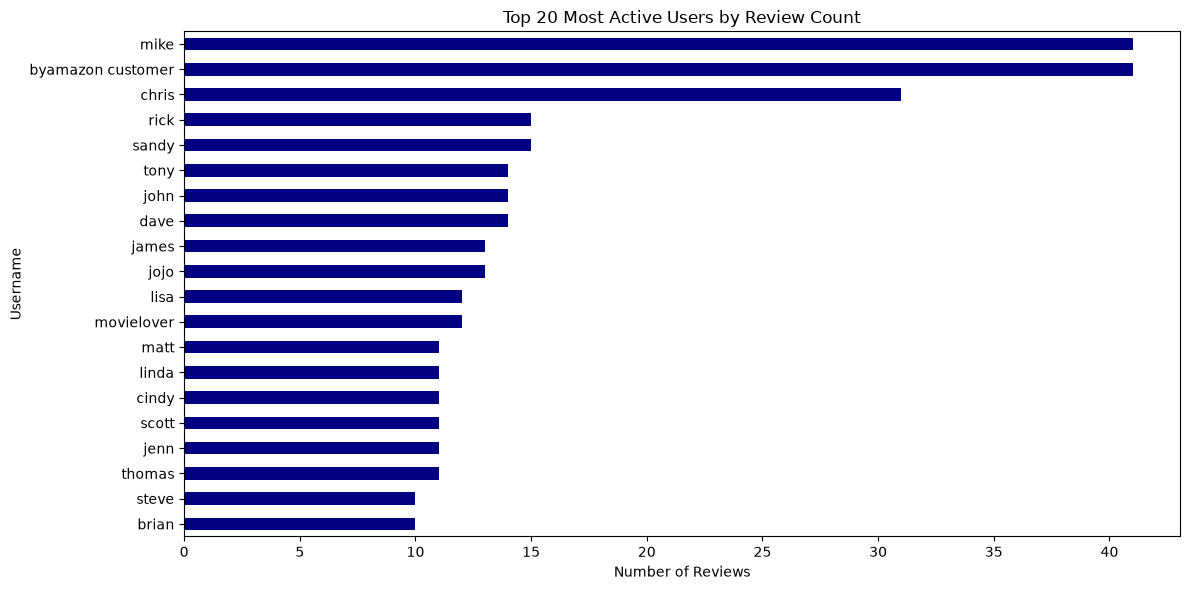

In [43]:
# Analyze review counts per user
user_review_counts = reviews_df_cleaned["reviews_username"].value_counts()

review_summary = user_review_counts.describe()
single_review_users = (user_review_counts == 1).sum()
multi_review_users = (user_review_counts > 1).sum()
users_5plus = (user_review_counts >= 5).sum()
users_10plus = (user_review_counts >= 10).sum()

display_info("Review counts per user summary", "Users review distribution")
print(review_summary.to_string())
display_info(single_review_users,"Users with exactly 1 review:")
display_info(multi_review_users,"Users with more than 1 review: ")
display_info(users_5plus,"Users with 5 or more reviews:")
display_info(users_10plus,"Users with 10 or more reviews:")

display_info("", "Top 20 most active users by review count")
# display(user_review_counts.head(20))

# Plot top users
plt.figure(figsize=(12, 6))
user_review_counts.head(20).sort_values().plot(
    kind="barh",
    color="navy"
)
plt.title("Top 20 Most Active Users by Review Count")
plt.xlabel("Number of Reviews")
plt.ylabel("Username")
plt.tight_layout()
plt.show()

--------------------------------------------------
Active users with ≥5 reviews: 147
--------------------------------------------------


,review_count,avg_rating,min_rating,max_rating,std_rating,pct_5_star,pct_1_star
reviews_username,,,,,,,
mike,41,4.41,1,5,1.00,63.41,4.88
byamazon customer,41,3.95,1,5,1.67,65.85,21.95
chris,31,4.55,2,5,0.77,67.74,0.00
rick,15,4.47,1,5,1.13,73.33,6.67
sandy,15,4.47,1,5,1.41,86.67,13.33
john,14,4.71,3,5,0.61,78.57,0.00
tony,14,4.57,3,5,0.65,64.29,0.00
dave,14,3.93,1,5,1.64,57.14,21.43
jojo,13,4.77,4,5,0.44,76.92,0.00


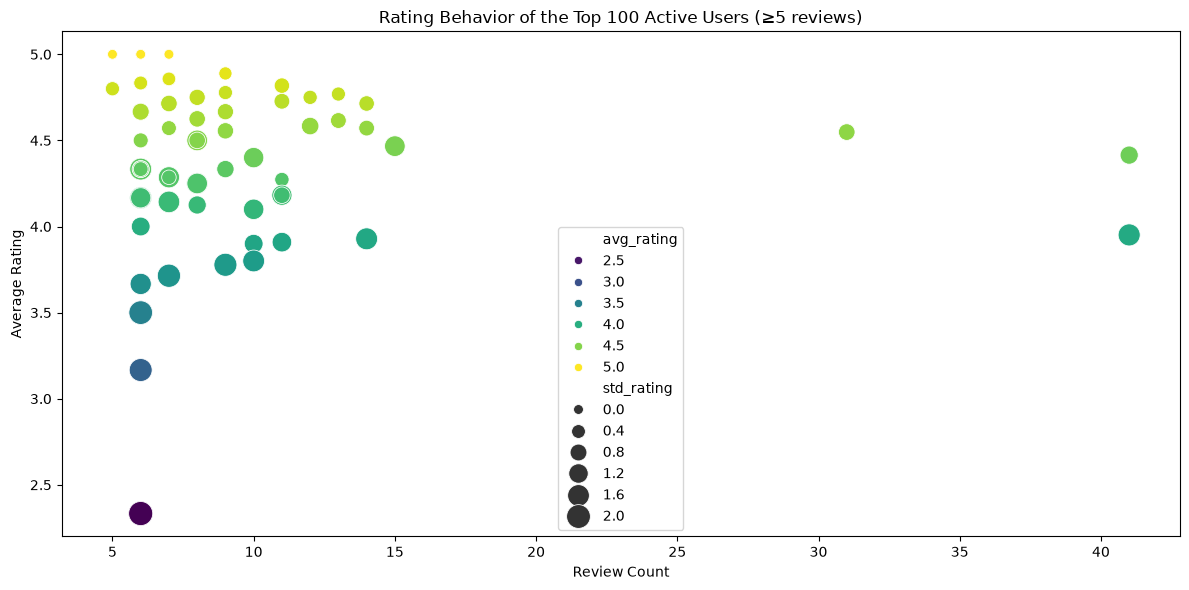

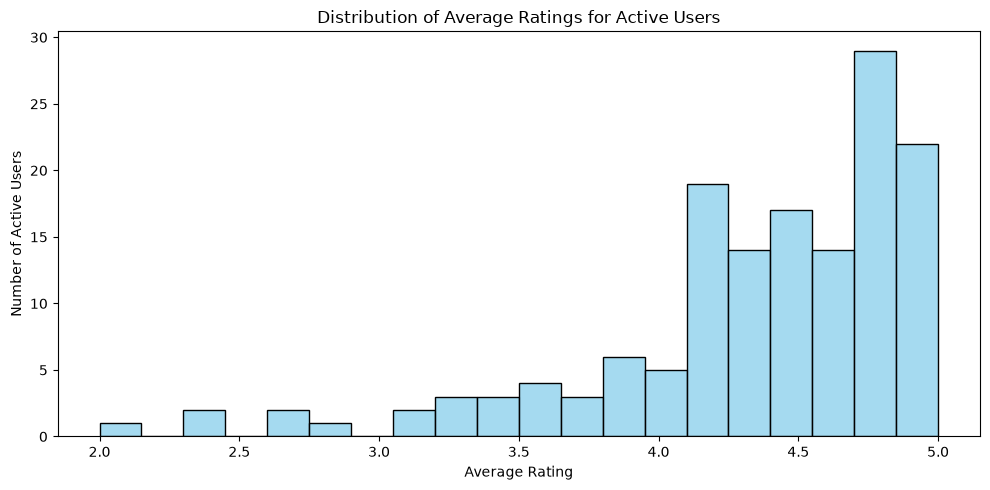

In [44]:
active_user_threshold = 5

active_users = user_review_counts[user_review_counts >= active_user_threshold].index

active_user_rating_behavior = (
    reviews_df_cleaned[reviews_df_cleaned["reviews_username"].isin(active_users)]
    .groupby("reviews_username")
    .agg(
        review_count=("reviews_rating", "count"),
        avg_rating=("reviews_rating", "mean"),
        min_rating=("reviews_rating", "min"),
        max_rating=("reviews_rating", "max"),
        std_rating=("reviews_rating", "std"),
        pct_5_star=("reviews_rating", lambda x: (x == 5).mean() * 100),
        pct_1_star=("reviews_rating", lambda x: (x == 1).mean() * 100),
    )
    .sort_values(["review_count", "avg_rating"], ascending=[False, False])
)

display_info(len(active_users), f"Active users with ≥{active_user_threshold} reviews")
display(
    active_user_rating_behavior.head(20).round(
        {"avg_rating": 2, "std_rating": 2, "pct_5_star": 2, "pct_1_star": 2}
    )
)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=active_user_rating_behavior.reset_index().head(100),
    x="review_count",
    y="avg_rating",
    size="std_rating",
    hue="avg_rating",
    palette="viridis",
    sizes=(50, 300),
    legend="brief",
)
plt.title(f"Rating Behavior of the Top 100 Active Users (≥{active_user_threshold} reviews)")
plt.xlabel("Review Count")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(active_user_rating_behavior["avg_rating"], bins=20, color="skyblue")
plt.title("Distribution of Average Ratings for Active Users")
plt.xlabel("Average Rating")
plt.ylabel("Number of Active Users")
plt.tight_layout()
plt.show()

### 2.10. Date Analysis

- Convert `reviews_date` to datetime.
- Check the available date range.
- Analyze review counts over time.
- Analyze rating trends over time.
- Analyze sentiment trends over time.

In [45]:
# Convert the reviews_date to datetime.
reviews_df_cleaned.info()
reviews_df_cleaned['reviews_date'] = pd.to_datetime(
    reviews_df_cleaned['reviews_date'],
    format='mixed',
    errors='coerce',
    utc=True
)
display_info("","After changing to datetime:")
reviews_df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 29607 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                29607 non-null  str  
 1   brand             29607 non-null  str  
 2   categories        29607 non-null  str  
 3   manufacturer      29607 non-null  str  
 4   name              29607 non-null  str  
 5   reviews_date      29567 non-null  str  
 6   reviews_rating    29607 non-null  int64
 7   reviews_text      29607 non-null  str  
 8   reviews_title     29607 non-null  str  
 9   reviews_username  29607 non-null  str  
 10  user_sentiment    29606 non-null  str  
dtypes: int64(1), str(10)
memory usage: 3.7 MB
--------------------------------------------------
After changing to datetime:: 
--------------------------------------------------
<class 'pandas.DataFrame'>
Index: 29607 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype      

In [46]:
# check available date range and missing values
display_info(reviews_df_cleaned["reviews_date"].min(), "Earliest date")
display_info(reviews_df_cleaned["reviews_date"].max(),"Latest date")
display_info(reviews_df_cleaned["reviews_date"].isna().sum(), "Missing/invalid dates")

--------------------------------------------------
Earliest date: 2007-06-06 00:00:00+00:00
--------------------------------------------------
--------------------------------------------------
Latest date: 2018-01-10 19:56:37+00:00
--------------------------------------------------
--------------------------------------------------
Missing/invalid dates: 48
--------------------------------------------------


#### Observation

We have 564 rows with missing or invalid dates. To fix this lets find the most occouring date in the data set (mode) of the date range and replace the missing dates with that value 


#### Data Cleaning

- Find mode of the date range
- replace missing dates with the mode 

In [47]:
mode_date = reviews_df_cleaned['reviews_date'].mode()[0]
display_info(mode_date,"Mode Date")
display_info(reviews_df_cleaned["reviews_date"].isna().sum(), "Missing/invalid dates after cleaning")

--------------------------------------------------
Mode Date: 2012-01-26 00:00:00+00:00
--------------------------------------------------
--------------------------------------------------
Missing/invalid dates after cleaning: 48
--------------------------------------------------


--------------------------------------------------
Monthly Review Count: 
--------------------------------------------------


,reviews_date,review_count
90,2014-12-01 00:00:00+00:00,4393
55,2012-01-01 00:00:00+00:00,3036
91,2015-01-01 00:00:00+00:00,2202
115,2017-01-01 00:00:00+00:00,1395
92,2015-02-01 00:00:00+00:00,1109
...,...,...
16,2008-10-01 00:00:00+00:00,1
9,2008-03-01 00:00:00+00:00,0
5,2007-11-01 00:00:00+00:00,0
17,2008-11-01 00:00:00+00:00,0


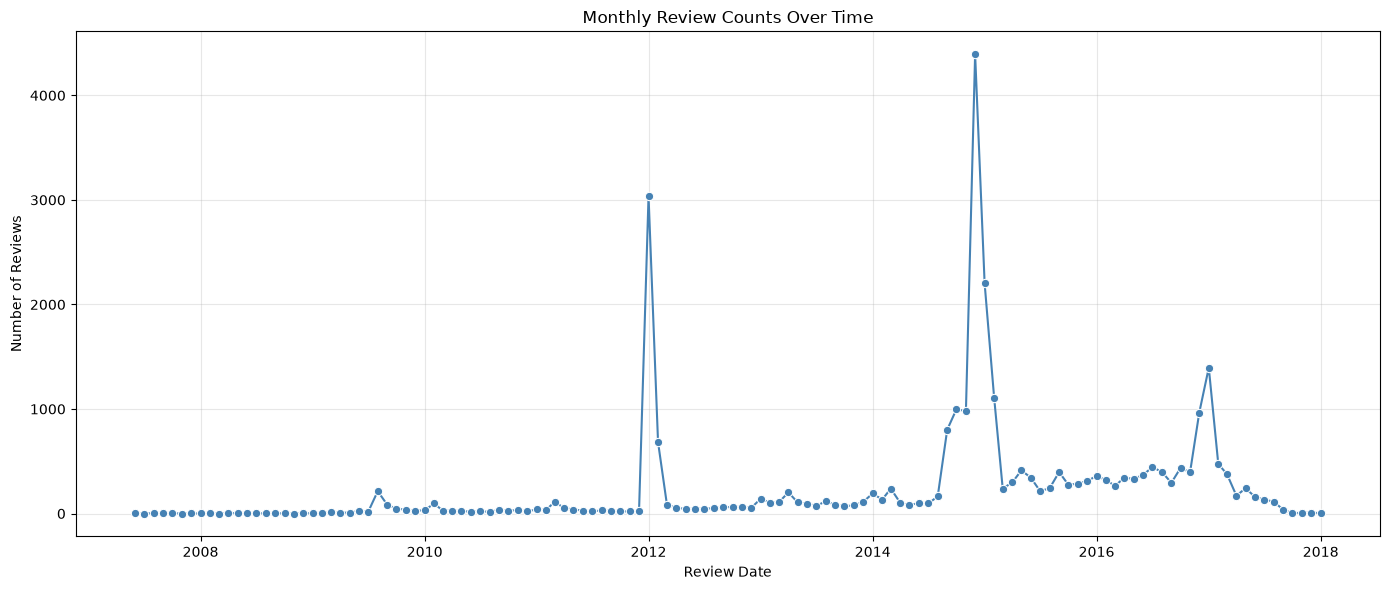

In [48]:
# Analyze the number of reviews submitted each month.
monthly_review_counts = (
    reviews_df_cleaned
    .dropna(subset=["reviews_date"])
    .set_index("reviews_date")
    .resample("MS")
    .size()
    .rename("review_count")
    .reset_index()
)

display_info("","Monthly Review Count")
display(monthly_review_counts.sort_values(by="review_count", ascending=False))

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_review_counts,
    x="reviews_date",
    y="review_count",
    marker="o",
    color="steelblue"
)
plt.title("Monthly Review Counts Over Time")
plt.xlabel("Review Date")
plt.ylabel("Number of Reviews")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,reviews_date,average_rating,median_rating,review_count,six_month_average
0,2007-06-01 00:00:00+00:00,5.00,5.0,1,5.00
1,2007-07-01 00:00:00+00:00,NaN,NaN,0,5.00
2,2007-08-01 00:00:00+00:00,5.00,5.0,3,5.00
3,2007-09-01 00:00:00+00:00,5.00,5.0,2,5.00
4,2007-10-01 00:00:00+00:00,5.00,5.0,3,5.00
...,...,...,...,...,...
123,2017-09-01 00:00:00+00:00,4.33,5.0,36,4.36
124,2017-10-01 00:00:00+00:00,4.25,4.0,4,4.34
125,2017-11-01 00:00:00+00:00,3.86,5.0,7,4.24
126,2017-12-01 00:00:00+00:00,4.89,5.0,9,4.33


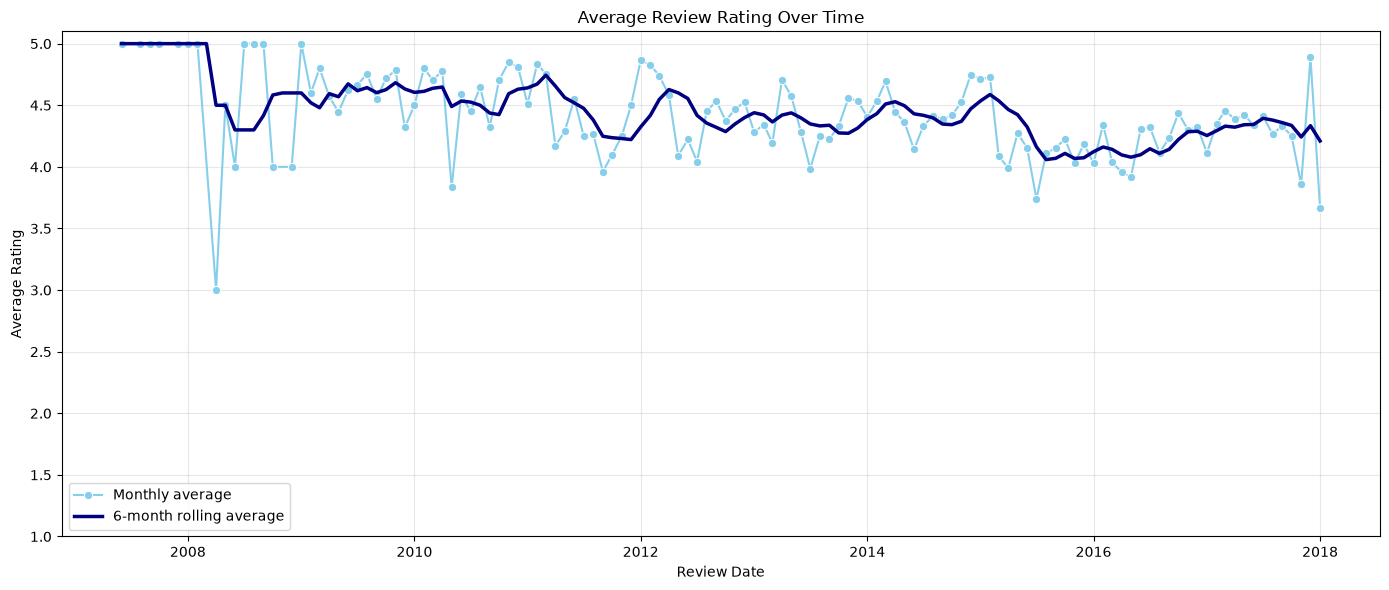

In [49]:
# Analyze monthly rating trends over time.
monthly_rating_trend = (
    reviews_df_cleaned
    .dropna(subset=["reviews_date", "reviews_rating"])
    .set_index("reviews_date")
    .resample("MS")
    .agg(
        average_rating=("reviews_rating", "mean"),
        median_rating=("reviews_rating", "median"),
        review_count=("reviews_rating", "count")
    )
    .reset_index()
)

monthly_rating_trend["six_month_average"] = (
    monthly_rating_trend["average_rating"]
    .rolling(window=6, min_periods=1)
    .mean()
)

rating_trend_display = monthly_rating_trend.copy()
rating_columns = ["average_rating", "median_rating", "six_month_average"]
rating_trend_display[rating_columns] = rating_trend_display[rating_columns].round(2)
display(rating_trend_display)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_rating_trend,
    x="reviews_date",
    y="average_rating",
    marker="o",
    color="skyblue",
    label="Monthly average"
)
sns.lineplot(
    data=monthly_rating_trend,
    x="reviews_date",
    y="six_month_average",
    color="navy",
    linewidth=2.5,
    label="6-month rolling average"
)
plt.title("Average Review Rating Over Time")
plt.xlabel("Review Date")
plt.ylabel("Average Rating")
plt.ylim(1, 5.1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

--------------------------------------------------
Sentiment Trend Over Time: 
--------------------------------------------------


user_sentiment,reviews_date,Negative,Positive
0,2007-06-01 00:00:00+00:00,0.00%,100.00%
1,2007-08-01 00:00:00+00:00,0.00%,100.00%
2,2007-09-01 00:00:00+00:00,0.00%,100.00%
3,2007-10-01 00:00:00+00:00,0.00%,100.00%
4,2007-12-01 00:00:00+00:00,0.00%,100.00%


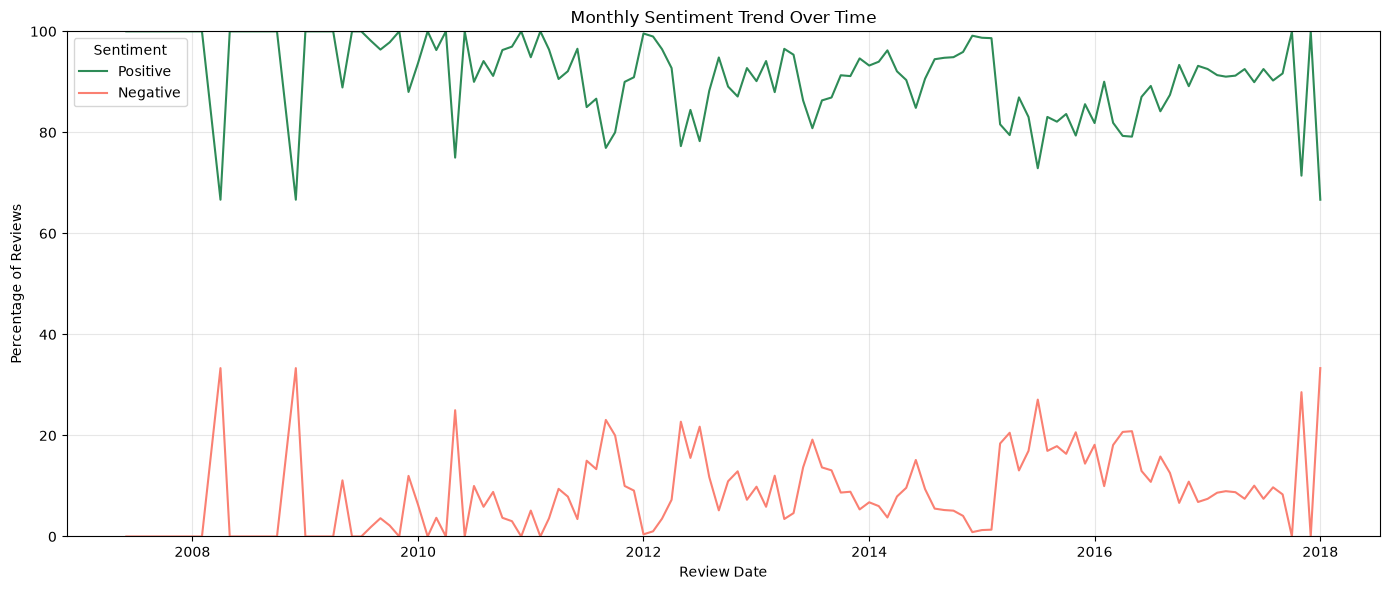

In [50]:
# Analyze monthly sentiment trends over time.
monthly_sentiment_trend = (
    reviews_df_cleaned
    .dropna(subset=["reviews_date", "user_sentiment"])
    .groupby([pd.Grouper(key="reviews_date", freq="MS"), "user_sentiment"])
    .size()
    .unstack(fill_value=0)
)

sentiment_percentages = monthly_sentiment_trend.div(
    monthly_sentiment_trend.sum(axis=1),
    axis=0
).mul(100).reset_index()

display_info("","Sentiment Trend Over Time")

display(sentiment_percentages.head().round({"Positive": 2, "Negative": 2}).style.format({"Positive": "{:.2f}%","Negative": "{:.2f}%"}))  

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=sentiment_percentages,
    x="reviews_date",
    y="Positive",
    color="seagreen",
    label="Positive"
)
sns.lineplot(
    data=sentiment_percentages,
    x="reviews_date",
    y="Negative",
    color="salmon",
    label="Negative"
)
plt.title("Monthly Sentiment Trend Over Time")
plt.xlabel("Review Date")
plt.ylabel("Percentage of Reviews")
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

#### Observations:

Clearly the class imbalance is still present, as the ratings are heavily skwed towards positive sentiment over the entire time period. 

### 2.11. Review Text Analysis 

- Check missing, empty, or very short reviews.
- Calculate review length by characters and words.
- Compare review length across sentiment classes.
- Inspect common words before preprocessing.
- Identify text quality issues such as casing, punctuation, special characters, URLs, HTML, or noisy tokens.

In [51]:
#Check missing, empty, or very short reviews.
display_info(reviews_df_cleaned['reviews_text'].isnull().sum(),"Missing review counts")
display_info(reviews_df_cleaned.query("reviews_text.str.split().str.len() < 3",engine="python").shape[0],"Very short review count")
display(reviews_df_cleaned.query("reviews_text.str.split().str.len() < 3",engine="python").head())

--------------------------------------------------
Missing review counts: 0
--------------------------------------------------
--------------------------------------------------
Very short review count: 291
--------------------------------------------------


,id,brand,categories,manufacturer,name,reviews_date,reviews_rating,reviews_text,reviews_title,reviews_username,user_sentiment
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09 00:00:00+00:00,5,Good flavor.,Good,dorothy w,Positive
682,AV1l8zRZvKc47QAVhnAv,Olay,"Personal Care,Skin Care,Anti-Aging,Beauty,Face Moisturizers,Facial Moisturizers,Moisturizers,Creams & Moisturizers",P&G,Olay Regenerist Deep Hydration Regenerating Cream,2015-10-18 00:00:00+00:00,5,Excellent product.,Best prices,themuk,Positive
793,AV1YGDqsGV-KLJ3adc-O,Windex,"Household Essentials,Cleaning Supplies,Glass Cleaners,Health & Household,Household Supplies,Household Cleaning,Featured Brands,Home And Storage & Org,Thanksgathering,All-purpose Cleaners,Target Restock,Food & Grocery,Glass & Window",Windex,Windex Original Glass Cleaner Refill 67.6oz (2 Liter),2017-03-08 00:00:00+00:00,4,Good,Betty,betty,Positive
858,AV1YGDqsGV-KLJ3adc-O,Windex,"Household Essentials,Cleaning Supplies,Glass Cleaners,Health & Household,Household Supplies,Household Cleaning,Featured Brands,Home And Storage & Org,Thanksgathering,All-purpose Cleaners,Target Restock,Food & Grocery,Glass & Window",Windex,Windex Original Glass Cleaner Refill 67.6oz (2 Liter),2016-02-25 00:00:00+00:00,5,Great,Windex,debo,Positive
901,AV1YGDqsGV-KLJ3adc-O,Windex,"Household Essentials,Cleaning Supplies,Glass Cleaners,Health & Household,Household Supplies,Household Cleaning,Featured Brands,Home And Storage & Org,Thanksgathering,All-purpose Cleaners,Target Restock,Food & Grocery,Glass & Window",Windex,Windex Original Glass Cleaner Refill 67.6oz (2 Liter),2016-05-18 00:00:00+00:00,5,Great product,Great Product,windowcleaner,Positive


In [52]:
# Normalize review text before calculating lengths
review_text = (
    reviews_df_cleaned["reviews_text"]
    .fillna("")
    .str.strip()
)

# Calculate review length
reviews_df_cleaned["review_char_count"] = review_text.str.len()
reviews_df_cleaned["review_word_count"] = review_text.str.split().str.len()

# Preview results
display(
    reviews_df_cleaned[
        ["reviews_text", "review_char_count", "review_word_count"]
    ].head(10)
)

,reviews_text,review_char_count,review_word_count
0,i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,201,41
1,Good flavor. This review was collected as part of a promotion.,62,11
2,Good flavor.,12,2
3,"I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation. What we did ...",696,124
4,My husband bought this gel for us. The gel caused irritation and it felt like it was burning my skin. I wouldn't recommend this gel.,132,25
5,My boyfriend and I bought this to spice things up in the bedroom and we were both highly disappointed in this product. We bought this one because we absolutely love the ky yours and mine and we thought this would have a similar affect but it did absolutely nothing. Do not buy.,277,52
6,Bought this earlier today and was excited to check it out. Based on the product description I was expecting something but it was just like the regular KY. We are fans of the his and hers so we just expected more and were left a little disappointed.,248,47
7,I bought this product for my husband and I to try and we were not impressed at all. There was no tingling or warming. It left us both very sticky. I have used KY products in the past (loved KY his and hers) but this one was disappointing.,238,48
8,My husband and I bought this for some extra fun. We werevboth extremely disappointed. Especially for the price! Do not waste your money on this product. We felt nothing but a sticky mess from it.,195,35
9,Got as a surprise for my husband there is nothing special about it just a lube save the money and get plain KY if you just need a lube wish I could return it for a refund,170,37


In [53]:
# Compare review length statistics across sentiment classes
sentiment_length_summary = (
    reviews_df_cleaned
    .groupby("user_sentiment")
    .agg(
        review_count=("reviews_text", "count"),
        mean_char_count=("review_char_count", "mean"),
        median_char_count=("review_char_count", "median"),
        mean_word_count=("review_word_count", "mean"),
        median_word_count=("review_word_count", "median")
    )
    .round(2)
)

display(sentiment_length_summary)

,review_count,mean_char_count,median_char_count,mean_word_count,median_word_count
user_sentiment,,,,,
Negative,1979,298.91,237.0,56.78,45.0
Positive,27627,174.79,128.0,32.79,24.0


--------------------------------------------------
Common Words Before TextPreprocessing: 
--------------------------------------------------


,word,frequency
0,the,42572
1,i,37791
2,and,32585
3,a,29679
4,this,25735
5,it,23131
6,to,22932
7,of,20898
8,my,17061
9,was,15720


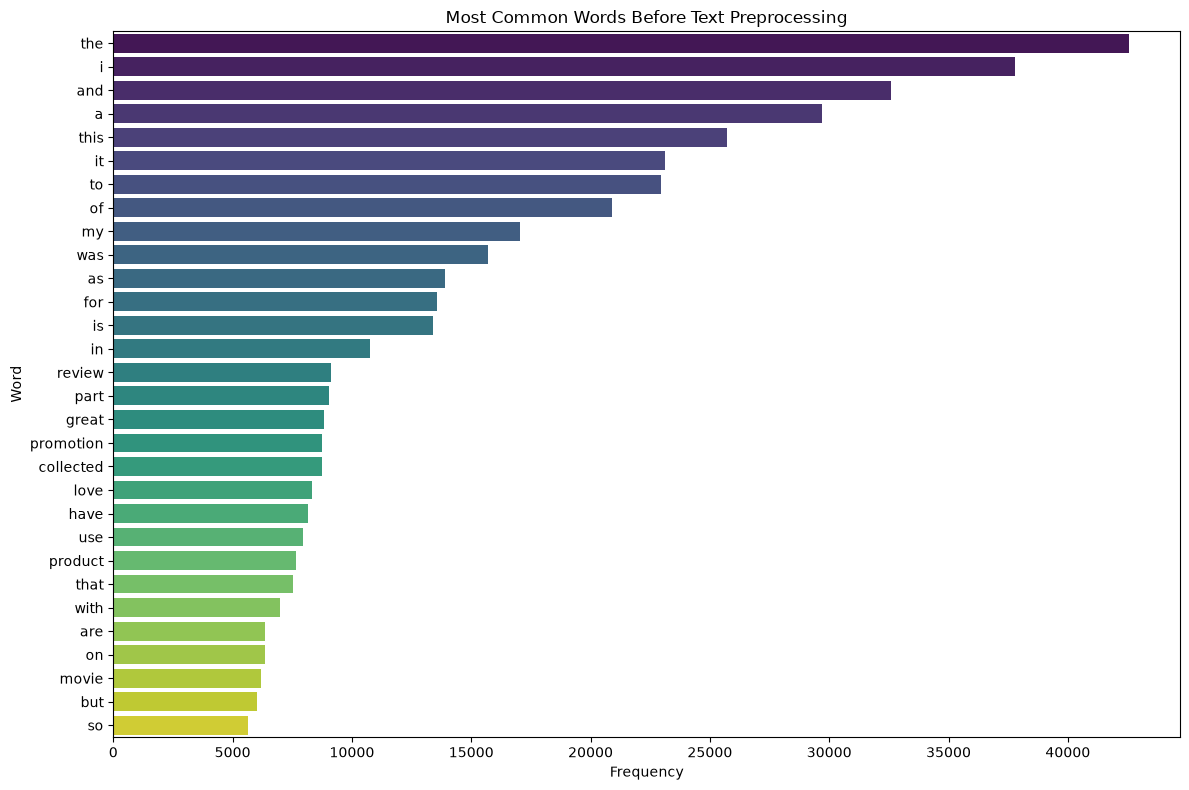

In [54]:
import re
from collections import Counter

all_review_text = " ".join(
    reviews_df_cleaned["reviews_text"]
    .dropna()
    .astype(str)
)

# Basic tokenization without stop-word removal or stemming
raw_words = re.findall(
    r"\b[a-zA-Z']+\b",
    all_review_text.lower()
)

common_words = pd.DataFrame(
    Counter(raw_words).most_common(30),
    columns=["word", "frequency"]
)

display_info("","Common Words Before TextPreprocessing")
display(common_words)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=common_words,
    x="frequency",
    y="word",
    hue="word",
    palette="viridis",
    legend=False
)

plt.title("Most Common Words Before Text Preprocessing")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

--------------------------------------------------
Common Words After StopWord Removal: 
--------------------------------------------------


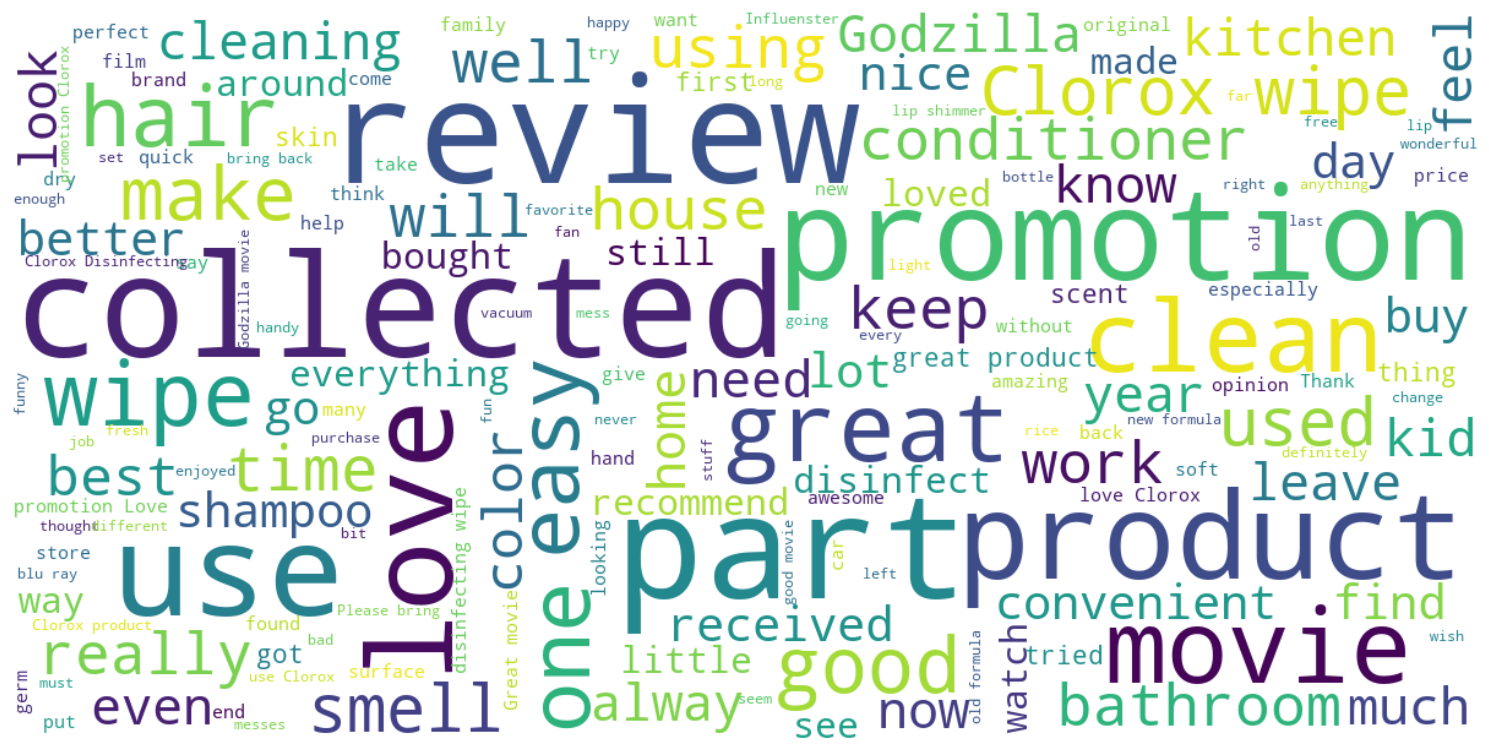

In [55]:
display_info("","Common Words After StopWord Removal")
# Combine all review texts into a single string
text_data = " ".join(reviews_df_cleaned['reviews_text'].dropna().astype(str).tolist())

# Define stopwords
stopwords = set(STOPWORDS)

# Generate Word Cloud
wordcloud = WordCloud(
    background_color='white',
    stopwords=stopwords,
    max_words=300,
    max_font_size=40,
    scale=3,
    random_state=1
).generate(text_data)

# Plotting the Word Cloud
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

In [56]:
text = (
    reviews_df_cleaned["reviews_text"]
    .fillna("")
    .astype(str)
)

text_issues = {
    "Missing or empty": text.str.strip().eq(""),
    
    "All-uppercase review": text.str.isupper(),
    
    "Contains punctuation": text.str.contains(
        r"[^\w\s]",
        regex=True
    ),
    
    "Repeated punctuation": text.str.contains(
        r"[!?.,]{2,}",
        regex=True
    ),
    
    "Contains special/non-ASCII characters": text.str.contains(
        r"[^\x00-\x7F]",
        regex=True
    ),
    
    "Contains URL": text.str.contains(
        r"https?://\S+|www\.\S+",
        case=False,
        regex=True
    ),
    
    "Contains HTML": text.str.contains(
        r"<[^>]+>|&[a-zA-Z]+;",
        regex=True
    ),
    
    "Contains token with numbers": text.str.contains(
        r"\b\w*\d+\w*\b",
        regex=True
    ),
    
    "Contains very long token": text.str.contains(
        r"\b\w{25,}\b",
        regex=True
    ),
    
    "Extra whitespace": (
        text.ne(text.str.strip())
        | text.str.contains(r"\s{2,}", regex=True)
    )
}

text_quality_summary = pd.DataFrame({
    "Issue": text_issues.keys(),
    "Count": [mask.sum() for mask in text_issues.values()]
})

text_quality_summary["Percentage"] = (
    text_quality_summary["Count"]
    .div(len(reviews_df_cleaned))
    .mul(100)
    .round(2)
)

display(
    text_quality_summary.style.format({
        "Percentage": "{:.2f}%"
    })
)

,Issue,Count,Percentage
0,Missing or empty,0,0.00%
1,All-uppercase review,183,0.62%
2,Contains punctuation,28105,94.93%
3,Repeated punctuation,3859,13.03%
4,Contains special/non-ASCII characters,0,0.00%
5,Contains URL,10,0.03%
6,Contains HTML,0,0.00%
7,Contains token with numbers,4002,13.52%
8,Contains very long token,9,0.03%
9,Extra whitespace,3,0.01%


In [57]:
for issue, mask in text_issues.items():
    print(f"\n{issue}: {mask.sum()} rows")

    display(
        reviews_df_cleaned.loc[
            mask,
            ["reviews_text", "user_sentiment"]
        ].head(5)
    )


Missing or empty: 0 rows


,reviews_text,user_sentiment



All-uppercase review: 183 rows


,reviews_text,user_sentiment
606,"THIS MOISTURIZER REALLY DOES WORK. MY SKIN FEELS LIKE SILK AFTER I HAVE APPLIED IT. I HAD NOT SEEN MY FRIEND FOR ABOUT 3 WEEKS WHEN SHE SAW ME, SHE SAID STEP BACK, I HAVE TO LOOK AT YOUR FACE.. OK WHAT HAVE YOU DONE, YOUR FACE LOOKS FANTASTIC WELL THAT WAS ALL I NEEDED, I'M HOOKED NOW !!!! THANK...",Positive
836,WINDEX IA A FANTASTIC PRODUCT FOR CLEANING WINDOWS SO MUCH MORE.,Positive
887,"WINDEX IS GREAT,IT CLEANS GLASS WITHOUT LEAVING ANY STREAKS.IT ALSO CLEANS MIRRORS,AND TV SCREENS.",Positive
1076,IT LEAVES MY HAIR AND SCALP DRIED OUT. IT DOES PROVIDE ANY VOLUME.,Negative
1152,"FAST SHIPPING ,EXCELLENT PRODUCTS FOR HAIR",Positive



Contains punctuation: 28105 rows


...

,reviews_text,user_sentiment
0,i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,Positive
3,"I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation. What we did ...",Negative
12,"Bought this to enhance our time a bit, did abslutely nothing very disappointed especially because its almost 20!",Negative
25,"I really enjoyed using this product with my husband. After 20+ years of marriage, things can tend to get a little tired and boring. This was just the thing we needed to shake things up a bit. The packaging and pump dispenser is awesome. The product itself does not disappoint. A little goes a ver...",Positive
26,Awesome Product for couples. It is a warm feeling lubricant and not sticky like a lot of other lubricants.It is very easy to clean up after use.I will absolutely be purchasing more in the future. I received this product free for the purpose to give my review..Opinions are 100 my own!,Positive



Contains very long token: 9 rows


,reviews_text,user_sentiment
1665,"This has to be the best movie in the whole world, it has amazing actors -Johnny Depp!!- and its hilarious. I love this movie sooooooooooooooooooooooooooooo much!",Positive
1783,"This has to be the best movie in the whole world, it has amazing actors -Johnny Depp!!- and its hilarious. I love this movie sooooooooooooooooooooooooooooo much!",Positive
2931,Funny movieFunnyFunnyLoveFunnyFunnyLoveFunny,Positive
6001,Action movie x-xxxxxxxxxxxxxxxxxxxxxxxxxcccccccxcc,Positive
7196,THis product is very awesomeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee This review was collected as part of a promotion.,Positive



Extra whitespace: 3 rows


,reviews_text,user_sentiment
4408,"First, a disclaimer of sorts . Im a long-term, died-in-the-wool Hoover evangelist. No, I dont work for Hoover, but Ive used Hoovers religiously for 30 years. Ive tried switching off to other top-of-the-line brands, but always returned to Hoover for their unsurpassed cleaning power and reliabilit...",Positive
5550,"I love sci-fi and this show caught my attention. I would compare this show to be similar to Lost (which I also love), and Lord of the Fries. The characters are believable, even the ""bad guys"" the desperation and their willingness to do whatever it takes to survive made that show more exciting....",Positive
6075,"Opening Scene: The mundane daily routine of a retired CIA Covert Operative is exposed it was routine. The show is most likely one of the best spy counter spy flicks that I have seen. With a superb blend of senior casting, sensitive directorship, and a very well-written plot-line of pure table-...",Positive


## 3. Preprocessing
### 3.1. Data Type Conversion
- Ensure the correct dtype
- Standardize column names (e.g., snake_case)

In [58]:
# check and convert all obj type columns
reviews_df_cleaned[reviews_df_cleaned.select_dtypes(include=['object','str']).columns].astype('string')
display_info(reviews_df_cleaned.shape, "Shape of DataFrame")
reviews_df_cleaned.info()


--------------------------------------------------
Shape of DataFrame: (29607, 13)
--------------------------------------------------
<class 'pandas.DataFrame'>
Index: 29607 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   id                 29607 non-null  str                
 1   brand              29607 non-null  str                
 2   categories         29607 non-null  str                
 3   manufacturer       29607 non-null  str                
 4   name               29607 non-null  str                
 5   reviews_date       29559 non-null  datetime64[us, UTC]
 6   reviews_rating     29607 non-null  int64              
 7   reviews_text       29607 non-null  str                
 8   reviews_title      29607 non-null  str                
 9   reviews_username   29607 non-null  str                
 10  user_sentiment     29606 non-null  str          

### 3.2. Combine the review feilds
- create sentiments dataset
- merge the reviews_title and reviews_text feilds into a single column reviews_full

In [59]:
 #create a working copy of the cleaned dataframe reviews_df_cleaned or text preprocessing
sentiments_df = reviews_df_cleaned.copy()

# combining the review_title and review_text into a single column
sentiments_df['reviews_full'] = sentiments_df['reviews_title'] + ' ' + sentiments_df['reviews_text']

# drop the review_title , review_text , review_char_count, review_word_count feilds
sentiments_df.drop(columns=['reviews_title', 'reviews_text'], inplace=True)

# Inspect the shape of the dataframe

display_info(sentiments_df.shape, "Inspect the shape of the dataframe")
display(sentiments_df.info())                       

--------------------------------------------------
Inspect the shape of the dataframe: (29607, 12)
--------------------------------------------------
<class 'pandas.DataFrame'>
Index: 29607 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   id                 29607 non-null  str                
 1   brand              29607 non-null  str                
 2   categories         29607 non-null  str                
 3   manufacturer       29607 non-null  str                
 4   name               29607 non-null  str                
 5   reviews_date       29559 non-null  datetime64[us, UTC]
 6   reviews_rating     29607 non-null  int64              
 7   reviews_username   29607 non-null  str                
 8   user_sentiment     29606 non-null  str                
 9   review_char_count  29607 non-null  int64              
 10  review_word_count  29607 non-nul

None

### 3.3. Drop Irrelevant Columns & Create Sentiment Dataset
 - Removing columns that are not useful for analysis 
 - Keep only the required columns for sentiment analysis 

In [60]:
#drop irrelevant columns

sentiments_df.drop(columns=['review_char_count', 'review_word_count','categories', 'manufacturer', 'reviews_date'], inplace=True)

In [61]:
display_info(sentiments_df.shape, "Inspect the shape of the sentiment dataframe")

sentiments_df.head()

--------------------------------------------------
Inspect the shape of the sentiment dataframe: (29607, 7)
--------------------------------------------------


,id,brand,name,reviews_rating,reviews_username,user_sentiment,reviews_full
0,AV13O1A8GV-KLJ3akUyj,Universal Music,Pink Friday: Roman Reloaded Re-Up (w/dvd),5,joshua,Positive,Just Awesome i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.
1,AV14LG0R-jtxr-f38QfS,Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,5,dorothy w,Positive,Good Good flavor. This review was collected as part of a promotion.
2,AV14LG0R-jtxr-f38QfS,Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,5,dorothy w,Positive,Good Good flavor.
3,AV16khLE-jtxr-f38VFn,K-Y,K-Y Love Sensuality Pleasure Gel,1,rebecca,Negative,"Disappointed I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation...."
4,AV16khLE-jtxr-f38VFn,K-Y,K-Y Love Sensuality Pleasure Gel,1,walker557,Negative,Irritation My husband bought this gel for us. The gel caused irritation and it felt like it was burning my skin. I wouldn't recommend this gel.


In [62]:
# keep only the columns required for the sentiments model 
sentiments_df = sentiments_df[['id','name','reviews_full', 'user_sentiment']]
display_info(sentiments_df.shape, "Inspect the shape of the sentiment dataframe")
sentiments_df.head()

--------------------------------------------------
Inspect the shape of the sentiment dataframe: (29607, 4)
--------------------------------------------------


,id,name,reviews_full,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Pink Friday: Roman Reloaded Re-Up (w/dvd),Just Awesome i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg Organic Cinnamon Toast Rice Cakes,Good Good flavor. This review was collected as part of a promotion.,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg Organic Cinnamon Toast Rice Cakes,Good Good flavor.,Positive
3,AV16khLE-jtxr-f38VFn,K-Y Love Sensuality Pleasure Gel,"Disappointed I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation....",Negative
4,AV16khLE-jtxr-f38VFn,K-Y Love Sensuality Pleasure Gel,Irritation My husband bought this gel for us. The gel caused irritation and it felt like it was burning my skin. I wouldn't recommend this gel.,Negative


### 3.4 Clean Punctuation and Stopwords
- Analyze the text quality and identify the issues
- Clean all issues like html, punctuations etc  
- Stripping stopwords from the reviews text

In [63]:
# 
def analyze_text_quality(df, text_column):
    """
    Analyze common quality issues in a text column.

    Returns:
        summary: DataFrame containing issue counts and percentages
        issue_masks: Boolean masks for inspecting affected rows
    """

    text = (
        df[text_column]
        .fillna("")
        .astype("string")
    )

    issue_masks = {
        "Missing or empty": text.str.strip().eq(""),

        "All-uppercase review": text.str.isupper(),

        "Contains punctuation": text.str.contains(
            r"[^\w\s]",
            regex=True
        ),

        "Repeated punctuation": text.str.contains(
            r"[!?.,]{2,}",
            regex=True
        ),

        "Contains special/non-ASCII characters": text.str.contains(
            r"[^\x00-\x7F]",
            regex=True
        ),

        "Contains URL": text.str.contains(
            r"https?://\S+|www\.\S+",
            case=False,
            regex=True
        ),

        "Contains HTML": text.str.contains(
            r"<[^>]+>|&[a-zA-Z]+;",
            regex=True
        ),

        "Contains token with numbers": text.str.contains(
            r"\b\w*\d+\w*\b",
            regex=True
        ),

        "Contains very long token": text.str.contains(
            r"\b\w{25,}\b",
            regex=True
        ),

        "Extra whitespace": (
            text.ne(text.str.strip())
            | text.str.contains(r"\s{2,}", regex=True)
        )
    }

    summary = pd.DataFrame({
        "Issue": issue_masks.keys(),
        "Count": [
            mask.sum()
            for mask in issue_masks.values()
        ]
    })

    summary["Percentage"] = (
        summary["Count"]
        .div(len(df))
        .mul(100)
        .round(2)
    )

    return summary, issue_masks

# call the function to analyze the text quality
text_quality_summary, text_issue_masks = analyze_text_quality(
    sentiments_df,
    "reviews_full"
)
# Summary of text issues:
display(
    text_quality_summary.style.format({
        "Percentage": "{:.2f}%"
    })
)


# Inspect rows for a particular issue:
for issue, mask in text_issue_masks.items():
    display_info(f"{mask.sum()}", issue)

    display(
        sentiments_df.loc[
            mask,
            ["reviews_full", "user_sentiment"]
        ].head(5)
    )

,Issue,Count,Percentage
0,Missing or empty,0,0.00%
1,All-uppercase review,128,0.43%
2,Contains punctuation,28208,95.27%
3,Repeated punctuation,4788,16.17%
4,Contains special/non-ASCII characters,0,0.00%
5,Contains URL,11,0.04%
6,Contains HTML,1,0.00%
7,Contains token with numbers,4290,14.49%
8,Contains very long token,10,0.03%
9,Extra whitespace,8,0.03%


--------------------------------------------------
Missing or empty: 0
--------------------------------------------------


,reviews_full,user_sentiment


--------------------------------------------------
All-uppercase review: 128
--------------------------------------------------


,reviews_full,user_sentiment
836,GREAT PRODUCT WINDEX IA A FANTASTIC PRODUCT FOR CLEANING WINDOWS SO MUCH MORE.,Positive
887,"WINDEX GLASS CLEANER WINDEX IS GREAT,IT CLEANS GLASS WITHOUT LEAVING ANY STREAKS.IT ALSO CLEANS MIRRORS,AND TV SCREENS.",Positive
1076,DRYING IT LEAVES MY HAIR AND SCALP DRIED OUT. IT DOES PROVIDE ANY VOLUME.,Negative
1207,"CERAVE SA THIS WAS RECOMMENDED BY MY DERMATOLOGIST FOR PLAQUING PSORIASIS, IT KEEPS ALL OF THE PLAQUE OFF IF I USE IT DAILY AFTER SHOWER.....I LOVE IT",Positive
1538,"VERY BAD IT WAS SUPPOSE TO BE A 2DISC ITEM,,,THERE WAS ONLY ONE DISC IN THE CASE,AND THE CASE ONLY HAD A SPOT FOR ONE DVD.NOT 2! SO THEY COULD NOT HAVE PUT 2 DVD S IN THERE IF THEY WANTED TO! POOR MARKETING,EVEN MY RECEIPT SAID 2 DISC.SO I HAD TO WASTE MY GAS TO DRIVE BACK TO THE STORE TO RETURN...",Negative


...

,reviews_full,user_sentiment
0,Just Awesome i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,Positive
3,"Disappointed I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation....",Negative
12,"waste of money Bought this to enhance our time a bit, did abslutely nothing very disappointed especially because its almost 20!",Negative
25,"That little extra something.. I really enjoyed using this product with my husband. After 20+ years of marriage, things can tend to get a little tired and boring. This was just the thing we needed to shake things up a bit. The packaging and pump dispenser is awesome. The product itself does not d...",Positive
26,Great Product! Awesome Product for couples. It is a warm feeling lubricant and not sticky like a lot of other lubricants.It is very easy to clean up after use.I will absolutely be purchasing more in the future. I received this product free for the purpose to give my review..Opinions are 100 my own!,Positive


--------------------------------------------------
Contains very long token: 10
--------------------------------------------------


,reviews_full,user_sentiment
1665,"Best Movie Ever This has to be the best movie in the whole world, it has amazing actors -Johnny Depp!!- and its hilarious. I love this movie sooooooooooooooooooooooooooooo much!",Positive
1783,"BEST MOVIE EVER This has to be the best movie in the whole world, it has amazing actors -Johnny Depp!!- and its hilarious. I love this movie sooooooooooooooooooooooooooooo much!",Positive
1820,RaunchyMillenialweddingcrashers Raunchy comedy. Much of it not all that humorous unless you're a millennial that sees low value cheap shot political correctness as funny.,Negative
2931,Love the movie Funny movieFunnyFunnyLoveFunnyFunnyLoveFunny,Positive
6001,action movie Action movie x-xxxxxxxxxxxxxxxxxxxxxxxxxcccccccxcc,Positive


--------------------------------------------------
Extra whitespace: 8
--------------------------------------------------


,reviews_full,user_sentiment
4408,"Finally ... a Vacuum Cleaning System Worth the $$$ First, a disclaimer of sorts . Im a long-term, died-in-the-wool Hoover evangelist. No, I dont work for Hoover, but Ive used Hoovers religiously for 30 years. Ive tried switching off to other top-of-the-line brands, but always returned to Hoover ...",Positive
5122,$15 Such a good deal for five movies. It's obviously worth it.,Positive
5550,"Exciting show! I love sci-fi and this show caught my attention. I would compare this show to be similar to Lost (which I also love), and Lord of the Fries. The characters are believable, even the ""bad guys"" the desperation and their willingness to do whatever it takes to survive made that show...",Positive
6075,"RED will not disappoint - its a great view. Opening Scene: The mundane daily routine of a retired CIA Covert Operative is exposed it was routine. The show is most likely one of the best spy counter spy flicks that I have seen. With a superb blend of senior casting, sensitive directorship, and ...",Positive
17797,Axe Antiperspirant Phoenix AXE Antiperspirant Deodorant Stick Phoenix is awesome! It kept me smelling fresh and clean ALL day! It didn't leave any bad residue on my skin at all!! I love this product and will be buying it in the near future! This review was collected as part of a promotion.,Positive


In [64]:
def clean_review_text(text):
    """Clean one review for sentiment modelling."""

    if pd.isna(text):
        return ""

    text = str(text)

    # Decode HTML entities such as &amp;
    text = html.unescape(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text,
        flags=re.IGNORECASE
    )

    # Convert accented/non-ASCII characters to ASCII
    text = (
        unicodedata.normalize("NFKD", text)
        .encode("ascii", "ignore")
        .decode("utf-8")
    )

    # Standardize casing
    text = text.lower()

    # Expand common contractions before removing punctuation
    contraction_rules = {
        r"\bcan't\b": "cannot",
        r"\bwon't\b": "will not",
        r"\bain't\b": "is not",
        r"n't\b": " not",
        r"'re\b": " are",
        r"'ve\b": " have",
        r"'ll\b": " will",
        r"'m\b": " am",
        r"'d\b": " would",
        r"'s\b": " is"
    }

    for pattern, replacement in contraction_rules.items():
        text = re.sub(pattern, replacement, text)

    # Remove tokens containing numbers
    text = re.sub(r"\b\w*\d+\w*\b", " ", text)

    # Remove unusually long/noisy tokens
    text = re.sub(r"\b\w{25,}\b", " ", text)

    # Reduce excessive repeated letters: "sooooo" → "soo"
    text = re.sub(r"([a-z])\1{2,}", r"\1\1", text)

    # Remove punctuation and remaining special characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove repeated and surrounding whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [65]:
sentiments_df["cleaned_review_text"] = (
    sentiments_df["reviews_full"]
    .apply(clean_review_text)
)

display(
    sentiments_df[
        ["reviews_full", "cleaned_review_text", "user_sentiment"]
    ].head(10)
)

,reviews_full,cleaned_review_text,user_sentiment
0,Just Awesome i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,just awesome i love this album it is very good more to the hip hop side than her current pop sound so hype i listen to this everyday at the gym i give it rating all the way her metaphors are just crazy,Positive
1,Good Good flavor. This review was collected as part of a promotion.,good good flavor this review was collected as part of a promotion,Positive
2,Good Good flavor.,good good flavor,Positive
3,"Disappointed I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation....",disappointed i read through the reviews on here before looking in to buying one of the couples lubricants and was ultimately disappointed that it did not even live up to the reviews i had read for starters neither my boyfriend nor i could notice any sort of enhanced or captivating sensation what...,Negative
4,Irritation My husband bought this gel for us. The gel caused irritation and it felt like it was burning my skin. I wouldn't recommend this gel.,irritation my husband bought this gel for us the gel caused irritation and it felt like it was burning my skin i would not recommend this gel,Negative
5,Not worth it My boyfriend and I bought this to spice things up in the bedroom and we were both highly disappointed in this product. We bought this one because we absolutely love the ky yours and mine and we thought this would have a similar affect but it did absolutely nothing. Do not buy.,not worth it my boyfriend and i bought this to spice things up in the bedroom and we were both highly disappointed in this product we bought this one because we absolutely love the ky yours and mine and we thought this would have a similar affect but it did absolutely nothing do not buy,Negative
6,Disappointing Bought this earlier today and was excited to check it out. Based on the product description I was expecting something but it was just like the regular KY. We are fans of the his and hers so we just expected more and were left a little disappointed.,disappointing bought this earlier today and was excited to check it out based on the product description i was expecting something but it was just like the regular ky we are fans of the his and hers so we just expected more and were left a little disappointed,Negative
7,Not happy at all I bought this product for my husband and I to try and we were not impressed at all. There was no tingling or warming. It left us both very sticky. I have used KY products in the past (loved KY his and hers) but this one was disappointing.,not happy at all i bought this product for my husband and i to try and we were not impressed at all there was no tingling or warming it left us both very sticky i have used ky products in the past loved ky his and hers but this one was disappointing,Negative
8,Very disappointing My husband and I bought this for some extra fun. We werevboth extremely disappointed. Especially for the price! Do not waste your money on this product. We felt nothing but a sticky mess from it.,very disappointing my husband and i bought this for some extra fun we werevboth extremely disappointed especially for the price do not waste your money on this product we felt nothing but a sticky mess from it,Negative
9,Don't buy Got as a surprise for my husband there is nothing special about it just a lube save the money and get plain KY if you just need a lube wish I could return it for a refund,do not buy got as a surprise for my husband there is nothing special about it just a lube save the money and get plain ky if you just need a lube wish i could ret

In [66]:

text_quality_summary, text_issue_masks = analyze_text_quality(
    sentiments_df,
    "cleaned_review_text"
)

# Summary of text issues:
display(
    text_quality_summary.style.format({
        "Percentage": "{:.2f}%"
    })
)

# Inspect rows for a particular issue:
# for issue, mask in text_issue_masks.items():
#     display_info(f"{mask.sum()}", issue)

#     display(
#         sentiments_df.loc[
#             mask,
#             ["cleaned_review_text", "user_sentiment"]
#         ].head(5)
#     )

,Issue,Count,Percentage
0,Missing or empty,0,0.00%
1,All-uppercase review,0,0.00%
2,Contains punctuation,0,0.00%
3,Repeated punctuation,0,0.00%
4,Contains special/non-ASCII characters,0,0.00%
5,Contains URL,0,0.00%
6,Contains HTML,0,0.00%
7,Contains token with numbers,0,0.00%
8,Contains very long token,0,0.00%
9,Extra whitespace,0,0.00%


### 3.4.3.Stop Word removal

In [67]:
from nltk.corpus import stopwords

stopwords_set = set(stopwords.words("english"))
print(stopwords_set)

{"that'll", 'where', 'when', 'in', "we've", 'yourself', 'being', "she'll", 'under', 'why', 'the', "doesn't", 'she', 'those', 'a', 'didn', 'own', 's', "he'd", 'ain', 'our', 'been', 'not', 'y', 'hers', 'aren', "you're", "wouldn't", "mightn't", "it'd", 'of', 'doing', 'all', 'i', 'her', "she's", 'then', 'what', 'will', 'how', 'my', "shan't", "he'll", 'before', 'with', "it'll", 'myself', 'its', 'most', 'him', "i've", 'and', 'at', 'doesn', 'below', 'just', "haven't", 'about', 'does', 'll', 'too', 'out', 'd', 'that', "we'll", "aren't", 'has', 'between', "didn't", 'once', 'after', 'these', 'itself', 'shan', 'through', "she'd", 'they', 'nor', 'be', 'if', 'have', 'are', 'into', "they'll", 'is', 'down', 'here', 'mightn', 'any', "you've", 'his', 'isn', 'had', 'ourselves', "needn't", 'himself', 'as', 'above', 'for', 'from', 'hasn', 'should', 'by', 'off', "mustn't", 'this', 'during', 're', 'wasn', "don't", "they'd", 'or', "they've", 'wouldn', 'ma', 'more', 'me', 'am', "i'm", 'm', 'hadn', 'themselves

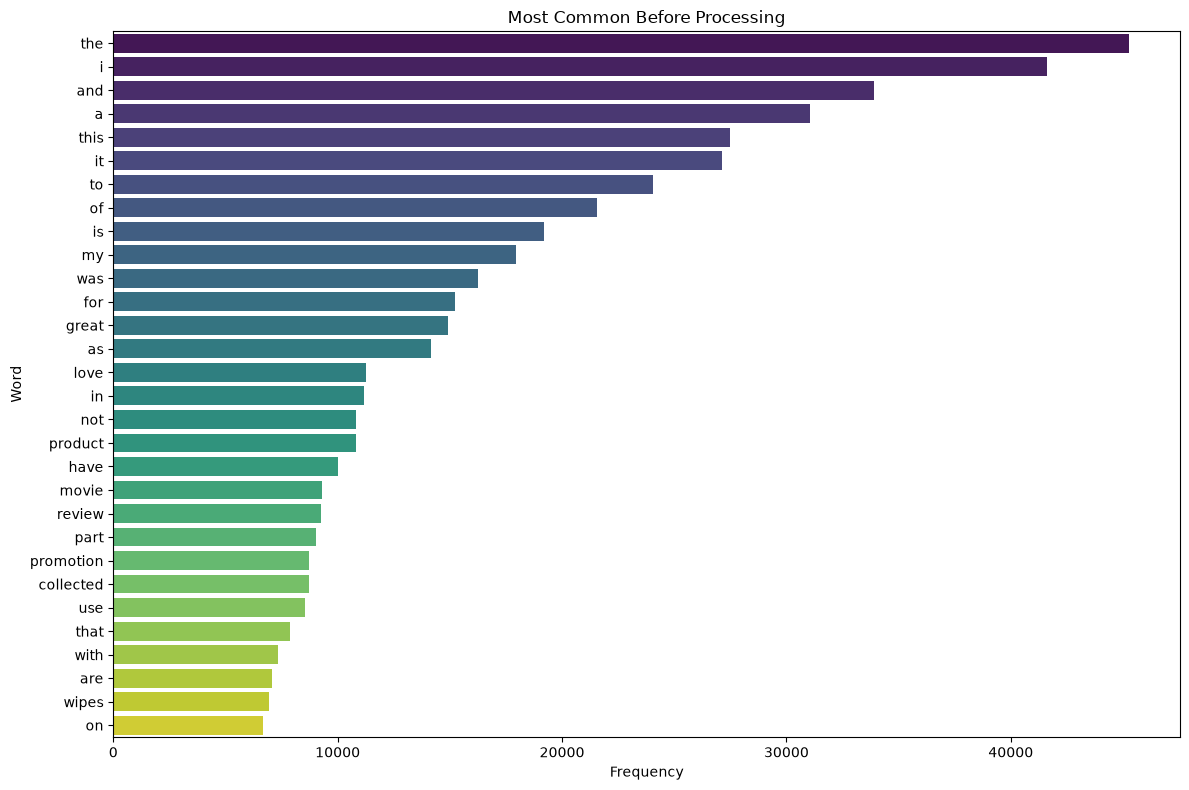

In [68]:
def review_commonwords(df,col,title):
    all_review_text = " ".join(
        df[col]
        .dropna()
        .astype("string")
    )

    # Basic tokenization without stop-word removal or stemming
    raw_words = re.findall(
        r"\b[a-zA-Z']+\b",
        all_review_text.lower()
    )

    common_words = pd.DataFrame(
        Counter(raw_words).most_common(30),
        columns=["word", "frequency"]
    )

    # display_info("",title)
    # display(common_words)

    plt.figure(figsize=(12, 8))

    sns.barplot(
        data=common_words,
        x="frequency",
        y="word",
        hue="word",
        palette="viridis",
        legend=False
    )
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.show()

review_commonwords(sentiments_df,'cleaned_review_text', 'Most Common Before Processing')


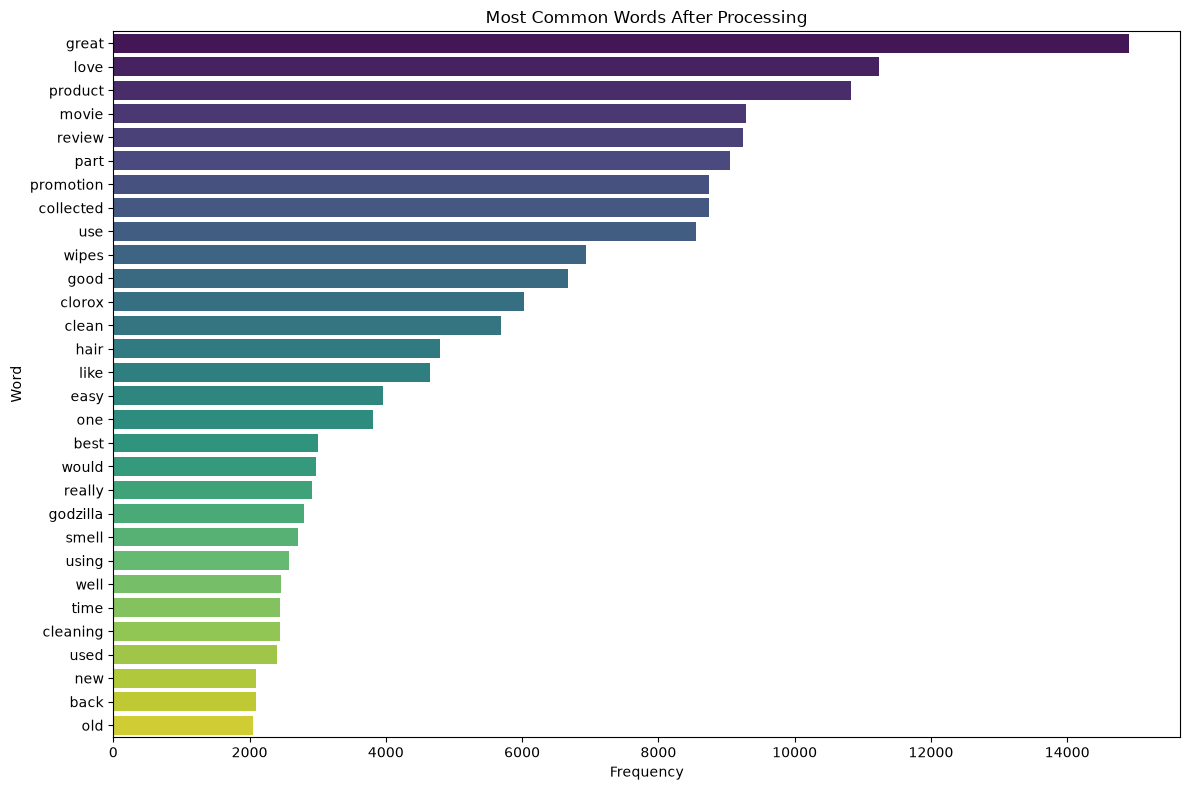

In [69]:
# Function to remove stop words from the cleaned review texts
def clean_stopwords(text):
    words = word_tokenize(text) 
    cleaned_text =  " ".join([word for word in words if word not in stopwords_set]) #removes the stopwords from the review text
    return cleaned_text

# Apply the function to clean stop words from the cleaned_review_text column of the sentiments_df dataframe
sentiments_df["cleaned_review_text"] = sentiments_df["cleaned_review_text"].apply(clean_stopwords)

# Preview the dtataframe
review_commonwords(sentiments_df,'cleaned_review_text', 'Most Common Words After Processing')


## 4. Lemmatization
- Applying lemmatization to convert words to their base form

In [70]:
# Function to lemmatize the cleaned review text
def lemmatize_text(text):
    doc = nlp(text)  # Process the text using spaCy
    lemmas = [token.lemma_ for token in doc]  # Extract lemmas
    return " ".join(lemmas)

# Apply lemmatization to the cleaned reviews
sentiments_df["lemmatized_review_text"] =  sentiments_df['cleaned_review_text'].apply(lemmatize_text)

# Preview the updated DataFrame
sentiments_df.head(2)

,id,name,reviews_full,user_sentiment,cleaned_review_text,lemmatized_review_text
0,AV13O1A8GV-KLJ3akUyj,Pink Friday: Roman Reloaded Re-Up (w/dvd),Just Awesome i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,Positive,awesome love album good hip hop side current pop sound hype listen everyday gym give rating way metaphors crazy,awesome love album good hip hop side current pop sound hype listen everyday gym give rating way metaphor crazy
1,AV14LG0R-jtxr-f38QfS,Lundberg Organic Cinnamon Toast Rice Cakes,Good Good flavor. This review was collected as part of a promotion.,Positive,good good flavor review collected part promotion,good good flavor review collect part promotion


In [71]:
#prepare the final dataframe

sentiments_df_final = sentiments_df[['id', 'name', 'lemmatized_review_text', 'user_sentiment']]

display_info(sentiments_df_final.shape,"Shape of sentiments_df_final dataframe")

sentiments_df_final.head(2)


--------------------------------------------------
Shape of sentiments_df_final dataframe: (29607, 4)
--------------------------------------------------


,id,name,lemmatized_review_text,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Pink Friday: Roman Reloaded Re-Up (w/dvd),awesome love album good hip hop side current pop sound hype listen everyday gym give rating way metaphor crazy,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg Organic Cinnamon Toast Rice Cakes,good good flavor review collect part promotion,Positive


Spelling correction was not applied because product names, brand names, slang and informal sentiment expressions could be incorrectly modified. The models will be evaluated using the original vocabulary after basic text normalization.

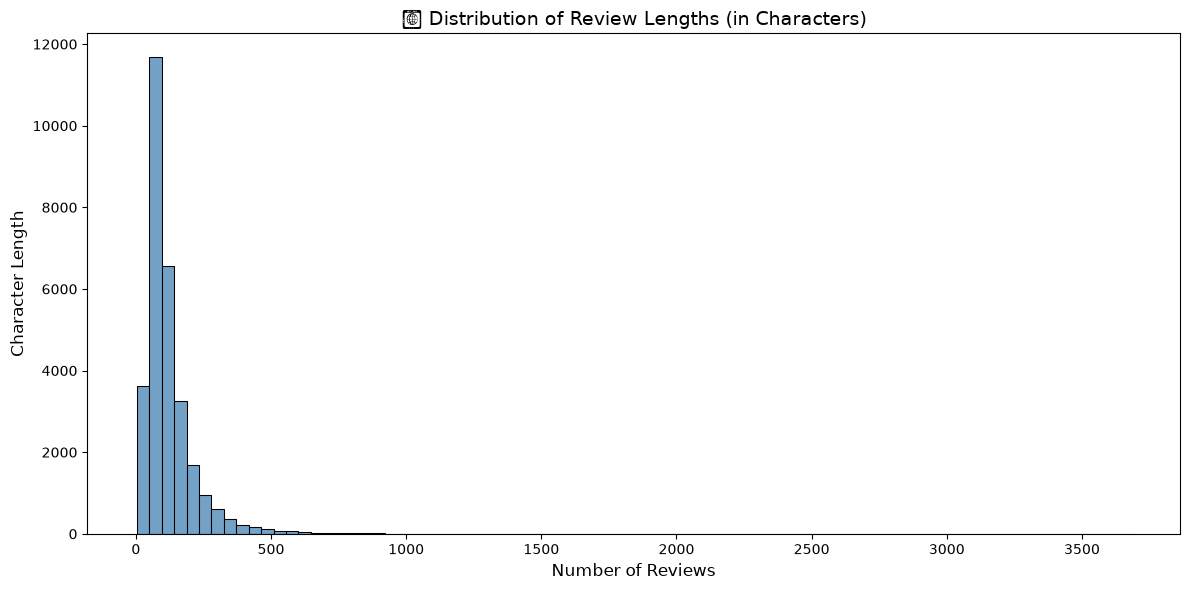

In [72]:
# Distribution plot: Character length of cleaned and lemmatized reviews
review_lengths = sentiments_df_final['lemmatized_review_text'].apply(len)

# Plot histogram horizontally using barplot logic
plt.figure(figsize=(12, 6))
sns.histplot(review_lengths, bins=80, color='steelblue', orientation='horizontal')

plt.title("📏 Distribution of Review Lengths (in Characters)", fontsize=14)
plt.xlabel("Number of Reviews", fontsize=12)
plt.ylabel("Character Length", fontsize=12)

plt.tight_layout()
plt.show()

In [73]:
# Saving the individual models in a file
save_model(sentiments_df_final, "cleansed_data")

# # Later, load them by name
# loaded_cleansed_data = load_model("cleansed_data")

Model saved: /Users/ujwalabhishek/Storage/AI Projects/Capstone/sentiment-based-recommendation-system/models/cleansed_data.pkl
Pickle protocol: 5


PosixPath('models/cleansed_data.pkl')

--------------------------------------------------
Top 50 Frequent Words in Reviews: 
--------------------------------------------------


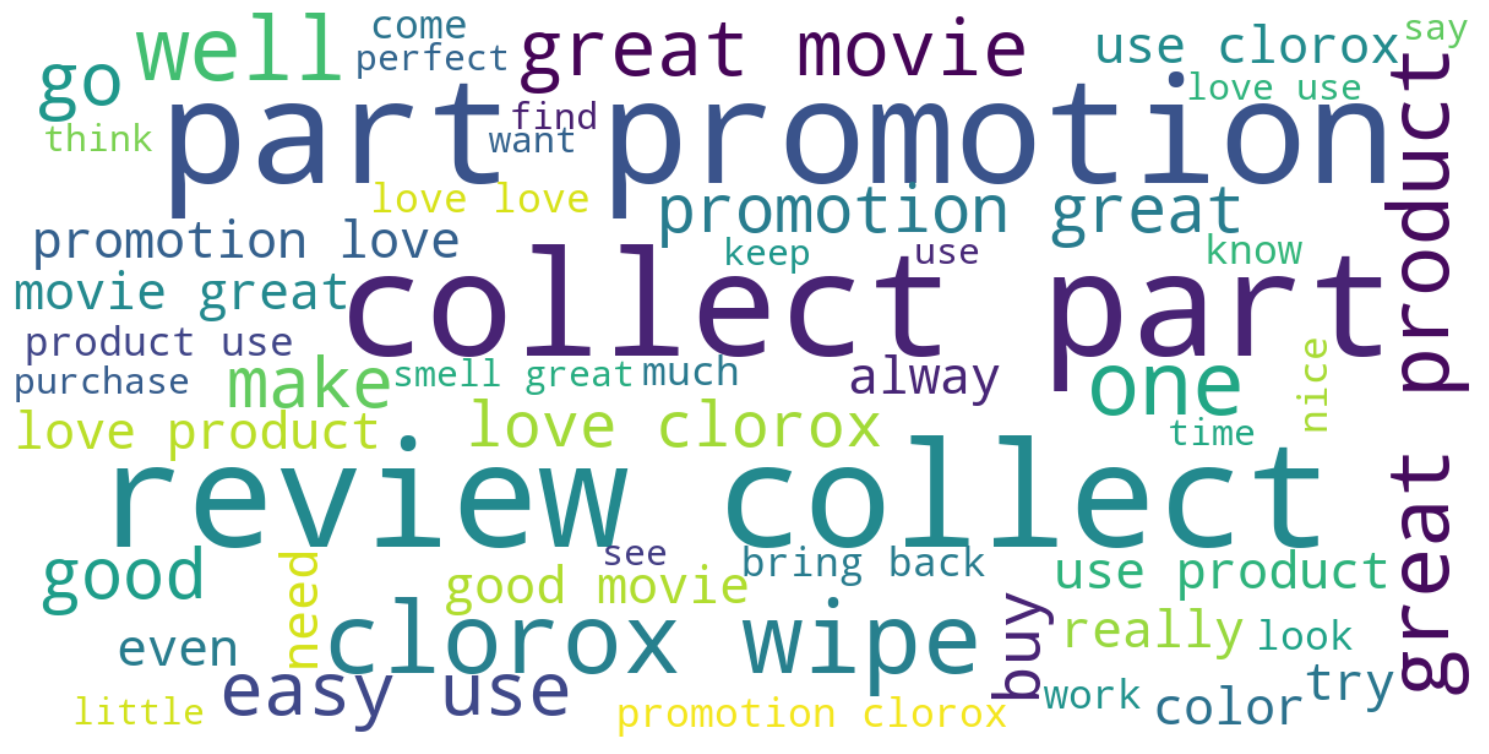

In [74]:
display_info("","Top 50 Frequent Words in Reviews")
# Combine all review texts into a single string
text_data = " ".join(sentiments_df_final['lemmatized_review_text'])

# Define stopwords
stopwords = set(STOPWORDS)

# Generate Word Cloud
wordcloud = WordCloud(
    background_color='white',
    stopwords=stopwords,
    max_words=50,
    max_font_size=40,
    scale=3,
    random_state=1
).generate(text_data)

# Plotting the Word Cloud
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Feature Extraction
In this step, we transform the cleaned textual data into numerical format using TF-IDF (Term Frequency-Inverse Document Frequency). We then split the dataset into training and testing sets to evaluate model performance. Finally, we address class imbalance to ensure the model doesn't become biased towards the dominant class, ensuring fair and accurate predictions.

### 5.1 TF-IDF Feature Extraction¶
We use TF-IDF (Term Frequency–Inverse Document Frequency) to convert text into numerical features. This method helps in identifying important words in each review by giving higher weights to rare but relevant terms, while reducing the impact of commonly occurring ones.

 - max_df helps remove very common words (often referred to as corpus-specific stop words). Setting max_df = 0.95 means:

    *"Exclude terms that appear in more than 95% of all documents, as they carry little unique information."*

 - min_df filters out rare words that occur too infrequently. Setting min_df = 5 means:

    *"Ignore terms that appear in fewer than 5 documents, as they are likely not useful for general patterns."*

**TF-IDF with word unigrams and bigrams.**
It captures individual words and phrases such as:
- excellent
- not good
- very disappointed
- highly recommend

In [75]:
#treate missing values 
# sentiments_df_final = sentiments_df_final.dropna(
#     subset=["user_sentiment"]
# ).copy()

missing_summary = pd.DataFrame({
    "Missing Count": sentiments_df_final.isna().sum(),
    "Missing Percentage": (
        sentiments_df_final.isna()
        .mean()
        .mul(100)
    )
})

display(
    missing_summary.style.format({
        "Missing Percentage": "{:.2f}%"
    })
)

,Missing Count,Missing Percentage
id,0,0.00%
name,0,0.00%
lemmatized_review_text,0,0.00%
user_sentiment,1,0.00%


In [76]:
sentiments_df_final = (
    sentiments_df_final
    .dropna()
    .reset_index(drop=True)
)

# initialize tf-idf with the custom params
tfidf_vectorizer = TfidfVectorizer(
    min_df=5,             # Ignore words that appear in fewer than 5 documents
    max_df=0.95,          # Ignore words that appear in more than 95% of documents
    stop_words='english', # Remove standard English stop words
    ngram_range=(1, 2)    # Use unigrams and bigrams
)

# fit and transform the data
tfidf_features = tfidf_vectorizer.fit_transform(sentiments_df_final['lemmatized_review_text'])

# Define the target variables
tfidf_labels = sentiments_df_final['user_sentiment']

In [77]:
# Saving the individual models in a file
save_model(tfidf_vectorizer, "tfidf_vectorizer")

# # Later, load them by name
# loaded_tfidf_vectorizer = load_model("tfidf_vectorizer")

Model saved: /Users/ujwalabhishek/Storage/AI Projects/Capstone/sentiment-based-recommendation-system/models/tfidf_vectorizer.pkl
Pickle protocol: 5


PosixPath('models/tfidf_vectorizer.pkl')

In [78]:
# top TF-IDF features and their scores 
feature_names = tfidf_vectorizer.get_feature_names_out()

mean_tfidf_scores = tfidf_features.mean(axis=0).A1

top_tfidf_features = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_tfidf_score": mean_tfidf_scores
    })
    .sort_values(
        "mean_tfidf_score",
        ascending=False
    )
    .head(10)
)
display_info("Top 10 TF-IDF Features")
display(top_tfidf_features)

--------------------------------------------------
Top 10 TF-IDF Features
--------------------------------------------------


,feature,mean_tfidf_score
5772,great,0.04
9129,movie,0.04
8272,love,0.03
10673,product,0.03
14439,use,0.03
5450,good,0.03
15365,wipe,0.03
11671,review,0.03
1771,clean,0.03
2230,collect,0.03


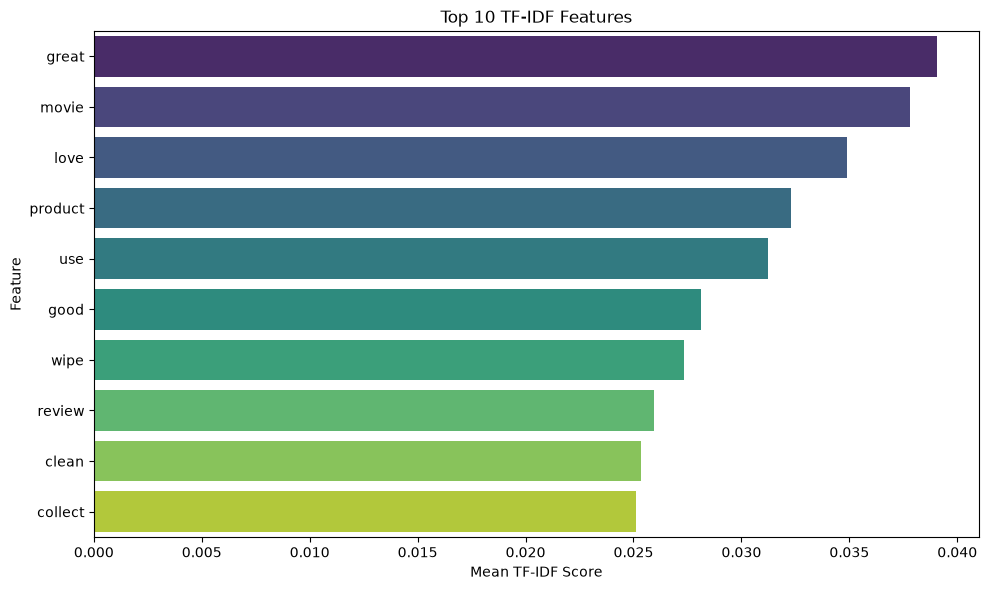

In [79]:
# visualize top TF-IDF features and their scores 
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_tfidf_features,
    x="mean_tfidf_score",
    y="feature",
    hue="feature",
    palette="viridis",
    legend=False
)

plt.title("Top 10 TF-IDF Features")
plt.xlabel("Mean TF-IDF Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 5.2. Train-Test Split

To assess the model fairly, the dataset is divided into training and testing sets. The training set is used to develop the model, while the testing set measures its performance on unseen data and determines how effectively it generalizes.

In [80]:
sentiments_df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 29606 entries, 0 to 29605
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      29606 non-null  str  
 1   name                    29606 non-null  str  
 2   lemmatized_review_text  29606 non-null  str  
 3   user_sentiment          29606 non-null  str  
dtypes: str(4)
memory usage: 925.3 KB


In [81]:
from sklearn.model_selection import train_test_split

# Retain rows containing valid text and sentiment labels
# model_df = (
#     sentiments_df_final
#     .dropna(
#         subset=[
#             "lemmatized_review_text",
#             "user_sentiment"
#         ]
#     )
#     .query("lemmatized_review_text != ''")
#     .copy()
# )

# # Input and target
# X = model_df["lemmatized_review_text"]

# y = model_df["user_sentiment"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    tfidf_features, #training variables
    tfidf_labels, #target variables
    test_size=0.25,
    random_state=42,
)

display_info(X_train.shape,"X_train Shape")
display_info(y_train.shape,"y_train Shape")
display_info(X_test.shape, "X_test Shape")
display_info(y_test.shape, "y_test Shape")



--------------------------------------------------
X_train Shape: (22204, 15942)
--------------------------------------------------
--------------------------------------------------
y_train Shape: (22204,)
--------------------------------------------------
--------------------------------------------------
X_test Shape: (7402, 15942)
--------------------------------------------------
--------------------------------------------------
y_test Shape: (7402,)
--------------------------------------------------


### 5.3 Class Imbalance
Our target variable, user_sentiment, may be imbalanced  with more positive reviews than negative ones. To prevent biased learning, we will handle this imbalance using techniques like resampling or assigning class weights to improve the model's fairness.

In [82]:
# Check the data to see if there is a class imbalance in the data
print((sentiments_df_final['user_sentiment'].value_counts(normalize=True)).map(lambda x: f"{x:.2f}%"))

sentiments_df_final.head(2)

user_sentiment
Positive    0.93%
Negative    0.07%
Name: proportion, dtype: str


,id,name,lemmatized_review_text,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Pink Friday: Roman Reloaded Re-Up (w/dvd),awesome love album good hip hop side current pop sound hype listen everyday gym give rating way metaphor crazy,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg Organic Cinnamon Toast Rice Cakes,good good flavor review collect part promotion,Positive


In [83]:
# handle class imbalance using SMOTE
from collections import Counter
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to the TF-IDF training data
smote = SMOTE(
    sampling_strategy="auto",
    random_state=42,
    k_neighbors=5
)
# Check the distribution of the target variable before SM
display_info(Counter(y_train), "Before:")

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

# Check the distribution of the target variable after SM
display_info(Counter(y_train_balanced), "After SMOTE:")

--------------------------------------------------
Before:: Counter({'Positive': 20696, 'Negative': 1508})
--------------------------------------------------
--------------------------------------------------
After SMOTE:: Counter({'Positive': 20696, 'Negative': 20696})
--------------------------------------------------


**Class Distribution After Oversampling**

After applying SMOTE-based oversampling, we can now confirm that both sentiment classes  Positive and Negative have been balanced successfully.

Previously, the dataset was highly imbalanced:

 - Positive: 93% of the total data
 - Negative: Only 7%, severely underrepresented

Now, after oversampling:

 - Positive sentiment count = 20696
 - Negative sentiment count = 20696(same as Positive)

This balance ensures that the model receives equal representation from both sentiment classes during training. It helps prevent the model from becoming biased toward the majority class (Positive), and improves its ability to detect and correctly classify Negative sentiments as well which is often the more critical class in customer feedback analysis.

**Balanced training data leads to:**

 - More reliable precision/recall across classes
 - Higher F1-score for the minority class
 - More fair and robust model performance

## 6. Model Building & Evaluation

In this section, we construct, train, and evaluate machine learning models to classify user sentiment based on processed text data.

We apply several classification algorithms and optimize them using the best practices in feature extraction and class balancing. The performance of each model is assessed using key evaluation metrics such as accuracy, precision, recall, F1 score, and ROC AUC, along with visual tools like the confusion matrix and ROC curves. This helps us compare models and select the most effective one for production or deployment.

In [84]:
# common function for model evaluation and training performance analysis
def evaluate_train_test_performance(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    positive_label="Positive",
    model_name="Model"
):
    """
    Evaluates a binary classifier with string labels like 'Positive'/'Negative'.

    • Prints a classification report (Test set).
    • Renders Confusion Matrix (Test) and ROC Curves (Train vs Test) side-by-side.
    • Displays a **centered**, **full-width** summary table of metrics (Train vs Test).
    • Metrics are shown in percentage format with two decimal places.

    Returns:
      metrics: Dictionary: {"train": {...}, "test": {...}} (values in 0-1 float scale)
    """

    def calc_metrics(y_true, y_pred, y_score=None):
        labels = list(model.classes_)
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        tn, fp = cm[0]
        fn, tp = cm[1]
        m = {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
            "Recall": recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
            "F1 Score": f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
            "Specificity": tn / (tn + fp) if (tn + fp) else 0.0
        }
        if y_score is not None:
            m["ROC AUC"] = roc_auc_score((y_true == positive_label).astype(int), y_score)
        return cm, m

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    y_train_scores = y_test_scores = None
    if hasattr(model, "predict_proba"):
        idx = list(model.classes_).index(positive_label)
        y_train_scores = model.predict_proba(X_train)[:, idx]
        y_test_scores  = model.predict_proba(X_test)[:, idx]

    cm_train, m_train = calc_metrics(y_train, y_train_pred, y_train_scores)
    cm_test,  m_test  = calc_metrics(y_test,  y_test_pred,  y_test_scores)

    # Print classification report (Test only)
    print(f"\n🧾 Classification Report — {model_name} (Test Set)\n")
    print(classification_report(y_test, y_test_pred, labels=model.classes_, zero_division=0))

    # Plot: Confusion Matrix + ROC curves in one row
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax_cm, ax_roc = axes

    sns.heatmap(
        cm_test, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=model.classes_, yticklabels=model.classes_, ax=ax_cm
    )
    ax_cm.set_title(f"Confusion Matrix\n{model_name} (Test)")
    ax_cm.set_xlabel("Predicted")
    ax_cm.set_ylabel("Actual")

    if y_train_scores is not None and y_test_scores is not None:
        fpr_tr, tpr_tr, _ = roc_curve((y_train == positive_label).astype(int), y_train_scores)
        fpr_te, tpr_te, _ = roc_curve((y_test  == positive_label).astype(int), y_test_scores)

        ax_roc.plot(fpr_tr, tpr_tr, label=f"Train AUC: {m_train['ROC AUC'] * 100:.2f} %")
        ax_roc.plot(fpr_te, tpr_te, label=f"Test AUC:  {m_test['ROC AUC'] * 100:.2f} %")
        ax_roc.plot([0, 1], [0, 1], "--", color="grey", label="Random")
        ax_roc.set_xlabel("False Positive Rate")
        ax_roc.set_ylabel("True Positive Rate")
        ax_roc.set_title(f"ROC Curve\n{model_name}")
        ax_roc.legend(loc="lower right")
    else:
        ax_roc.text(0.5, 0.5, "ROC not available", ha='center', va='center', transform=ax_roc.transAxes)
        ax_roc.set_axis_off()

    plt.tight_layout()
    plt.show()

    # Summary table (Train vs Test)
    summary_df = pd.DataFrame({"Train": m_train, "Test": m_test})
    df_pct = (summary_df * 100).round(2)  # now floats in percent

    styled = (
        df_pct.style
        .format("{:.2f} %")
        .set_caption(f"<strong>{model_name} — Summary Metrics</strong>")
        .set_table_attributes('style="margin-left:auto; margin-right:auto; width:95%;"')
        .set_table_styles([
            {"selector": "th, td", "props": [("border", "1px solid black"), ("text-align", "center")]},
            {"selector": "th", "props": [("font-weight", "bold")]},
        ])
    )
    print("\n📊 Summary Metrics (Train vs Test)\n")
    display(styled)

    return {"train": m_train, "test": m_test}

### 6.1 Logistic Regression (Binary Sentiment Classification)

Logistic Regression models the log-odds of sentiment (positive vs. negative) as a linear combination of features (like TF‑IDF scores), transformed by the sigmoid (logistic) function into probabilities between 0 and 1.

It is interpretable, fast, and robust—particularly useful for NLP applications where transparency and baseline performance matter.

In datasets with class imbalance (e.g. 93% positive vs. 7% negative), Logistic Regression can still perform well if we use either:

 - **class_weight="balanced"** to automatically adjust for imbalance, or
 - resampling techniques such as **SMOTE** or our custom oversampling function.

By tuning hyperparameters (C, penalty, solver, class_weight, etc.) and optimizing metrics like F1-score and ROC AUC, Logistic Regression often sets a strong baseline—and sometimes, a production-grade classifier—especially when combined with proper feature extraction and oversampling strategies.


🧾 Classification Report — Logistic Regression (Base) (Test Set)

              precision    recall  f1-score   support

    Negative       0.60      0.82      0.69       471
    Positive       0.99      0.96      0.97      6931

    accuracy                           0.95      7402
   macro avg       0.79      0.89      0.83      7402
weighted avg       0.96      0.95      0.96      7402



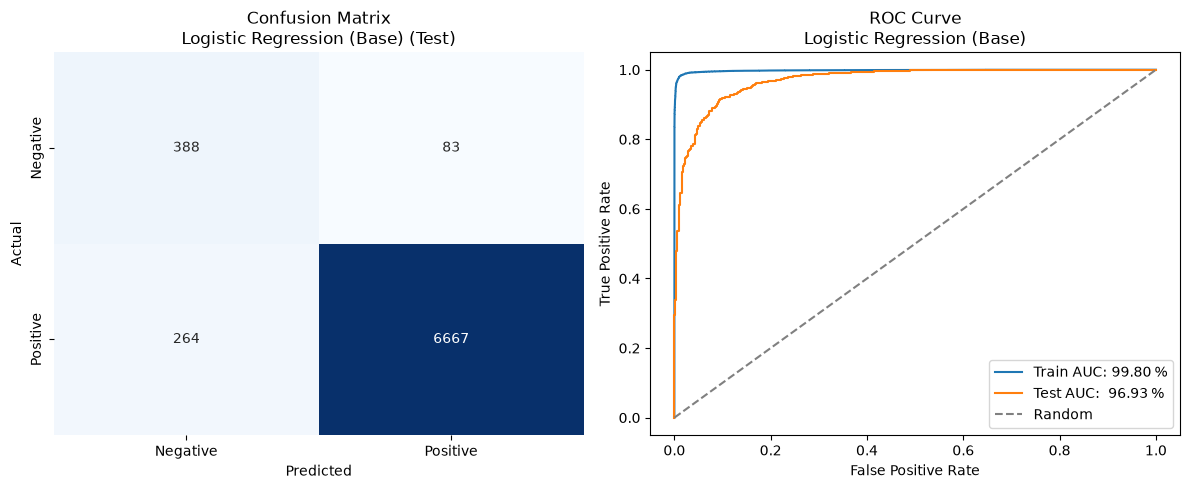


📊 Summary Metrics (Train vs Test)



,Train,Test
Accuracy,98.35 %,95.31 %
Precision,99.07 %,98.77 %
Recall,97.61 %,96.19 %
F1 Score,98.34 %,97.46 %
Specificity,99.09 %,82.38 %
ROC AUC,99.80 %,96.93 %


In [85]:
# Use class_weight='balanced' to adjust for remaining imbalance, with liblinear solver
logreg_model_base = LogisticRegression(
    class_weight='balanced',         # account for class imbalance automatically
    solver='lbfgs',              # recommended for binary tasks with L2 regularization
    max_iter=1000,                   # ensure convergence on large TF‑IDF feature sets
    random_state=42                  # ensures reproducibility
)

# Train on the oversampled training data
logreg_model_base.fit(X_train_balanced, y_train_balanced)

#Evaluate performance on the test data
metrics_1 = evaluate_train_test_performance(
    model=logreg_model_base,
    X_train=X_train_balanced, y_train=y_train_balanced,
    X_test=X_test, y_test=y_test,
    positive_label="Positive",
    model_name="Logistic Regression (Base)"
)

In [86]:
# Saving the individual models in a file
save_model(logreg_model_base, "logistic_regression_base_model")

Model saved: /Users/ujwalabhishek/Storage/AI Projects/Capstone/sentiment-based-recommendation-system/models/logistic_regression_base_model.pkl
Pickle protocol: 5


PosixPath('models/logistic_regression_base_model.pkl')

### 6.2 Logistic Regression (Fine Tune Model)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
RandomizedSearchCV completed.
Best Params: {'C': np.float64(3.142880890840109), 'class_weight': 'balanced', 'l1_ratio': 0.0, 'max_iter': 200, 'solver': 'liblinear', 'tol': 0.0001}

🧾 Classification Report — Logistic Regression (Tuned) (Test Set)

              precision    recall  f1-score   support

    Negative       0.66      0.80      0.72       471
    Positive       0.99      0.97      0.98      6931

    accuracy                           0.96      7402
   macro avg       0.82      0.89      0.85      7402
weighted avg       0.97      0.96      0.96      7402



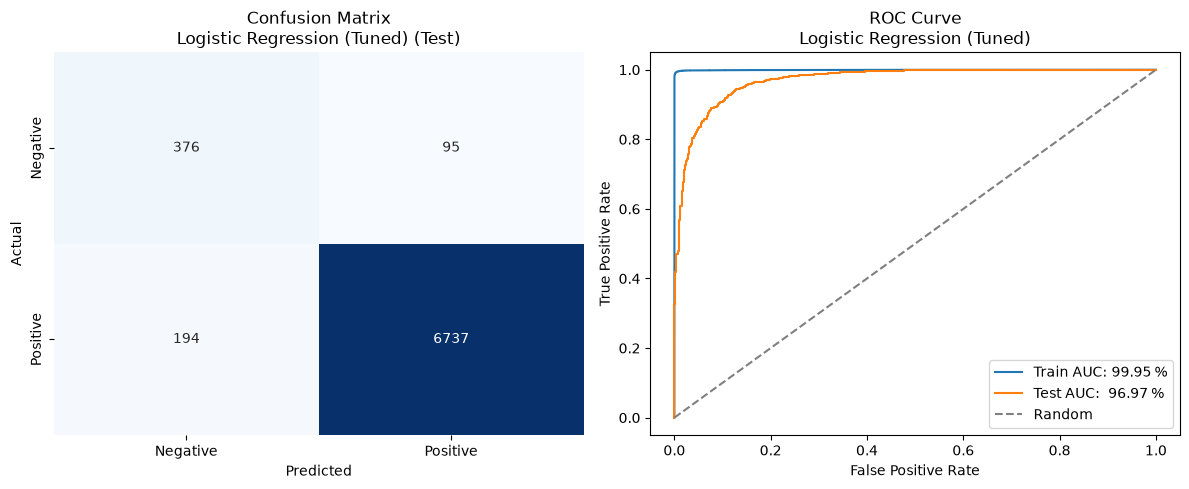


📊 Summary Metrics (Train vs Test)



,Train,Test
Accuracy,99.39 %,96.10 %
Precision,99.82 %,98.61 %
Recall,98.95 %,97.20 %
F1 Score,99.39 %,97.90 %
Specificity,99.83 %,79.83 %
ROC AUC,99.95 %,96.97 %


In [87]:
# Simplified hyperparameter space
param_space = {
    'C': loguniform(1e-2, 10),                    # Smaller range for regularization strength
    'l1_ratio': [0.0],                             # No elasticnet (avoids l1_ratio complications)
    'solver': ['liblinear'],                     # Fast & compatible with 'l2'
    'class_weight': [None, 'balanced'],          # Try both balanced and unbalanced
    'tol': [1e-4],                                # Fixed tolerance for convergence
    'max_iter': [200]                             # Lower iteration cap
}

# Stratified 3-fold CV for faster runtime
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Base Logistic Regression
base_lr = LogisticRegression(random_state=42)

# Custom F1 scorer with string label
f1_custom = make_scorer(f1_score, pos_label="Positive")

# RandomizedSearchCV setup
search = RandomizedSearchCV(
    estimator=base_lr,
    param_distributions=param_space,
    n_iter=10,                    # Reduced from 40 → 10
    scoring=f1_custom,           # Use custom scorer here,
    verbose=1,
    random_state=42,
    refit=True
)

# Fit on training data
search.fit(X_train_balanced, y_train_balanced)

print("RandomizedSearchCV completed.")
print("Best Params:", search.best_params_)

# Final model evaluation
logreg_model_finetuned = search.best_estimator_
metrics_2 = evaluate_train_test_performance(
    model=logreg_model_finetuned,
    X_train=X_train_balanced, y_train=y_train_balanced,
    X_test=X_test,       y_test=y_test,
    positive_label="Positive",
    model_name="Logistic Regression (Tuned)"
)

In [88]:
# Saving the Logistic Regression (Tuned) models in a file
save_model(logreg_model_finetuned, "logistic_regression_tuned_model")

Model saved: /Users/ujwalabhishek/Storage/AI Projects/Capstone/sentiment-based-recommendation-system/models/logistic_regression_tuned_model.pkl
Pickle protocol: 5


PosixPath('models/logistic_regression_tuned_model.pkl')

### 6.3 Random Forest Classifier (Base Model)

Random Forest is a powerful ensemble method that trains multiple decision trees on bootstrapped samples and aggregates their predictions through majority voting—this reduces overfitting while delivering strong accuracy on both noisy and imbalanced datasets.
It excels with high dimensional inputs such as TF‑IDF vectors, handles missing values natively, and produces feature importance scores that help explain model behavior making it highly interpretable for NLP pipelines.

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    3.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    6.7s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.7s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.7s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished



🧾 Classification Report — Random Forest (Base Model) (Test Set)

              precision    recall  f1-score   support

    Negative       0.80      0.63      0.71       471
    Positive       0.98      0.99      0.98      6931

    accuracy                           0.97      7402
   macro avg       0.89      0.81      0.84      7402
weighted avg       0.96      0.97      0.96      7402



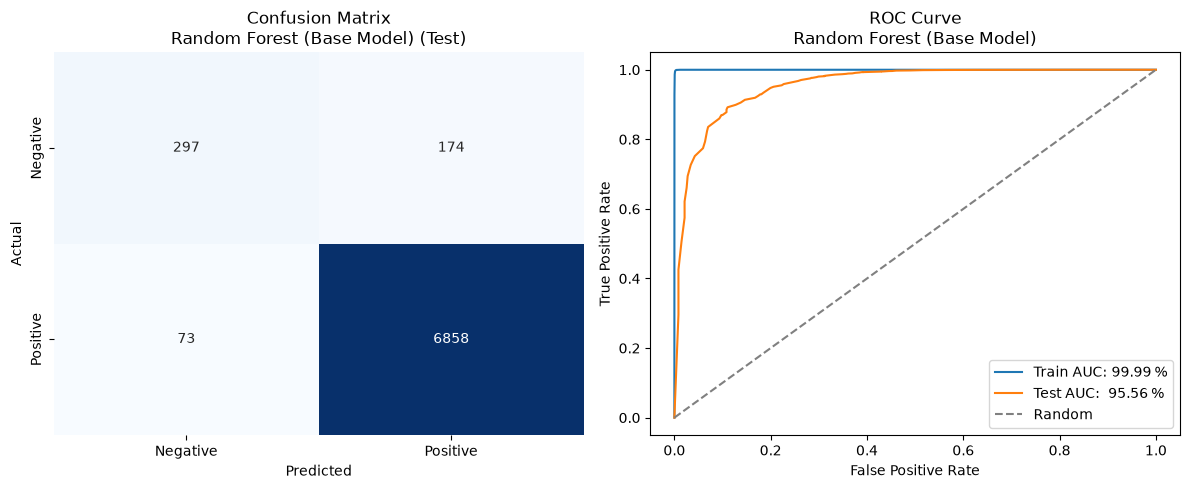


📊 Summary Metrics (Train vs Test)



,Train,Test
Accuracy,99.79 %,96.66 %
Precision,99.77 %,97.53 %
Recall,99.82 %,98.95 %
F1 Score,99.79 %,98.23 %
Specificity,99.77 %,63.06 %
ROC AUC,99.99 %,95.56 %


In [89]:
# Split your (already balanced) training data into train/validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_balanced, y_train_balanced, test_size=0.2, 
    stratify=y_train_balanced, random_state=42
)

# Initialize a base RandomForest classifier with class weight to handle imbalance
rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',  # Adjusts sample weights inversely to class frequency.
    verbose=1,
    n_jobs=1
)

# Train the model
rf_base.fit(X_train_split, y_train_split)

# Evaluate performance on the test data
metrics_3 = evaluate_train_test_performance(
    model=rf_base,
    X_train=X_train_balanced, y_train=y_train_balanced,
    X_test=X_test, y_test=y_test,
    positive_label="Positive",
    model_name="Random Forest (Base Model)"
)

In [90]:
# Saving the Random Forest (Base Model) in a file
save_model(rf_base, "random_forest_base_model")

Model saved: /Users/ujwalabhishek/Storage/AI Projects/Capstone/sentiment-based-recommendation-system/models/random_forest_base_model.pkl
Pickle protocol: 5


PosixPath('models/random_forest_base_model.pkl')

### 6.4 Random Forest Classifier (Fine Tuning Model)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 4139
max_resources_: 33113
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 8
n_resources: 4139
Fitting 3 folds for each of 8 candidates, totalling 24 fits
----------
iter: 1
n_candidates: 4
n_resources: 8278
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 2
n_candidates: 2
n_resources: 16556
Fitting 3 folds for each of 2 candidates, totalling 6 fits
----------
iter: 3
n_candidates: 1
n_resources: 33112
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best RF Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}

🧾 Classification Report — Random Forest (Tuned) (Test Set)

              precision    recall  f1-score   support

    Negative       0.99      0.99      0.99      4140
    Positive       0.99      0.99      0.99      4139

    accuracy                           0.99      8279
   macro avg    

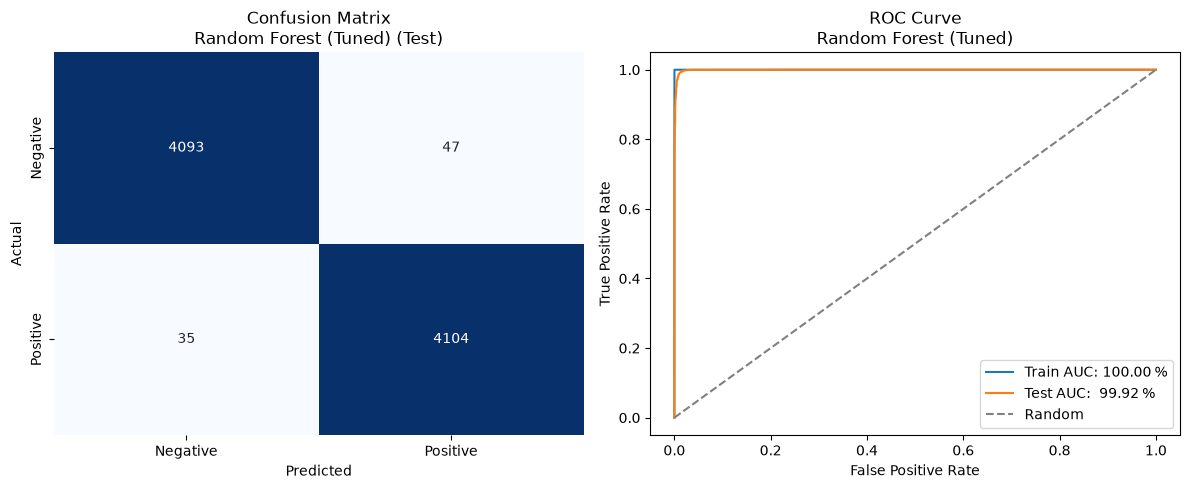


📊 Summary Metrics (Train vs Test)



,Train,Test
Accuracy,99.99 %,99.01 %
Precision,100.00 %,98.87 %
Recall,99.98 %,99.15 %
F1 Score,99.99 %,99.01 %
Specificity,100.00 %,98.86 %
ROC AUC,100.00 %,99.92 %


In [91]:

# Hyperparameter Tuning: Random Forest Classifier (Balanced)

# Optional: Custom scorer for string labels
f1_custom = make_scorer(f1_score, pos_label="Positive")

# Step 1: Stratified split for training/validation
X_trn, X_val, y_trn, y_val = train_test_split(
    X_train_balanced, y_train_balanced,
    test_size=0.2,
    stratify=y_train_balanced,
    random_state=42,
)

# Step 2: Base Random Forest with class weight balancing
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=1,
    class_weight="balanced",
)

# Step 3: Reduced parameter grid for speed
param_grid = {
    "n_estimators":     [100, 200],       # Reduced from 3 to 2 options
    "max_depth":        [None, 10],       # Removed 30
    "min_samples_leaf": [1, 2],           # Removed 5
    "max_features":     ["sqrt"],         # Removed 'log2'
}

# Step 4: Halving Grid Search (efficient search strategy)
halving_search = HalvingGridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring=f1_custom,      # Use custom F1 scorer
    cv=3,                   # Reduced cross-validation folds to 3
    factor=2,               # Controls speed vs. thoroughness (default=3)
    resource="n_samples",
    verbose=1,
    random_state=42,
    n_jobs=1
)

# Step 5: Fit on training split
halving_search.fit(X_trn, y_trn)

# Step 6: Best estimator from tuning
best_rf = halving_search.best_estimator_
print("Best RF Params:", halving_search.best_params_)

# Step 7: Evaluate on train and validation
metrics_4 = evaluate_train_test_performance(
    model=best_rf,
    X_train=X_trn, y_train=y_trn,
    X_test=X_val,   y_test=y_val,
    positive_label="Positive",
    model_name="Random Forest (Tuned)"
)

In [92]:
# Saving the Random Forest (Tuned) models in a file
save_model(best_rf, "random_forest_tuned_model")

Model saved: /Users/ujwalabhishek/Storage/AI Projects/Capstone/sentiment-based-recommendation-system/models/random_forest_tuned_model.pkl
Pickle protocol: 5


PosixPath('models/random_forest_tuned_model.pkl')

### 6.5 XGBoost Classifier (Base Model)

XGBoost (eXtreme Gradient Boosting) is a scalable, open‑source gradient boosting library that delivers exceptional performance on structured, high-dimensional data—all while maintaining efficient memory footprint and fast training through parallel and cache-optimized algorithms. It constructs trees sequentially, where each new tree corrects residual errors of its predecessors, and incorporates regularization (L1/L2) plus tree pruning to minimize overfitting—offering an accuracy and generalization advantage over models like Random Forest in many applications.

To tackle extreme class imbalance (such as Positive 93% vs Negative 7% in sentiment data), XGBoost supports the scale_pos_weight parameter (for binary classification) or sample_weight for multiclass cases. This allows the model to internally re‑weigh minority samples, improving recall and F1‑score for the underrepresented class without needing external oversampling.

Together, these capabilities make XGBoost a strong candidate for sentiment-based product recommendation pipelines, especially when achieving robust performance on imbalanced datasets is a key priority.


🧾 Classification Report — XGBoost (Base Model) (Test Set)

              precision    recall  f1-score   support

           0       0.61      0.67      0.64       471
           1       0.98      0.97      0.97      6931

    accuracy                           0.95      7402
   macro avg       0.79      0.82      0.81      7402
weighted avg       0.95      0.95      0.95      7402



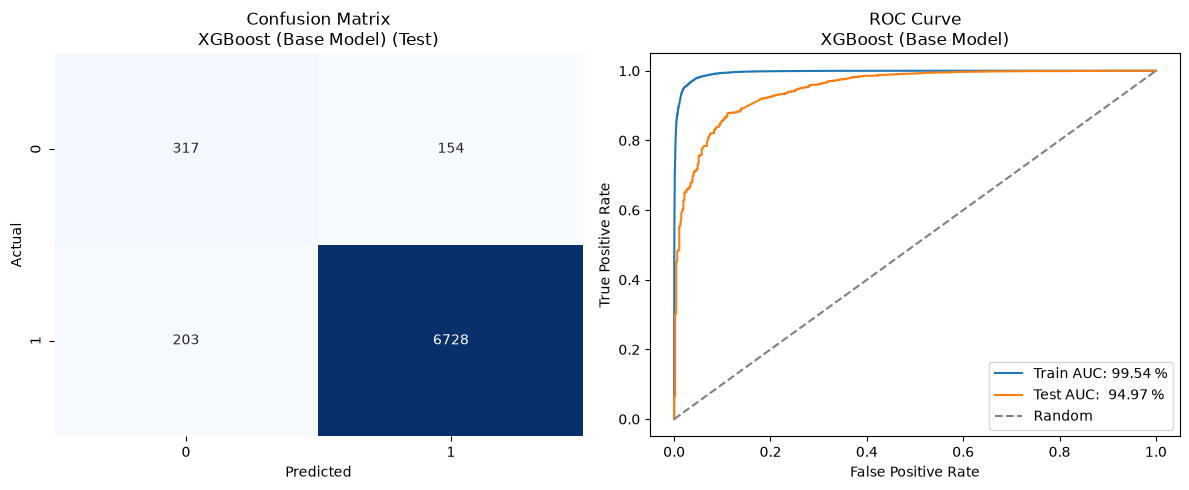


📊 Summary Metrics (Train vs Test)



,Train,Test
Accuracy,96.61 %,95.18 %
Precision,95.45 %,97.76 %
Recall,97.87 %,97.07 %
F1 Score,96.65 %,97.42 %
Specificity,95.34 %,67.30 %
ROC AUC,99.54 %,94.97 %


In [93]:
# XGBoost Classifier (Base Model)
# Encode labels into integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_balanced)
y_test_enc  = le.transform(y_test)

# Compute class imbalance weight
neg = np.sum(y_train_enc == 0)
pos = np.sum(y_train_enc == 1)
scale_pw = neg / pos if pos else 1.0

# Instantiate XGBClassifier with best-found params
xgb_final = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    tree_method="hist",             # fast histogram-based method
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pw,
    learning_rate=0.2,
    max_depth=4,
    n_estimators=100,
    n_jobs=1,
    random_state=42
)

# Train on full balanced training data
xgb_final.fit(X_train_balanced, y_train_enc)

# Evaluate final model
metrics_5 = evaluate_train_test_performance(
    model=xgb_final,
    X_train=X_train_balanced, y_train=y_train_enc,
    X_test=X_test, y_test=y_test_enc,
    positive_label=1,
    model_name="XGBoost (Base Model)"
)


In [94]:
# Saving the XGBoost (Base Model) in a file
save_model(xgb_final, "xgboost_base_model")

Model saved: /Users/ujwalabhishek/Storage/AI Projects/Capstone/sentiment-based-recommendation-system/models/xgboost_base_model.pkl
Pickle protocol: 5


PosixPath('models/xgboost_base_model.pkl')

### 6.6 XGBoost Classifier (Fine Tune Model)


Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

🧾 Classification Report — XGBoost (Fast Tuned) (Test Set)

              precision    recall  f1-score   support

           0       0.95      0.90      0.93      4140
           1       0.91      0.96      0.93      4139

    accuracy                           0.93      8279
   macro avg       0.93      0.93      0.93      8279
weighted avg       0.93      0.93      0.93      8279



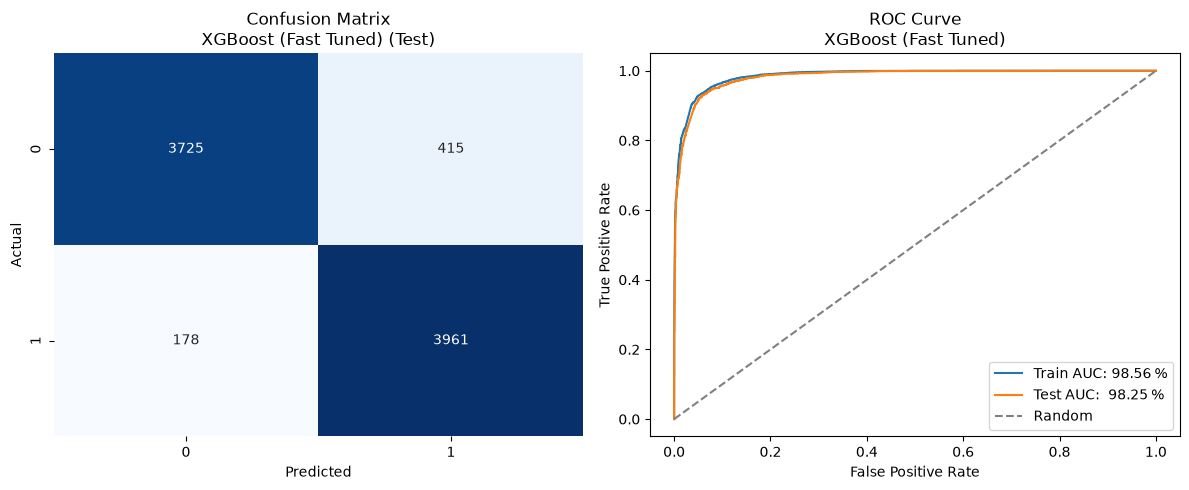


📊 Summary Metrics (Train vs Test)



,Train,Test
Accuracy,93.40 %,92.84 %
Precision,91.03 %,90.52 %
Recall,96.29 %,95.70 %
F1 Score,93.59 %,93.04 %
Specificity,90.51 %,89.98 %
ROC AUC,98.56 %,98.25 %


In [95]:
# XGBoost Hyperparameter Tuning — Fast Mode

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_balanced)
y_test_enc  = le.transform(y_test)

# Stratified train/validation split
X_trn, X_val, y_trn, y_val = train_test_split(
    X_train_balanced, y_train_enc, test_size=0.2, stratify=y_train_enc, random_state=42
)

# Compute class imbalance weight
neg = np.sum(y_trn == 0)
pos = np.sum(y_trn == 1)
scale_pw = neg / pos if pos else 1.0

# Base model with fewer trees
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",       # Fast histogram algorithm
    subsample=0.9,             # Use more data per tree for fewer trees
    colsample_bytree=0.9,      
    scale_pos_weight=scale_pw,
    n_estimators=100,          # Fewer trees for faster training
    n_jobs=-1,                 # Use all CPU cores
    random_state=42
)

# Minimal parameter grid — just 1 or 2 values for each
param_grid = {
    "max_depth": [3],           # shallower trees train faster
    "learning_rate": [0.1],     # stable and common choice
    "n_estimators": [50, 100]   # small # of trees for quick run
}

# F1 scorer
f1_scorer = make_scorer(f1_score, pos_label=1)

# Use two stratified folds for a fast parameter search.
search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=2,                # minimal CV folds
    verbose=1,
    n_jobs=1
)

# Do not pass early_stopping_rounds to fit(): XGBoost 3.x expects it
# in the estimator constructor. It is unnecessary here because
# n_estimators is already being selected by cross-validation.
search.fit(X_trn, y_trn)

best_xgb = search.best_estimator_
print("Best Params:", search.best_params_)

# Evaluate
metrics_6 = evaluate_train_test_performance(
    model=best_xgb,
    X_train=X_trn, y_train=y_trn,
    X_test=X_val,   y_test=y_val,
    positive_label=1,
    model_name="XGBoost (Fast Tuned)"
)

In [96]:
model_results = {
    "Logistic Regression (Base)": metrics_1,
    "Logistic Regression (Tuned)": metrics_2,
    "Random Forest (Base)": metrics_3,
    "Random Forest (Tuned)": metrics_4,
    "XGBoost Classifier (Base)": metrics_5,
    "XGBoost Classifier (Tuned)": metrics_6
}

performance_rows = []

for model_name, results in model_results.items():
    for dataset in ["train", "test"]:
        metrics = results[dataset]

        performance_rows.append({
            # Show model name only on the first row
            "Model": model_name if dataset == "train" else "",
            "Dataset": dataset.title(),
            "Accuracy": metrics["Accuracy"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "F1 Score": metrics["F1 Score"],
            "Specificity": metrics["Specificity"],
            "ROC AUC": metrics.get("ROC AUC", np.nan)
        })

model_performance_table = pd.DataFrame(
    performance_rows
)

percentage_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "Specificity",
    "ROC AUC"
]

styled_performance_table = (
    model_performance_table.style
    .hide(axis="index")
    .format({
        column: "{:.2%}"
        for column in percentage_columns
    })
    .set_properties(
        subset=["Model"],
        **{
            "font-weight": "bold",
            "text-align": "left"
        }
    )
    .set_properties(
        subset=["Dataset"],
        **{"text-align": "left"}
    )
    .set_properties(
        subset=percentage_columns,
        **{"text-align": "center"}
    )
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("width", "100%")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#f2f3f5"),
                ("border", "1px solid #d9dde3"),
                ("padding", "6px"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #d9dde3"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#f7f8fa")
            ]
        }
    ])
)
display_info("Summary Of Model Performance")
display(styled_performance_table)

--------------------------------------------------
Summary Of Model Performance
--------------------------------------------------


Model,Dataset,Accuracy,Precision,Recall,F1 Score,Specificity,ROC AUC
Logistic Regression (Base),Train,98.35%,99.07%,97.61%,98.34%,99.09%,99.80%
,Test,95.31%,98.77%,96.19%,97.46%,82.38%,96.93%
Logistic Regression (Tuned),Train,99.39%,99.82%,98.95%,99.39%,99.83%,99.95%
,Test,96.10%,98.61%,97.20%,97.90%,79.83%,96.97%
Random Forest (Base),Train,99.79%,99.77%,99.82%,99.79%,99.77%,99.99%
,Test,96.66%,97.53%,98.95%,98.23%,63.06%,95.56%
Random Forest (Tuned),Train,99.99%,100.00%,99.98%,99.99%,100.00%,100.00%
,Test,99.01%,98.87%,99.15%,99.01%,98.86%,99.92%
XGBoost Classifier (Base),Train,96.61%,95.45%,97.87%,96.65%,95.34%,99.54%
,Test,95.18%,97.76%,97.07%,97.42%,67.30%,94.97%


#### ! Observations & Conclusions:

 - **Tuned Random Forest outperforms** all models with exceptionally **high accuracy, precision, recall, and ROC AUC**, showing excellent generalization.
 - **Base XGBoost** with best params (without tuning) **fails drastically** on the test set, suggesting possible label leakage or overfitting issues in default settings.
 - **Logistic Regression (Tuned)** delivers **robust performance with high precision and recall** — a solid baseline with simplicity.
 - **XGBoost (Quick-Tuned)** performs significantly better than its base counterpart and is competitive with other models in test performance.
 - Specificity in **Base Random Forest** is relatively low on the test set, indicating potential overfitting or class imbalance issues.

### 6.7 Final Recommendation
Based on the test performance:

- **Best Overall Model:** Random Forest (Tuned) - Ideal for deployment
- **Best Lightweight Model:** Logistic Regression (Tuned) - Great balance of performance and simplicity
- **Best XGBoost Variant:** XGBoost (Quick-Tuned) - Good for ensemble stacking or interpretability

In [97]:
# Saving the random_forest_tuned model in a file
save_model(best_rf, "top_sentiment_classifier_model")

Model saved: /Users/ujwalabhishek/Storage/AI Projects/Capstone/sentiment-based-recommendation-system/models/top_sentiment_classifier_model.pkl
Pickle protocol: 5


PosixPath('models/top_sentiment_classifier_model.pkl')

## 7. Building a Recommendation System

We will be building two types of recommendation systems to understand which one performs better for our use case:

1. User-Based Recommendation System: Recommends products based on similar users' preferences.

2. Item-Based Recommendation System: Recommends products based on similarities between items themselves.

Once both models are built, we’ll analyze their performance and select the one that best suits our scenario.

After identifying the best-performing model, we’ll move on to the core task:
Recommending the top 20 products that a user is most likely to purchase based on their past ratings.

In [98]:
# Fetching the original dataframe from the CSV file.
display_info(reviews_df.shape, "Shape")

reviews_df.head(3)

--------------------------------------------------
Shape: (30000, 15)
--------------------------------------------------


,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Movie Bundles & Collections,CDs & Vinyl,Rap & Hip-Hop,Bass,Music on CD or Vinyl,Rap,Hip-Hop,Mainstream Rap,Pop Rap",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,Just Awesome,Los Angeles,NaN,joshua,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part of a promotion.,Good,NaN,NaN,dorothy w,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,Positive


In [99]:
# We need only the below columns for building a recommendation system
recommendation_df = reviews_df[["id", "name", "reviews_rating", "reviews_username"]]

# Fetching the updated dataframe.
display_info(recommendation_df.shape, "Shape")

recommendation_df.head(3)

--------------------------------------------------
Shape: (30000, 4)
--------------------------------------------------


,id,name,reviews_rating,reviews_username
0,AV13O1A8GV-KLJ3akUyj,Pink Friday: Roman Reloaded Re-Up (w/dvd),5,joshua
1,AV14LG0R-jtxr-f38QfS,Lundberg Organic Cinnamon Toast Rice Cakes,5,dorothy w
2,AV14LG0R-jtxr-f38QfS,Lundberg Organic Cinnamon Toast Rice Cakes,5,dorothy w


### 8.1 Handling NULL Values

Missing or NULL values can introduce bias or reduce the accuracy of our model if not handled properly. Before moving ahead with data preprocessing or model building, it's essential to understand the extent and distribution of missing data in the dataset.

This step helps in deciding whether to drop, impute, or flag missing values based on the context of the problem.

We'll start by identifying the number and percentage of NULL values in each column.

In [100]:
missing_summary = get_missing_summary(recommendation_df)

display_info("Missing Values Summary", "Recommendation dataframe")
display(
    missing_summary.style.format({
        "Missing Percentage": "{:.2f}%"
    })
)

--------------------------------------------------
Recommendation dataframe: Missing Values Summary
--------------------------------------------------


,Missing Count,Missing Percentage,Missing Level
reviews_username,63,0.21%,Low
id,0,0.00%,No
name,0,0.00%,No
reviews_rating,0,0.00%,No


In [101]:
# Removing the rows where reviews_username is NULL
recommendation_df = recommendation_df[~ recommendation_df.reviews_username.isna() ]

display_info(recommendation_df.shape, "Shape")

--------------------------------------------------
Shape: (29937, 4)
--------------------------------------------------


In [102]:
# Check missing 
missing_summary = get_missing_summary(recommendation_df)

display_info("Missing Values Summary", "Recommendation dataframe after cleaning")
display(
    missing_summary.style.format({
        "Missing Percentage": "{:.2f}%"
    })
)

--------------------------------------------------
Recommendation dataframe after cleaning: Missing Values Summary
--------------------------------------------------


,Missing Count,Missing Percentage,Missing Level
id,0,0.00%,No
name,0,0.00%,No
reviews_rating,0,0.00%,No
reviews_username,0,0.00%,No


### 8.2 Train, Test Split

Splitting the dataset into training and testing sets is a critical step to evaluate the model’s ability to generalize. The training set is used to fit the model, while the test set assesses its performance on unseen data.



In [103]:
train, test = train_test_split(recommendation_df, test_size=0.30, random_state=42)

display_info(train.shape, "Shape for Training Data")
display_info(test.shape, "Shape for Test Data")

--------------------------------------------------
Shape for Training Data: (20955, 4)
--------------------------------------------------
--------------------------------------------------
Shape for Test Data: (8982, 4)
--------------------------------------------------


In [104]:
# Pivot the train ratings' dataset into matrix format in which columns are Products and the rows are usernames.
df_pivot = train.pivot_table(
    index='reviews_username',
    columns='id',
    values='reviews_rating'
).fillna(0)

df_pivot.head(3)

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1YnUMYglJLPUi8IJpK,AV1Ynb3bglJLPUi8IJxJ,AV1YneDPglJLPUi8IJyQ,AV1YpiJvvKc47QAVguxy,AV1YqAaMGV-KLJ3adiDj,AV1Ys0kTvKc47QAVgx1C,AV1YtGjdglJLPUi8IOfJ,AV1ZSp2uglJLPUi8IQFy,AV1ZT7GLglJLPUi8IQLI,AV1ZVIgy-jtxr-f31W9N,AV1d76w7vKc47QAVhCqn,AV1h6Gu0glJLPUi8IjA_,AV1h6gSl-jtxr-f31p40,AV1l8zRZvKc47QAVhnAv,AV2AvGnjGV-KLJ3alTQH,...,AVpfluP1ilAPnD_xejxO,AVpfm8yiLJeJML43AYyu,AVpfmVnVLJeJML43AMqC,AVpfmjXGLJeJML43AQ5_,AVpfnRuSilAPnD_xfB8l,AVpfnS4eLJeJML43AfZe,AVpfnUcwLJeJML43Af2U,AVpfnjBILJeJML43AkO3,AVpfoSS51cnluZ0-oVH9,AVpfov9TLJeJML43A7B0,AVpfozgyilAPnD_xfe0r,AVpfpM2yilAPnD_xfmDG,AVpfpoUCLJeJML43BLXv,AVpfqW4WilAPnD_xf7a_,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00sab00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
01impala,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
02dakota,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 8.3 Creating Dummy Train & Test Datasets

To help our recommendation system learn and test better, we make two special copies of the rating data:

- **Dummy Train:**
This is like hiding the user's favorite movies from the system so it can try to guess them!

  - If a movie is not rated by the user mark as 1 (we want to predict these)
  - If a movie is already rated mark as 0 (no need to predict)

- **Dummy Test:**
This is used to check how smart our system is by testing only on movies the user has already rated.

  - If a movie is rated mark as 1 (we'll test the prediction here)
  - If a movie is not rated mark as 0 (ignore for testing)
  - It’s like training a friend to guess your favorite movies by hiding them first — and then checking if they got them right! 

In [105]:
# Copy the train dataset into dummy_train
dummy_train = train.copy()

# The products not rated by user is marked as 1 for prediction. 
dummy_train['reviews_rating'] = dummy_train['reviews_rating'].apply(lambda x: 0 if x>=1 else 1)

dummy_train.head(3)

,id,name,reviews_rating,reviews_username
962,AV1YGDqsGV-KLJ3adc-O,Windex Original Glass Cleaner Refill 67.6oz (2 Liter),0,brittney w
10463,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,0,cjshrad
25385,AVpfPaoqLJeJML435Xk9,Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,0,zman69


In [106]:
# Convert the dummy train dataset into matrix format
dummy_train = dummy_train.pivot_table(
    index='reviews_username',
    columns='id',
    values='reviews_rating'
).fillna(1)

dummy_train.head(3)

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1YnUMYglJLPUi8IJpK,AV1Ynb3bglJLPUi8IJxJ,AV1YneDPglJLPUi8IJyQ,AV1YpiJvvKc47QAVguxy,AV1YqAaMGV-KLJ3adiDj,AV1Ys0kTvKc47QAVgx1C,AV1YtGjdglJLPUi8IOfJ,AV1ZSp2uglJLPUi8IQFy,AV1ZT7GLglJLPUi8IQLI,AV1ZVIgy-jtxr-f31W9N,AV1d76w7vKc47QAVhCqn,AV1h6Gu0glJLPUi8IjA_,AV1h6gSl-jtxr-f31p40,AV1l8zRZvKc47QAVhnAv,AV2AvGnjGV-KLJ3alTQH,...,AVpfluP1ilAPnD_xejxO,AVpfm8yiLJeJML43AYyu,AVpfmVnVLJeJML43AMqC,AVpfmjXGLJeJML43AQ5_,AVpfnRuSilAPnD_xfB8l,AVpfnS4eLJeJML43AfZe,AVpfnUcwLJeJML43Af2U,AVpfnjBILJeJML43AkO3,AVpfoSS51cnluZ0-oVH9,AVpfov9TLJeJML43A7B0,AVpfozgyilAPnD_xfe0r,AVpfpM2yilAPnD_xfmDG,AVpfpoUCLJeJML43BLXv,AVpfqW4WilAPnD_xf7a_,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00sab00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
01impala,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
02dakota,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0




### 8.4. Cosine Similarity vs Adjusted Cosine

**Cosine Similarity**

*Means:* Cosine Similarity is a measurement that quantifies the similarity between two vectors.

*Example:* Imagine two kids rating the same set of chocolates. If both like the same ones and dislike the same ones, their ratings pattern will point in the same direction. Cosine Similarity is like checking how similar their tastes are by comparing the direction of their ratings, not how high or low the ratings are.

**Adjusted Cosine Similarity**

*Means:* Adjusted cosine similarity is a modified version of vector-based similarity where we incorporate the fact that different users have different ratings schemes. In other words, some users might rate items highly in general, and others might give items lower ratings as a preference. To handle this nature from rating given by user , we subtract average ratings for each user from each user's rating for different products.

*Example:* Now, some kids always give high scores, and some are strict and give low scores—even if they like the chocolate! So, Adjusted Cosine takes each kid's style of rating into account. Before comparing their ratings, we first subtract their own average score from all their ratings. This way, we compare what they really feel about a chocolate—not just how generous or strict they are.

### 8.5. User Similarity Matrix (Using Adjusted Cosine)

Imagine a group of friends who rate different chocolates. But not everyone has tasted every chocolate, so some ratings are missing (these are like NaN values).

Instead of ignoring these missing ratings, we:

 - Only look at the chocolates each friend has tasted and rated.

Then we:

 - Calculate how much each friend liked the chocolates, compared to their own usual taste (average rating).
 - Compare this adjusted liking with other friends.


This helps us figure out which users have similar chocolate tastes, even if they rate things differently (some rate higher, some lower). 

So, it's like saying:

"Even though you and I rate differently, do we like or dislike the same chocolates compared to our usual taste?"

**Handling Missing Ratings Smartly**

 - Here, we are not removing the missing ratings (NaN values).

 - Instead, we calculate the average rating only from the products that the user has actually rated.

 - This helps us compare users more fairly, based on what they’ve really experienced and rated.

In [107]:
# Pivot the train ratings' dataset into matrix format in which columns are Products and the rows are usernames.
df_pivot = train.pivot_table(
    index='reviews_username',
    columns='id',
    values='reviews_rating'
)

df_pivot.head(3)

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1YnUMYglJLPUi8IJpK,AV1Ynb3bglJLPUi8IJxJ,AV1YneDPglJLPUi8IJyQ,AV1YpiJvvKc47QAVguxy,AV1YqAaMGV-KLJ3adiDj,AV1Ys0kTvKc47QAVgx1C,AV1YtGjdglJLPUi8IOfJ,AV1ZSp2uglJLPUi8IQFy,AV1ZT7GLglJLPUi8IQLI,AV1ZVIgy-jtxr-f31W9N,AV1d76w7vKc47QAVhCqn,AV1h6Gu0glJLPUi8IjA_,AV1h6gSl-jtxr-f31p40,AV1l8zRZvKc47QAVhnAv,AV2AvGnjGV-KLJ3alTQH,...,AVpfluP1ilAPnD_xejxO,AVpfm8yiLJeJML43AYyu,AVpfmVnVLJeJML43AMqC,AVpfmjXGLJeJML43AQ5_,AVpfnRuSilAPnD_xfB8l,AVpfnS4eLJeJML43AfZe,AVpfnUcwLJeJML43Af2U,AVpfnjBILJeJML43AkO3,AVpfoSS51cnluZ0-oVH9,AVpfov9TLJeJML43A7B0,AVpfozgyilAPnD_xfe0r,AVpfpM2yilAPnD_xfmDG,AVpfpoUCLJeJML43BLXv,AVpfqW4WilAPnD_xf7a_,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00sab00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
01impala,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
02dakota,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [108]:
# Below code is used to find all users who have rated a specific product (with ID 'AV13O1A8GV-KLJ3akUyj').
# This is helpful to verify that the product has been rated by at least some users — it's not all empty or NaN.

# For verification purpose, we do have cases where the rating is not NaN
df_pivot[~df_pivot['AV13O1A8GV-KLJ3akUyj'].isna()]

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1YnUMYglJLPUi8IJpK,AV1Ynb3bglJLPUi8IJxJ,AV1YneDPglJLPUi8IJyQ,AV1YpiJvvKc47QAVguxy,AV1YqAaMGV-KLJ3adiDj,AV1Ys0kTvKc47QAVgx1C,AV1YtGjdglJLPUi8IOfJ,AV1ZSp2uglJLPUi8IQFy,AV1ZT7GLglJLPUi8IQLI,AV1ZVIgy-jtxr-f31W9N,AV1d76w7vKc47QAVhCqn,AV1h6Gu0glJLPUi8IjA_,AV1h6gSl-jtxr-f31p40,AV1l8zRZvKc47QAVhnAv,AV2AvGnjGV-KLJ3alTQH,...,AVpfluP1ilAPnD_xejxO,AVpfm8yiLJeJML43AYyu,AVpfmVnVLJeJML43AMqC,AVpfmjXGLJeJML43AQ5_,AVpfnRuSilAPnD_xfB8l,AVpfnS4eLJeJML43AfZe,AVpfnUcwLJeJML43Af2U,AVpfnjBILJeJML43AkO3,AVpfoSS51cnluZ0-oVH9,AVpfov9TLJeJML43A7B0,AVpfozgyilAPnD_xfe0r,AVpfpM2yilAPnD_xfmDG,AVpfpoUCLJeJML43BLXv,AVpfqW4WilAPnD_xf7a_,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
joshua,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Normalising the Rating of the Product for Each User Around 0 Mean**

Imagine every user rates products differently — some are generous and give high stars, while others are strict and rarely give 5 stars.

To make it fair:

 - We adjust each user's ratings so that their average rating becomes 0 this is called normalising.
 - This way, we focus on how much a user liked or disliked a product compared to their own usual rating style.
 - It’s like grading everyone’s test based on their own personal scoring habits so comparisons are fair.

In [109]:
mean = np.nanmean(df_pivot, axis=1)
df_subtracted = (df_pivot.T-mean).T

display_info(df_subtracted.shape, "Shape")

df_subtracted.head(2)

--------------------------------------------------
Shape: (18275, 256)
--------------------------------------------------


id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1YnUMYglJLPUi8IJpK,AV1Ynb3bglJLPUi8IJxJ,AV1YneDPglJLPUi8IJyQ,AV1YpiJvvKc47QAVguxy,AV1YqAaMGV-KLJ3adiDj,AV1Ys0kTvKc47QAVgx1C,AV1YtGjdglJLPUi8IOfJ,AV1ZSp2uglJLPUi8IQFy,AV1ZT7GLglJLPUi8IQLI,AV1ZVIgy-jtxr-f31W9N,AV1d76w7vKc47QAVhCqn,AV1h6Gu0glJLPUi8IjA_,AV1h6gSl-jtxr-f31p40,AV1l8zRZvKc47QAVhnAv,AV2AvGnjGV-KLJ3alTQH,...,AVpfluP1ilAPnD_xejxO,AVpfm8yiLJeJML43AYyu,AVpfmVnVLJeJML43AMqC,AVpfmjXGLJeJML43AQ5_,AVpfnRuSilAPnD_xfB8l,AVpfnS4eLJeJML43AfZe,AVpfnUcwLJeJML43Af2U,AVpfnjBILJeJML43AkO3,AVpfoSS51cnluZ0-oVH9,AVpfov9TLJeJML43A7B0,AVpfozgyilAPnD_xfe0r,AVpfpM2yilAPnD_xfmDG,AVpfpoUCLJeJML43BLXv,AVpfqW4WilAPnD_xf7a_,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00sab00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
01impala,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [110]:
df_subtracted[~df_subtracted['AV13O1A8GV-KLJ3akUyj'].isna()]

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1YnUMYglJLPUi8IJpK,AV1Ynb3bglJLPUi8IJxJ,AV1YneDPglJLPUi8IJyQ,AV1YpiJvvKc47QAVguxy,AV1YqAaMGV-KLJ3adiDj,AV1Ys0kTvKc47QAVgx1C,AV1YtGjdglJLPUi8IOfJ,AV1ZSp2uglJLPUi8IQFy,AV1ZT7GLglJLPUi8IQLI,AV1ZVIgy-jtxr-f31W9N,AV1d76w7vKc47QAVhCqn,AV1h6Gu0glJLPUi8IjA_,AV1h6gSl-jtxr-f31p40,AV1l8zRZvKc47QAVhnAv,AV2AvGnjGV-KLJ3alTQH,...,AVpfluP1ilAPnD_xejxO,AVpfm8yiLJeJML43AYyu,AVpfmVnVLJeJML43AMqC,AVpfmjXGLJeJML43AQ5_,AVpfnRuSilAPnD_xfB8l,AVpfnS4eLJeJML43AfZe,AVpfnUcwLJeJML43Af2U,AVpfnjBILJeJML43AkO3,AVpfoSS51cnluZ0-oVH9,AVpfov9TLJeJML43A7B0,AVpfozgyilAPnD_xfe0r,AVpfpM2yilAPnD_xfmDG,AVpfpoUCLJeJML43BLXv,AVpfqW4WilAPnD_xf7a_,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
joshua,0.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Finding Cosine Similarity**

Cosine similarity helps us understand **how similar two users are**, based on what they like or dislike — just like asking:

 - “Do these two kids have similar taste in toys or games?”

We look at **how their ratings point in the same direction**. Even if one kid gives big numbers and another gives small numbers, they can still like the same stuff that is the **magic of cosine similarity**!

In [111]:
# The code calculates how similar each user is to every other user based on their product ratings using cosine similarity.
# It fills any missing ratings with 0, then converts the distance into similarity 
# (1 - distance), and replaces any undefined results (`NaN`) with 0 to avoid errors.

# Creating the User Similarity Matrix using pairwise_distance function.
user_correlation = 1 - pairwise_distances(df_subtracted.fillna(0), metric='cosine')
user_correlation[np.isnan(user_correlation)] = 0
display_info(user_correlation.shape, "Shape")
print(user_correlation)

--------------------------------------------------
Shape: (18275, 18275)
--------------------------------------------------
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


#### 8.5.1 Prediction - User-User

We are trying to guess what a user might like by looking at other users who like similar things. But we only want to listen to users who are positively similar (like good friends who have the same taste!), and we ignore the users who are not similar or have opposite tastes, which means their similarity score is less than 0.

In [112]:
user_correlation[user_correlation<0]=0

display_info(user_correlation.shape, "Shape")

print(user_correlation)

--------------------------------------------------
Shape: (18275, 18275)
--------------------------------------------------
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


**How We Predict User Ratings**

To guess how much a user will like a product (even if they haven’t rated it yet), we look at other users who are similar to them. We then take a weighted average of how those similar users rated that product.

The more similar a user is (higher correlation), the more their rating counts in the prediction! It’s like asking your best friends what they think of a game before deciding if you will like it too.

In [113]:
user_predicted_ratings = np.dot(user_correlation, df_pivot.fillna(0))

display_info(user_predicted_ratings.shape, "Shape")

print(user_predicted_ratings)

--------------------------------------------------
Shape: (18275, 256)
--------------------------------------------------
[[0.         0.         2.5        ... 1.46525748 1.88982237 0.20412415]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


**Ignoring Rated Products for Prediction**

Since we only want to guess what the user hasn’t rated yet, we need to ignore the products they already rated.

We do this by setting the ratings of already-rated products to 0 during prediction.

That way, we only focus on new products the user hasn not seen yet just like recommending new toys a kid hasn not played with yet.

In [114]:
user_final_rating = np.multiply(user_predicted_ratings,dummy_train)

display_info(user_final_rating.shape, "Shape")

user_final_rating.head(3)

--------------------------------------------------
Shape: (18275, 256)
--------------------------------------------------


id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1YnUMYglJLPUi8IJpK,AV1Ynb3bglJLPUi8IJxJ,AV1YneDPglJLPUi8IJyQ,AV1YpiJvvKc47QAVguxy,AV1YqAaMGV-KLJ3adiDj,AV1Ys0kTvKc47QAVgx1C,AV1YtGjdglJLPUi8IOfJ,AV1ZSp2uglJLPUi8IQFy,AV1ZT7GLglJLPUi8IQLI,AV1ZVIgy-jtxr-f31W9N,AV1d76w7vKc47QAVhCqn,AV1h6Gu0glJLPUi8IjA_,AV1h6gSl-jtxr-f31p40,AV1l8zRZvKc47QAVhnAv,AV2AvGnjGV-KLJ3alTQH,...,AVpfluP1ilAPnD_xejxO,AVpfm8yiLJeJML43AYyu,AVpfmVnVLJeJML43AMqC,AVpfmjXGLJeJML43AQ5_,AVpfnRuSilAPnD_xfB8l,AVpfnS4eLJeJML43AfZe,AVpfnUcwLJeJML43Af2U,AVpfnjBILJeJML43AkO3,AVpfoSS51cnluZ0-oVH9,AVpfov9TLJeJML43A7B0,AVpfozgyilAPnD_xfe0r,AVpfpM2yilAPnD_xfmDG,AVpfpoUCLJeJML43BLXv,AVpfqW4WilAPnD_xf7a_,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00sab00,0.0,0.0,2.5,3.6,0.0,0.0,0.0,0.0,2.58,1.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.15,0.0,0.0,...,0.0,2.59,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.62,0.0,2.5,0.0,0.0,0.65,1.67,0.19,0.0,0.0,0.0,0.0,0.0,1.47,1.89,0.2
01impala,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0
02dakota,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0


#### 8.5.2  Finding the Top 20 Products a User Might Like (User-User Recommendation)

After predicting the ratings a user might give to products they have not reviewed yet, the next step is to **recommend the top 20 products** the user is most likely to prefer.

These recommendations are generated using **user-user similarity**. The model identifies users with **similar rating patterns** and recommends products that those similar users liked but the current user has not yet rated.

In [115]:
# Take a sample username as input.
user_input = '00sab00'

# This code selects the top 20 products that the given user (`user_input`) is most likely to enjoy, 
# based on the highest predicted ratings (cosine similarity scores). It creates a new DataFrame containing 
# the product IDs and their corresponding similarity scores, and resets the index for a clean tabular view.
                                                                                                                       
top20_recommendations = user_final_rating.loc[user_input].sort_values(ascending=False)[0:20]
df_top20_recommendations = pd.DataFrame({'Product Id': top20_recommendations.index, 'cosine_similarity_score' : top20_recommendations})
df_top20_recommendations.reset_index(drop=True, inplace=True)
df_top20_recommendations

,Product Id,cosine_similarity_score
0,AVpfPaoqLJeJML435Xk9,37.47
1,AVpfRTh1ilAPnD_xYic2,29.19
2,AVpf0eb2LJeJML43EVSt,14.26
3,AVpf3VOfilAPnD_xjpun,12.31
4,AVpf2tw1ilAPnD_xjflC,11.18
5,AVpfBrUZilAPnD_xTUly,7.83
6,AVpfov9TLJeJML43A7B0,6.62
7,AVpf385g1cnluZ0-s0_t,6.25
8,AVpfM_ytilAPnD_xXIJb,6.15
9,AVpfR5m0LJeJML436K3W,5.65


In [116]:
# Adding Product Name to the dataframe to better understand the data.
top20_rec = pd.merge(recommendation_df, df_top20_recommendations,left_on='id',right_on='Product Id', how = 'inner')[['Product Id', 'name', 'cosine_similarity_score']].drop_duplicates()
top20_rec.reset_index(drop=True, inplace=True)
top20_rec.sort_values(by='cosine_similarity_score', ascending=False)

,Product Id,name,cosine_similarity_score
16,AVpfPaoqLJeJML435Xk9,Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,37.47
19,AVpfRTh1ilAPnD_xYic2,Planes: Fire Rescue (2 Discs) (includes Digital Copy) (blu-Ray/dvd),29.19
2,AVpf0eb2LJeJML43EVSt,The Resident Evil Collection 5 Discs (blu-Ray),14.26
6,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,12.31
4,AVpf2tw1ilAPnD_xjflC,Red (special Edition) (dvdvideo),11.18
9,AVpfBrUZilAPnD_xTUly,"Coty Airspun Face Powder, Translucent Extra Coverage",7.83
15,AVpfov9TLJeJML43A7B0,Bisquick Original Pancake And Baking Mix - 40oz,6.62
5,AVpf385g1cnluZ0-s0_t,"Hormel Chili, No Beans",6.25
11,AVpfM_ytilAPnD_xXIJb,Tostitos Bite Size Tortilla Chips,6.15
18,AVpfR5m0LJeJML436K3W,Jason Aldean - They Don't Know,5.65


#### 8.5.3 Evaluation – User-User Recommendation

In this step, we evaluate **how well the user-user recommendation system predicts** ratings.

The predicted ratings are **compared only against products that users have already rated**. 

This allows us to measure how close the predicted ratings are to the actual ratings and understand the **accuracy of the recommendation system**.

In [117]:
# Recreate train/test split if `test` was accidentally overwritten by a library import.
if not isinstance(globals().get("test"), pd.DataFrame):
    train, test = train_test_split(
        recommendation_df,
        test_size=0.30,
        random_state=42
    )

train.head(2)

# Find out the common users of test and train dataset.
common = test[test["reviews_username"].isin(train["reviews_username"])]

display_info(common.shape, "Shape")

common.head(3)

--------------------------------------------------
Shape: (2051, 4)
--------------------------------------------------


,id,name,reviews_rating,reviews_username
12875,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,5,jessica
21657,AVpfm8yiLJeJML43AYyu,Nexxus Exxtra Gel Style Creation Sculptor,1,romance318
23320,AVpfPaoqLJeJML435Xk9,Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,3,countprice


In [118]:
# convert into the user-product matrix.
common_user_based_matrix = common.pivot_table(index='reviews_username', columns='id', values='reviews_rating')

common_user_based_matrix.head(3)

id,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YlENIglJLPUi8IHsX,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1YneDPglJLPUi8IJyQ,AV1Ys0kTvKc47QAVgx1C,AV1YtGjdglJLPUi8IOfJ,AV1ZT7GLglJLPUi8IQLI,AV1ZVIgy-jtxr-f31W9N,AV1h6Gu0glJLPUi8IjA_,AV1l8zRZvKc47QAVhnAv,AVpe-PJnLJeJML43ziaj,AVpe-ltS1cnluZ0-bL8w,AVpe31o71cnluZ0-YrSD,AVpe41TqilAPnD_xQH3d,AVpe4hlXLJeJML43xbrB,AVpe59io1cnluZ0-ZgDU,AVpe5JOgilAPnD_xQPfE,AVpe5c23LJeJML43xybi,AVpe5s3RLJeJML43x4eA,AVpe6CHv1cnluZ0-ZhwN,AVpe6FfKilAPnD_xQmHi,AVpe6FpaLJeJML43yBuP,...,AVpfbkyr1cnluZ0-kozI,AVpfcu821cnluZ0-k8ep,AVpfdYUZilAPnD_xcHuK,AVpfi79RLJeJML43_Jo0,AVpfiUrfLJeJML43-9nY,AVpfk4y7ilAPnD_xeTgd,AVpfkak01cnluZ0-nJj6,AVpfl6baLJeJML43AEQq,AVpfl6sF1cnluZ0-nmwC,AVpflENxilAPnD_xeXFF,AVpfliCoilAPnD_xegIr,AVpfluP1ilAPnD_xejxO,AVpfm8yiLJeJML43AYyu,AVpfmjXGLJeJML43AQ5_,AVpfoSS51cnluZ0-oVH9,AVpfov9TLJeJML43A7B0,AVpfpM2yilAPnD_xfmDG,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrgjFLJeJML43BvCc,AVpfs0tUilAPnD_xgqN2,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS
reviews_username,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1234567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123charlie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [119]:
# Convert the user_correlation matrix into dataframe.
user_correlation_df = pd.DataFrame(user_correlation)

user_correlation_df.head(3)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,...,18250,18251,18252,18253,18254,18255,18256,18257,18258,18259,18260,18261,18262,18263,18264,18265,18266,18267,18268,18269,18270,18271,18272,18273,18274
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [120]:
df_subtracted.head(3)

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1YnUMYglJLPUi8IJpK,AV1Ynb3bglJLPUi8IJxJ,AV1YneDPglJLPUi8IJyQ,AV1YpiJvvKc47QAVguxy,AV1YqAaMGV-KLJ3adiDj,AV1Ys0kTvKc47QAVgx1C,AV1YtGjdglJLPUi8IOfJ,AV1ZSp2uglJLPUi8IQFy,AV1ZT7GLglJLPUi8IQLI,AV1ZVIgy-jtxr-f31W9N,AV1d76w7vKc47QAVhCqn,AV1h6Gu0glJLPUi8IjA_,AV1h6gSl-jtxr-f31p40,AV1l8zRZvKc47QAVhnAv,AV2AvGnjGV-KLJ3alTQH,...,AVpfluP1ilAPnD_xejxO,AVpfm8yiLJeJML43AYyu,AVpfmVnVLJeJML43AMqC,AVpfmjXGLJeJML43AQ5_,AVpfnRuSilAPnD_xfB8l,AVpfnS4eLJeJML43AfZe,AVpfnUcwLJeJML43Af2U,AVpfnjBILJeJML43AkO3,AVpfoSS51cnluZ0-oVH9,AVpfov9TLJeJML43A7B0,AVpfozgyilAPnD_xfe0r,AVpfpM2yilAPnD_xfmDG,AVpfpoUCLJeJML43BLXv,AVpfqW4WilAPnD_xf7a_,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00sab00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
01impala,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
02dakota,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [121]:
user_correlation_df['userId'] = df_subtracted.index
user_correlation_df.set_index('userId',inplace=True)

user_correlation_df.head(3)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,...,18250,18251,18252,18253,18254,18255,18256,18257,18258,18259,18260,18261,18262,18263,18264,18265,18266,18267,18268,18269,18270,18271,18272,18273,18274
userId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00sab00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
01impala,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
02dakota,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [122]:
common.head(3)

,id,name,reviews_rating,reviews_username
12875,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,5,jessica
21657,AVpfm8yiLJeJML43AYyu,Nexxus Exxtra Gel Style Creation Sculptor,1,romance318
23320,AVpfPaoqLJeJML435Xk9,Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,3,countprice


In [123]:
list_name = common.reviews_username.tolist()

user_correlation_df.columns = df_pivot.index.tolist()
user_correlation_df_1 =  user_correlation_df[user_correlation_df.index.isin(list_name)]

display_info(user_correlation_df_1.shape, "Shape")

--------------------------------------------------
Shape: (1693, 18275)
--------------------------------------------------


In [124]:
user_correlation_df_2 = user_correlation_df_1.T[user_correlation_df_1.T.index.isin(list_name)]
user_correlation_df_3 = user_correlation_df_2.T

display_info(user_correlation_df_3.shape, "Shape")

user_correlation_df_3.head()

--------------------------------------------------
Shape: (1693, 1693)
--------------------------------------------------


,1234,1234567,123charlie,1943,1witch,4 rooms 1 dog lotsa fur,85lisa,a hutch,aac06002,aalyah,aaron,abcgator,abismomy,abret,ac94,acg1,acjuarez08,aclass,adam,adizzione,adma2,adriana9999,ael26,afooey,afwifey2003,...,wendy,wernigcourtney,weston t,wildchild23,wildman,willy,wimbly,wjb1,wolfie,wolverine,wonster67,woody,woowoo,wowiezowie,wren113,xavier,yamel97,yayawomack,yorkielvr,yummy,yvonne,zach,zebras,zippy,zxcsdfd
userId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1234,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1234567,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
123charlie,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1943,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1witch,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [125]:
user_correlation_df_3[user_correlation_df_3<0]=0

common_user_predicted_ratings = np.dot(user_correlation_df_3, common_user_based_matrix.fillna(0))
common_user_predicted_ratings

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1693, 140))

In [126]:
display_info(common.shape, "Shape")
common.head(3)

--------------------------------------------------
Shape: (2051, 4)
--------------------------------------------------


,id,name,reviews_rating,reviews_username
12875,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,5,jessica
21657,AVpfm8yiLJeJML43AYyu,Nexxus Exxtra Gel Style Creation Sculptor,1,romance318
23320,AVpfPaoqLJeJML435Xk9,Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,3,countprice


In [127]:
# Creating dummy test dataframe
dummy_test = common.copy()

dummy_test['reviews_rating'] = dummy_test['reviews_rating'].apply(lambda x: 1 if x>=1 else 0)

dummy_test = dummy_test.pivot_table(index='reviews_username', columns='id', values='reviews_rating').fillna(0)

display_info(dummy_test.shape, "Shape")

--------------------------------------------------
Shape: (1693, 140)
--------------------------------------------------


In [128]:
common_user_predicted_ratings = np.multiply(common_user_predicted_ratings,dummy_test)

common_user_predicted_ratings.head(3)

id,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YlENIglJLPUi8IHsX,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1YneDPglJLPUi8IJyQ,AV1Ys0kTvKc47QAVgx1C,AV1YtGjdglJLPUi8IOfJ,AV1ZT7GLglJLPUi8IQLI,AV1ZVIgy-jtxr-f31W9N,AV1h6Gu0glJLPUi8IjA_,AV1l8zRZvKc47QAVhnAv,AVpe-PJnLJeJML43ziaj,AVpe-ltS1cnluZ0-bL8w,AVpe31o71cnluZ0-YrSD,AVpe41TqilAPnD_xQH3d,AVpe4hlXLJeJML43xbrB,AVpe59io1cnluZ0-ZgDU,AVpe5JOgilAPnD_xQPfE,AVpe5c23LJeJML43xybi,AVpe5s3RLJeJML43x4eA,AVpe6CHv1cnluZ0-ZhwN,AVpe6FfKilAPnD_xQmHi,AVpe6FpaLJeJML43yBuP,...,AVpfbkyr1cnluZ0-kozI,AVpfcu821cnluZ0-k8ep,AVpfdYUZilAPnD_xcHuK,AVpfi79RLJeJML43_Jo0,AVpfiUrfLJeJML43-9nY,AVpfk4y7ilAPnD_xeTgd,AVpfkak01cnluZ0-nJj6,AVpfl6baLJeJML43AEQq,AVpfl6sF1cnluZ0-nmwC,AVpflENxilAPnD_xeXFF,AVpfliCoilAPnD_xegIr,AVpfluP1ilAPnD_xejxO,AVpfm8yiLJeJML43AYyu,AVpfmjXGLJeJML43AQ5_,AVpfoSS51cnluZ0-oVH9,AVpfov9TLJeJML43A7B0,AVpfpM2yilAPnD_xfmDG,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrgjFLJeJML43BvCc,AVpfs0tUilAPnD_xgqN2,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS
reviews_username,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1234,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1234567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
123charlie,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Calculating RMSE for Products Already Rated by the User** 

In this step, we calculate RMSE using only the products that the user has already rated.

First, we compare the predicted ratings with the actual ratings available in the dataset. Then, before calculating RMSE, we ensure that all predicted ratings fall within the valid rating range of 1 to 5.

This helps us measure how accurately the recommendation system predicts ratings for known user-product interactions.

In [129]:
from sklearn.preprocessing import MinMaxScaler
from numpy import *

X  = common_user_predicted_ratings.copy() 
X = X[X>0]

scaler = MinMaxScaler(feature_range=(1, 5))
print(scaler.fit(X))
y = (scaler.transform(X))

print(y)

MinMaxScaler(feature_range=(1, 5))
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


In [130]:
common_ = common.pivot_table(index='reviews_username', columns='id', values='reviews_rating')
# Finding total non-NaN value
total_non_nan = np.count_nonzero(~np.isnan(y))

**RMSE — User-User Recommendation System**

RMSE, or Root Mean Square Error, measures how close the predicted ratings are to the actual ratings. A lower RMSE indicates better prediction accuracy.

For the user-user recommendation system, RMSE is calculated only on products that the user has already rated. The predicted ratings are compared with the actual ratings, and the average prediction error is measured in the same scale as the original ratings.

The formula is:

$$
RMSE = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(pred_i - actual_i)^2}
$$

Where:
- pred_i is the predicted rating
- actual_i is the actual rating
- N is the number of rated products used for evaluation

In [131]:
rmse_user_user = (sum(sum((common_ - y )**2))/total_non_nan)**0.5
display_info(rmse_user_user, "RMSE for User User")

--------------------------------------------------
RMSE for User User: 2.0543919556479153
--------------------------------------------------


### 8.6 Using Item Similarity (Item-Based Recommendation)

In this approach, we identify **products that are similar to each other** based on user rating patterns.

To do this, we **transpose the user-product rating matrix** so that the similarity is calculated between products instead of users.

Unlike user-user recommendation, which finds similar users, **item-based recommendation finds products that are rated similarly by users**.
 
This helps recommend products that are similar to the ones a user has already liked.

In [132]:
df_pivot = train.pivot_table(
    index='reviews_username',
    columns='id',
    values='reviews_rating'
).T

df_pivot.head(3)

reviews_username,00sab00,01impala,02dakota,02deuce,0325home,06stidriver,08dallas,09mommy11,1.11E+24,1085,10ten,11111111aaaaaaaaaaaaaaaaa,1234,1234561,1234567,1234asdf,123cat123,123charlie,123numbers,123rs,123too,127726,12cass12,12gage,132457,...,zoeellasca,zoeyny,zombie,zombiedad80,zombiekiller,zombiekiller14,zone,zoney86,zooey_57,zookeeper,zoso60,zotox,zowie,zozo0o,zpalma,zsarah,zsazsa,zubb,zuttle,zwithanx,zxcsdfd,zxjki,zyiah4,zzdiane,zzz1127
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AV13O1A8GV-KLJ3akUyj,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AV14LG0R-jtxr-f38QfS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AV16khLE-jtxr-f38VFn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Normalize **per product** (item) instead of per user, which is needed for Adjusted Cosine Similarity.

Here’s the idea:

- In User-User CF, we normalize ratings by user mean because we compare users.
- In Item-Item CF with Adjusted Cosine, we normalize by subtracting each user’s mean rating for the items they rated.
    - This removes the effect of users who always give high or low ratings.

**Why Adjusted Cosine needs normalization**

In vanilla cosine similarity for items, ratings are compared directly.

But user bias (generous vs. harsh raters) distorts similarity.

Adjusted cosine fixes that by: $$[ r'{u,i} = r{u,i} - \bar{r}_u ]$$

where:

 - (r_{u,i}) = rating by user u for item i
 - (\bar{r}_u) = mean rating of user u across all items they rated


**Next Step: Adjusted Cosine Similarity Formula**

Once normalized, item-item similarity is computed as: 
$$
[ \text{sim}(i,j) = \frac{\sum{u}(r'{u,i} \cdot r'{u,j})}{\sqrt{\sum{u}(r'{u,i})^2} \cdot \sqrt{\sum{u}(r'_{u,j})^2}} ] 
$$
where summation is over users u who rated both items.

In [133]:
mean = np.nanmean(df_pivot, axis=1)
df_subtracted = (df_pivot.T-mean).T

display_info(df_subtracted.shape, "Shape")

df_subtracted.head(3)

--------------------------------------------------
Shape: (256, 18275)
--------------------------------------------------


reviews_username,00sab00,01impala,02dakota,02deuce,0325home,06stidriver,08dallas,09mommy11,1.11E+24,1085,10ten,11111111aaaaaaaaaaaaaaaaa,1234,1234561,1234567,1234asdf,123cat123,123charlie,123numbers,123rs,123too,127726,12cass12,12gage,132457,...,zoeellasca,zoeyny,zombie,zombiedad80,zombiekiller,zombiekiller14,zone,zoney86,zooey_57,zookeeper,zoso60,zotox,zowie,zozo0o,zpalma,zsarah,zsazsa,zubb,zuttle,zwithanx,zxcsdfd,zxjki,zyiah4,zzdiane,zzz1127
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AV13O1A8GV-KLJ3akUyj,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AV14LG0R-jtxr-f38QfS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AV16khLE-jtxr-f38VFn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [134]:
# Item Similarity Matrix
item_correlation = 1 - pairwise_distances(df_subtracted.fillna(0), metric='cosine')
item_correlation[np.isnan(item_correlation)] = 0
print(item_correlation)

[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


Filtered list = Keep only positive correlation.

In [135]:
item_correlation[item_correlation<0]=0
item_correlation

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(256, 256))

#### 8.6.1 Prediction — Item-Item Recommendation

In this step, we predict the rating a user might give to a product using item-item similarity.

The prediction is based on how similar the target product is to other products the user has already rated. If a product is similar to items the user has liked in the past, it is more likely to receive a higher predicted rating.

In [136]:
item_predicted_ratings = np.dot((df_pivot.fillna(0).T),item_correlation)

display_info(item_predicted_ratings.shape, "Shape")

print(item_predicted_ratings)

--------------------------------------------------
Shape: (18275, 256)
--------------------------------------------------
[[0.         0.         0.         ... 0.00603917 0.06485571 0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.0094556 ]
 [0.         0.         0.         ... 0.00781596 0.10809285 0.        ]
 [0.         0.         0.         ... 0.         0.         0.00756448]]


In [137]:
display_info(dummy_train.shape, "Shape")


--------------------------------------------------
Shape: (18275, 256)
--------------------------------------------------


#### 8.6.2 Filtering Ratings for Unrated Products

In this step, we keep only the products that the user has not rated yet.

This ensures that the recommendation system suggests new products rather than items the user has already reviewed or rated.

In [138]:
item_final_rating = np.multiply(item_predicted_ratings,dummy_train)

item_final_rating.head(3)

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1YnUMYglJLPUi8IJpK,AV1Ynb3bglJLPUi8IJxJ,AV1YneDPglJLPUi8IJyQ,AV1YpiJvvKc47QAVguxy,AV1YqAaMGV-KLJ3adiDj,AV1Ys0kTvKc47QAVgx1C,AV1YtGjdglJLPUi8IOfJ,AV1ZSp2uglJLPUi8IQFy,AV1ZT7GLglJLPUi8IQLI,AV1ZVIgy-jtxr-f31W9N,AV1d76w7vKc47QAVhCqn,AV1h6Gu0glJLPUi8IjA_,AV1h6gSl-jtxr-f31p40,AV1l8zRZvKc47QAVhnAv,AV2AvGnjGV-KLJ3alTQH,...,AVpfluP1ilAPnD_xejxO,AVpfm8yiLJeJML43AYyu,AVpfmVnVLJeJML43AMqC,AVpfmjXGLJeJML43AQ5_,AVpfnRuSilAPnD_xfB8l,AVpfnS4eLJeJML43AfZe,AVpfnUcwLJeJML43Af2U,AVpfnjBILJeJML43AkO3,AVpfoSS51cnluZ0-oVH9,AVpfov9TLJeJML43A7B0,AVpfozgyilAPnD_xfe0r,AVpfpM2yilAPnD_xfmDG,AVpfpoUCLJeJML43BLXv,AVpfqW4WilAPnD_xf7a_,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00sab00,0.0,0.0,0.0,6.04e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,8.18e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,...,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.02,5.14e-03,0.0,0.00e+00,0.0,0.0,0.01,0.0,0.00,0.0,0.0,0.0,0.0,0.02,6.04e-03,0.06,0.0
01impala,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.05e-04,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,1.10e-03,0.0,...,0.0,2.99e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.00,2.92e-03,0.0,5.30e-03,0.0,0.0,0.00,0.0,0.10,0.0,0.0,0.0,0.0,0.00,0.00e+00,0.00,0.0
02dakota,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.51e-03,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,1.83e-03,0.0,...,0.0,4.98e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.00,4.86e-03,0.0,8.84e-03,0.0,0.0,0.00,0.0,0.16,0.0,0.0,0.0,0.0,0.00,0.00e+00,0.00,0.0


In [139]:
# Take a sample username as input.
user_input = '00sab00'

item_final_rating.head(3)

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1YnUMYglJLPUi8IJpK,AV1Ynb3bglJLPUi8IJxJ,AV1YneDPglJLPUi8IJyQ,AV1YpiJvvKc47QAVguxy,AV1YqAaMGV-KLJ3adiDj,AV1Ys0kTvKc47QAVgx1C,AV1YtGjdglJLPUi8IOfJ,AV1ZSp2uglJLPUi8IQFy,AV1ZT7GLglJLPUi8IQLI,AV1ZVIgy-jtxr-f31W9N,AV1d76w7vKc47QAVhCqn,AV1h6Gu0glJLPUi8IjA_,AV1h6gSl-jtxr-f31p40,AV1l8zRZvKc47QAVhnAv,AV2AvGnjGV-KLJ3alTQH,...,AVpfluP1ilAPnD_xejxO,AVpfm8yiLJeJML43AYyu,AVpfmVnVLJeJML43AMqC,AVpfmjXGLJeJML43AQ5_,AVpfnRuSilAPnD_xfB8l,AVpfnS4eLJeJML43AfZe,AVpfnUcwLJeJML43Af2U,AVpfnjBILJeJML43AkO3,AVpfoSS51cnluZ0-oVH9,AVpfov9TLJeJML43A7B0,AVpfozgyilAPnD_xfe0r,AVpfpM2yilAPnD_xfmDG,AVpfpoUCLJeJML43BLXv,AVpfqW4WilAPnD_xf7a_,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00sab00,0.0,0.0,0.0,6.04e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,8.18e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,...,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.02,5.14e-03,0.0,0.00e+00,0.0,0.0,0.01,0.0,0.00,0.0,0.0,0.0,0.0,0.02,6.04e-03,0.06,0.0
01impala,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.05e-04,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,1.10e-03,0.0,...,0.0,2.99e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.00,2.92e-03,0.0,5.30e-03,0.0,0.0,0.00,0.0,0.10,0.0,0.0,0.0,0.0,0.00,0.00e+00,0.00,0.0
02dakota,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.51e-03,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,1.83e-03,0.0,...,0.0,4.98e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.00,4.86e-03,0.0,8.84e-03,0.0,0.0,0.00,0.0,0.16,0.0,0.0,0.0,0.0,0.00,0.00e+00,0.00,0.0


In [140]:
top20_item_recommendations = item_final_rating.loc[user_input].sort_values(ascending=False)[0:20]
df_top20_item_recommendations = pd.DataFrame({'Product Id': top20_item_recommendations.index, 'cosine_similarity_score' : top20_item_recommendations})
df_top20_item_recommendations.reset_index(drop=True, inplace=True)
df_top20_item_recommendations

,Product Id,cosine_similarity_score
0,AVpfE7puilAPnD_xUcCW,0.15
1,AVpfv4TlilAPnD_xhjNS,0.06
2,AVpfJcHuLJeJML433ZrY,0.05
3,AVpf0thK1cnluZ0-r8vR,0.04
4,AVpe6PCDLJeJML43yFQH,0.03
5,AVpe_dxlilAPnD_xSiHI,0.03
6,AVpfQtEm1cnluZ0-hUpe,0.03
7,AVpfHf4wLJeJML432vqK,0.02
8,AVpfthSailAPnD_xg3ON,0.02
9,AVpe6FfKilAPnD_xQmHi,0.02


#### 8.6.3 Finding the Top 20 Products a User Might Like (Item-Item Based Recommendation)

In this step, we use item-item similarity to recommend products the user is most likely to prefer.

The system looks at products the user has already rated, identifies similar products that the user has not rated yet, and selects the top 20 recommendations based on predicted ratings.

In [141]:
top20_item_rec = pd.merge(recommendation_df, df_top20_item_recommendations,left_on='id',right_on='Product Id', how = 'inner')[['Product Id', 'name', 'cosine_similarity_score']].drop_duplicates()
top20_item_rec.reset_index(drop=True, inplace=True)
top20_item_rec.sort_values(by='cosine_similarity_score', ascending=False)

,Product Id,name,cosine_similarity_score
11,AVpfE7puilAPnD_xUcCW,Bilbao Nightstand Gray Oak - South Shore,0.15
19,AVpfv4TlilAPnD_xhjNS,Various - Red Hot Blue:Tribute To Cole Porter (cd),0.06
13,AVpfJcHuLJeJML433ZrY,Equals (blu-Ray),0.05
8,AVpf0thK1cnluZ0-r8vR,100:Complete First Season (blu-Ray),0.04
6,AVpe6PCDLJeJML43yFQH,Wagan Smartac 80watt Inverter With Usb,0.03
0,AVpe_dxlilAPnD_xSiHI,"The Seaweed Bath Co. Argan Conditioner, Smoothing Citrus",0.03
17,AVpfQtEm1cnluZ0-hUpe,Jolly Time Select Premium Yellow Pop Corn,0.03
12,AVpfHf4wLJeJML432vqK,Trend Lab Park Nursing Cover - Paisley,0.02
18,AVpfthSailAPnD_xg3ON,"Musselman Apple Sauce, Cinnamon, 48oz",0.02
4,AVpe6FfKilAPnD_xQmHi,Chex Muddy Buddies Brownie Supreme Snack Mix,0.02


#### 8.6.4 Evaluation — Item-Item Recommendation

In this step, we evaluate the performance of the item-item recommendation system.

The predicted ratings are compared with the actual ratings for products that users have already rated. This helps measure how accurately the item-item recommendation approach predicts known user-product ratings.

In [142]:
# Recreate train/test split if `test` was accidentally overwritten by a library import.
if not isinstance(globals().get("test"), pd.DataFrame):
    train, test = train_test_split(
        recommendation_df,
        test_size=0.30,
        random_state=42
    )
display_info(test.columns)


# Find the common products between test and train dataset.
common = test[test["id"].isin(train["id"])]

display_info(common.shape, "Shape")

common.head(3)

--------------------------------------------------
Index(['id', 'name', 'reviews_rating', 'reviews_username'], dtype='str')
--------------------------------------------------
--------------------------------------------------
Shape: (8966, 4)
--------------------------------------------------


,id,name,reviews_rating,reviews_username
25787,AVpfPaoqLJeJML435Xk9,Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,5,youknowhowitgoes
12627,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,5,ashleydale00
15778,AVpf63aJLJeJML43F__Q,"Burt's Bees Lip Shimmer, Raisin",3,angie1108


In [143]:
common_item_based_matrix = common.pivot_table(index='reviews_username', columns='id', values='reviews_rating').T

display_info(common_item_based_matrix.shape, "Shape")

--------------------------------------------------
Shape: (195, 8318)
--------------------------------------------------


In [144]:
item_correlation_df = pd.DataFrame(item_correlation)

item_correlation_df.head(3)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,...,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [145]:
item_correlation_df['movieId'] = df_subtracted.index
item_correlation_df.set_index('movieId',inplace=True)

display_info(item_correlation_df.shape, "Shape")

item_correlation_df.head(3)

--------------------------------------------------
Shape: (256, 256)
--------------------------------------------------


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,...,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255
movieId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AV13O1A8GV-KLJ3akUyj,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AV14LG0R-jtxr-f38QfS,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AV16khLE-jtxr-f38VFn,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [146]:
list_name = common.id.tolist()

list_name[1]

'AVpf3VOfilAPnD_xjpun'

In [147]:
item_correlation_df.columns = df_subtracted.index.tolist()

item_correlation_df_1 =  item_correlation_df[item_correlation_df.index.isin(list_name)]

In [148]:
item_correlation_df_2 = item_correlation_df_1.T[item_correlation_df_1.T.index.isin(list_name)]

item_correlation_df_3 = item_correlation_df_2.T

item_correlation_df_3.head(3)

,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1Ynb3bglJLPUi8IJxJ,AV1YneDPglJLPUi8IJyQ,AV1YqAaMGV-KLJ3adiDj,AV1Ys0kTvKc47QAVgx1C,AV1YtGjdglJLPUi8IOfJ,AV1ZSp2uglJLPUi8IQFy,AV1ZT7GLglJLPUi8IQLI,AV1ZVIgy-jtxr-f31W9N,AV1d76w7vKc47QAVhCqn,AV1h6Gu0glJLPUi8IjA_,AV1l8zRZvKc47QAVhnAv,AVpe-M4-ilAPnD_xSF1K,AVpe-PJnLJeJML43ziaj,AVpe-ltS1cnluZ0-bL8w,AVpe31o71cnluZ0-YrSD,AVpe38Uy1cnluZ0-YuJR,AVpe41TqilAPnD_xQH3d,AVpe4hlXLJeJML43xbrB,...,AVpfl6baLJeJML43AEQq,AVpfl6sF1cnluZ0-nmwC,AVpfldDlLJeJML43_7s_,AVpfliCoilAPnD_xegIr,AVpfluP1ilAPnD_xejxO,AVpfm8yiLJeJML43AYyu,AVpfmVnVLJeJML43AMqC,AVpfmjXGLJeJML43AQ5_,AVpfnRuSilAPnD_xfB8l,AVpfnS4eLJeJML43AfZe,AVpfnjBILJeJML43AkO3,AVpfoSS51cnluZ0-oVH9,AVpfov9TLJeJML43A7B0,AVpfozgyilAPnD_xfe0r,AVpfpM2yilAPnD_xfmDG,AVpfqW4WilAPnD_xf7a_,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
movieId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AV16khLE-jtxr-f38VFn,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AV1YGDqsGV-KLJ3adc-O,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.47e-03,0.0,0.0,0.0,0.0,0.0,2.10e-03,0.0,0.0,0.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AV1YlENIglJLPUi8IHsX,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [149]:
item_correlation_df_3[item_correlation_df_3<0]=0

common_item_predicted_ratings = np.dot(item_correlation_df_3, common_item_based_matrix.fillna(0))

display_info(common_item_predicted_ratings.shape, "Shape")

common_item_predicted_ratings

--------------------------------------------------
Shape: (195, 8318)
--------------------------------------------------


array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.34691174e-02, 3.00000000e+00, 6.62104097e-03, ...,
        0.00000000e+00, 5.16904870e-03, 8.22214474e-05],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 9.45559849e-03]],
      shape=(195, 8318))

In [150]:
display_info(common.shape, "Shape")

common.head(3)

--------------------------------------------------
Shape: (8966, 4)
--------------------------------------------------


,id,name,reviews_rating,reviews_username
25787,AVpfPaoqLJeJML435Xk9,Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,5,youknowhowitgoes
12627,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,5,ashleydale00
15778,AVpf63aJLJeJML43F__Q,"Burt's Bees Lip Shimmer, Raisin",3,angie1108


In [151]:
# Dummy test will be used for evaluation
dummy_test = common.copy()

dummy_test['reviews_rating'] = dummy_test['reviews_rating'].apply(lambda x: 1 if x>=1 else 0)

dummy_test = dummy_test.pivot_table(index='reviews_username', columns='id', values='reviews_rating').T.fillna(0)

common_item_predicted_ratings = np.multiply(common_item_predicted_ratings,dummy_test)

**Products Not Rated Are Marked as 0 for Evaluation**

For evaluation, products that a user has not rated are marked as 0.

Here, 0 does not represent a negative rating. It simply indicates that no rating is available for that user-product pair. This helps the system distinguish between products that were actually rated and products that should be ignored during evaluation.

In [152]:
common_ = common.pivot_table(index='reviews_username', columns='id', values='reviews_rating').T

from sklearn.preprocessing import MinMaxScaler
from numpy import *

X  = common_item_predicted_ratings.copy() 
X = X[X>0]

scaler = MinMaxScaler(feature_range=(1, 5))
print(scaler.fit(X))
y = (scaler.transform(X))

print(y)


MinMaxScaler(feature_range=(1, 5))
[[nan nan nan ... nan nan nan]
 [nan  1. nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


In [153]:
# Finding total non-NaN value
total_non_nan = np.count_nonzero(~np.isnan(y))

**RMSE for Item-Item Recommendation**

RMSE measures how close the predicted ratings are to the actual ratings given by users.

A lower RMSE indicates better prediction accuracy, while a higher RMSE means the predictions are farther from the actual ratings.

In item-item recommendation, RMSE is used to evaluate how well the system predicts a user’s rating based on similarities between products.

In [154]:
rmse_item_item = (sum(sum((common_ - y )**2))/total_non_nan)**0.5
print(rmse_item_item)

3.5789231054180153


## 9. Best-Suited Recommendation Model

To identify the best recommendation model, we compare the prediction accuracy of the user-user and item-item recommendation systems using RMSE.

RMSE measures the difference between predicted ratings and actual ratings. The model with the lower RMSE is selected as the better recommendation approach because its predictions are closer to the actual user ratings.

In [155]:
# Recommended model evaluation
if rmse_user_user < rmse_item_item:
  print("Best-fit model is user-user recommendation system")
else:
  print("Best-fit model is item-item recommendation system")

Best-fit model is user-user recommendation system


## 10. Top 20 Product Recommendations Using the Best Model (User-User Based Recommendation)

Based on the evaluation results, the user-user recommendation system produced the most accurate predictions.

Using this model, we generate the top 20 product recommendations for the selected user. These products are recommended based on the preferences and ratings of users with similar behavior.

In [156]:
# Take a sample username as input
user_input = 'evrydayhustla420'

top20_recommendations = user_final_rating.loc[user_input].sort_values(ascending=False)[0:20]
df_top20_recommendations = pd.DataFrame({'Product Id': top20_recommendations.index, 'cosine_similarity_score' : top20_recommendations})
df_top20_recommendations.reset_index(drop=True, inplace=True)
df_top20_recommendations

,Product Id,cosine_similarity_score
0,AVpfRTh1ilAPnD_xYic2,16.87
1,AVpe41TqilAPnD_xQH3d,13.02
2,AVpf0eb2LJeJML43EVSt,11.84
3,AVpf3VOfilAPnD_xjpun,9.61
4,AVpe59io1cnluZ0-ZgDU,7.71
5,AVpfJP1C1cnluZ0-e3Xy,5.47
6,AVpfOIrkilAPnD_xXgDG,4.81
7,AVpfPnrU1cnluZ0-g9rL,4.54
8,AVpe31o71cnluZ0-YrSD,4.34
9,AVpe8gsILJeJML43y6Ed,4.31


In [157]:
top20_rec = pd.merge(recommendation_df, df_top20_recommendations,left_on='id',right_on='Product Id', how = 'inner')[['Product Id', 'name', 'cosine_similarity_score']].drop_duplicates()
top20_rec.reset_index(drop=True, inplace=True)
top20_rec.sort_values(by='cosine_similarity_score', ascending=False)

,Product Id,name,cosine_similarity_score
18,AVpfRTh1ilAPnD_xYic2,Planes: Fire Rescue (2 Discs) (includes Digital Copy) (blu-Ray/dvd),16.87
1,AVpe41TqilAPnD_xQH3d,Mike Dave Need Wedding Dates (dvd + Digital),13.02
5,AVpf0eb2LJeJML43EVSt,The Resident Evil Collection 5 Discs (blu-Ray),11.84
8,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,9.61
2,AVpe59io1cnluZ0-ZgDU,My Big Fat Greek Wedding 2 (blu-Ray + Dvd + Digital),7.71
12,AVpfJP1C1cnluZ0-e3Xy,Clorox Disinfecting Bathroom Cleaner,5.47
15,AVpfOIrkilAPnD_xXgDG,Alex Cross (dvdvideo),4.81
17,AVpfPnrU1cnluZ0-g9rL,Stargate (ws) (ultimate Edition) (director's Cut) (dvdvideo),4.54
0,AVpe31o71cnluZ0-YrSD,Dark Shadows (includes Digital Copy) (ultraviolet) (dvdvideo),4.34
3,AVpe8gsILJeJML43y6Ed,"Pendaflex174 Divide It Up File Folder, Multi Section, Letter, Assorted, 12/pack",4.31


In [158]:
display_info(user_final_rating.shape, "Shape")

user_final_rating.head(3)

--------------------------------------------------
Shape: (18275, 256)
--------------------------------------------------


id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1YnUMYglJLPUi8IJpK,AV1Ynb3bglJLPUi8IJxJ,AV1YneDPglJLPUi8IJyQ,AV1YpiJvvKc47QAVguxy,AV1YqAaMGV-KLJ3adiDj,AV1Ys0kTvKc47QAVgx1C,AV1YtGjdglJLPUi8IOfJ,AV1ZSp2uglJLPUi8IQFy,AV1ZT7GLglJLPUi8IQLI,AV1ZVIgy-jtxr-f31W9N,AV1d76w7vKc47QAVhCqn,AV1h6Gu0glJLPUi8IjA_,AV1h6gSl-jtxr-f31p40,AV1l8zRZvKc47QAVhnAv,AV2AvGnjGV-KLJ3alTQH,...,AVpfluP1ilAPnD_xejxO,AVpfm8yiLJeJML43AYyu,AVpfmVnVLJeJML43AMqC,AVpfmjXGLJeJML43AQ5_,AVpfnRuSilAPnD_xfB8l,AVpfnS4eLJeJML43AfZe,AVpfnUcwLJeJML43Af2U,AVpfnjBILJeJML43AkO3,AVpfoSS51cnluZ0-oVH9,AVpfov9TLJeJML43A7B0,AVpfozgyilAPnD_xfe0r,AVpfpM2yilAPnD_xfmDG,AVpfpoUCLJeJML43BLXv,AVpfqW4WilAPnD_xf7a_,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00sab00,0.0,0.0,2.5,3.6,0.0,0.0,0.0,0.0,2.58,1.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.15,0.0,0.0,...,0.0,2.59,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.62,0.0,2.5,0.0,0.0,0.65,1.67,0.19,0.0,0.0,0.0,0.0,0.0,1.47,1.89,0.2
01impala,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0
02dakota,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0


In [159]:
# Saving the random_forest_tuned model in a file
save_model(user_final_rating.astype('float32'), "final_recommendation_model")


Model saved: /Users/ujwalabhishek/Storage/AI Projects/Capstone/sentiment-based-recommendation-system/models/final_recommendation_model.pkl
Pickle protocol: 5


PosixPath('models/final_recommendation_model.pkl')

### 11. Fine-Tuning the Recommendation System and Recommending Top 5 Products

After selecting the best recommendation model, the next step is to **fine-tune** it to improve accuracy and recommendation quality.

Once the model is refined, it is used to generate the **top 5 products** that the selected user is most likely to prefer or purchase. 

These final recommendations represent the most relevant products based on the chosen recommendation approach.

In [160]:
# Using trained and saved models from disk.
# The custom save_model() function stores objects inside a dictionary payload,
# so extract the actual model before using it.
with open('models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_payload = pickle.load(f)
    tfidf = tfidf_payload["model"] if isinstance(tfidf_payload, dict) else tfidf_payload

with open('models/top_sentiment_classifier_model.pkl', 'rb') as f:
    classifier_payload = pickle.load(f)
    top_classifier_model = classifier_payload["model"] if isinstance(classifier_payload, dict) else classifier_payload
    
# Create function to recommend top 5 products to any user
def product_recommendations_user(user_name):
    if user_name not in user_final_rating.index:
        print(f"The User {user_name} does not exist. Please provide a valid user name")
        return None
    else:
        # Get top 20 recommended products
        top20_recommended_products = list(user_final_rating.loc[user_name].sort_values(ascending=False)[0:20].index)
        
        # Filter for those products
        df_top20_products = sentiments_df_final[
            sentiments_df_final["id"].isin(top20_recommended_products)
        ].copy()
        
        if df_top20_products.empty:
            print(f"No sentiment records found for recommendations for user: {user_name}")
            return None
        
        # Transform reviews using TF-IDF
        X = tfidf.transform(df_top20_products["lemmatized_review_text"].values.astype(str))
        
        # Predict sentiment
        df_top20_products['predicted_sentiment'] = top_classifier_model.predict(X)
        
        # Map positive sentiment to 1, negative to 0
        df_top20_products['positive_sentiment'] = df_top20_products['predicted_sentiment'].apply(lambda x: 1 if x == "Positive" else 0)
        
        # Aggregate positive counts
        pred_df = df_top20_products.groupby('name')['positive_sentiment'].sum().to_frame('pos_sent_count')
        
        # Total review count
        pred_df['total_sent_count'] = df_top20_products.groupby('name')['predicted_sentiment'].count()
        
        # Positive sentiment %
        pred_df['post_sent_percentage'] = np.round(pred_df['pos_sent_count'] / pred_df['total_sent_count'] * 100, 2)
        
        # Top 5 products
        result = pred_df.sort_values(
            by=['post_sent_percentage', 'total_sent_count'],
            ascending=False
        )[:5]
        
        return result

### 12. Top 5 Product Recommendations

The final output provides the top 5 products recommended for the selected user.

These products are selected based on the user’s past preferences and behavior, along with the recommendation model’s predicted ratings.
 
They represent the products the user is most likely to prefer.

In [161]:
# --------------------------------------------------------
# Product Recommendation Demo - Sample: 1
# --------------------------------------------------------

# Take a sample username as input.
# If the selected user is not available, use the first valid user from the recommendation matrix.
user_input = 'charlie'

if user_input not in user_final_rating.index:
    print(f"User '{user_input}' not found. Using a valid sample user instead.")
    user_input = user_final_rating.index[0]

# If these were loaded from save_model(), they may still be dictionary payloads in memory.
if isinstance(tfidf, dict):
    tfidf = tfidf["model"]

if isinstance(top_classifier_model, dict):
    top_classifier_model = top_classifier_model["model"]

# Print header for recommendations
print(f"Printing the top 5 recommended products for the user: {user_input} "
      f"along with each product's positive sentiment count, "
      f"overall review count, and positive sentiment %\n")

# Get the top 5 recommended products with sentiment details
top5_reco_sent_reco_user = product_recommendations_user(user_input)

if top5_reco_sent_reco_user is not None:
    # Show only the product names for the top 5 recommendations
    # print(f"Printing the top 5 recommended products list for the user: {user_input}")
    # print(list(top5_reco_sent_reco_user.index))

    # Display the full recommendation DataFrame 
    display(top5_reco_sent_reco_user)

Printing the top 5 recommended products for the user: charlie along with each product's positive sentiment count, overall review count, and positive sentiment %



,pos_sent_count,total_sent_count,post_sent_percentage
name,,,
Cars Toon: Mater's Tall Tales,34,34,100.00
Eagle Fat Free Sweetened Condensed Milk,15,15,100.00
Reebok Classic Leather Running Shoes - White (Men),5,5,100.00
Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,8492,8524,99.62
Clorox Disinfecting Bathroom Cleaner,2022,2039,99.17


### 13. Conclusion & Key Takeaways

Empowering an e-commerce platform like **Ebuss** with a **sentiment-based product recommendation system** optimizes not only accuracy but also user satisfaction. By weaving together user ratings and sentiment from textual reviews, we elevate recommendations from “likely items” to truly **meaningful suggestions** ones that customers have genuinely enjoyed.

#### What We Have Built & Proven

- **Sentiment analysis + recommendation synergy:** Traditional recommenders (like collaborative filtering) benefit strongly when enriched with user sentiment, only products with genuinely positive reviews rise to the top. Value of integrating sentiment has been confirmed in prior research.
- **Behavioral nuance captured:** Free text reviews harbor much richer insights than star ratings alone trust, preferences and emotional context making sentiment a potent tool for personalization.

- **Better relevance and user satisfaction:** Studies show sentiment aware systems outperform normal recommenders in accuracy, precision, recall and F1 score.

#### Operational & Strategic Learnings

1. **Hybrid approach wins**: Combining collaborative filtering with sentiment driven fine tuning delivers more trustworthy and personalized recommendations.

2. **Sentiment elevates explainability**: Users may now see recommendations justified not just by popularity but also by positive feedback within text—boosting transparency and trust.

3. **Scalable, modular architecture**: Modularizing into sentiment analysis + recommendation modules makes your solution robust, future-ready, and open to enhancements (e.g., transformers or real time feedback loops).
